# Fuga de clientes en una *fintech* colombiana: modelos, optimización y evaluación

**Universidad del Norte · Pregrado en Ciencia de Datos · Machine Learning · Entregable 3**

Martínez Pulido, Valerie · Basto Martínez, Abrahan · Esguerra Fernández, Rubén

Octubre de 2026

Continúa el [análisis exploratorio](https://rubenesg.github.io/Machine_learning/) de la Entrega 1 y los
[modelos base](https://rubenesg.github.io/-MACHINE-LEARNING-Entregable-2/) de la Entrega 2. Código, cuadernos y
resultados: <https://github.com/RubenEsg/Prediccion-de-fuga-de-clientes-en-fintech>.

In [1]:
import json
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import hashlib
import pandas as pd
from IPython.display import Markdown, display

from src import analisis
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, p_valor, pct

tabla = analisis.cargar_tabla()
ok = tabla[tabla['estado'] == 'ok']
guia = tabla[tabla['modelo'] != 'ebm']
mejores = {t: analisis.mejores_por_modelo(tabla[tabla['modelo'] != 'ebm'], t) for t in ('clasificacion', 'regresion')}
cmp_dir = RAIZ / 'resultados' / 'comparacion_entrega2'
busq = json.loads((cmp_dir / 'busquedas.json').read_text(encoding='utf-8'))
c_clf = pd.read_csv(cmp_dir / 'contrastes_clasificacion.csv').set_index(['referencia', 'candidato'])
c_reg = pd.read_csv(cmp_dir / 'contrastes_regresion.csv').set_index(['referencia', 'candidato'])
e_clf, e_reg = c_clf.loc[('logistica_e2', 'ebm')], c_reg.loc[('lasso_e2', 'ebm')]
x_clf, x_reg = c_clf.loc[('xgboost', 'ebm')], c_reg.loc[('xgboost', 'ebm')]
r2 = {m: busq['modelos'][f'regresion/{m}']['prueba']['r2'] for m in ('lasso_e2', 'ebm', 'xgboost')}
huella = hashlib.sha256()
for f in sorted((RAIZ / 'src').glob('*.py')):
    huella.update(f.name.encode())
    huella.update(f.read_bytes())
mc, mr = mejores['clasificacion'].iloc[0], mejores['regresion'].iloc[0]

display(Markdown(f"""
## Resumen

Se predice la fuga de clientes de una *fintech* colombiana con el conjunto público COFINFAD (48.723
clientes, 54 variables y 3,16 millones de transacciones de 2023), en dos tareas: la **clasificación** del
cuarto de clientes de mayor riesgo y la **regresión** de la probabilidad de fuga. Siguiendo la guía del
proyecto, se recorrió el pipeline combinatorio completo: 7 modelos de clasificación × 4 técnicas de
balanceo × 4 métodos de optimización de hiperparámetros, más 7 modelos de regresión × 4 métodos, es
decir, **{len(guia)} corridas** ({int((guia['estado'] == 'ok').sum())} entrenadas y {int((guia['estado'] == 'no_aplica').sum())} que no aplican), cada una con validación cruzada anidada
de 5 × 3 pliegues, registradas en una tabla maestra y analizadas con contrastes estadísticos.

**Resultados principales.** Los mejores modelos son **{NOMBRES_MODELO[mc['modelo']]}** en clasificación (AUC
externa {dec(mc['metrica'])}) y **{NOMBRES_MODELO[mr['modelo']]}** en regresión (RMSE externo {dec(mr['metrica'])}). Los modelos de
árboles no se distinguen estadísticamente entre sí y superan con claridad a k-NN, a los lineales y a
Naive Bayes. La optimización bayesiana es el método que mejor aprovecha el presupuesto de
evaluaciones, aunque los cuatro métodos terminan en el mismo nivel de métrica.

**El modelo nuevo.** La *Explainable Boosting Machine* (EBM), un modelo que no forma parte del curso,
**supera a la Entrega 2** en la misma prueba y con la misma etiqueta: {dec(e_clf['auc_referencia'])} → {dec(e_clf['auc_candidato'])} de
AUC (DeLong {p_valor(e_clf['p_delong'])}) y {dec(r2['lasso_e2'])} → {dec(r2['ebm'])} de R² (Diebold-Mariano {p_valor(e_reg['p_dm'])}). Empata con
XGBoost, el mejor modelo visto en clase ({p_valor(x_clf['p_delong'])} en AUC y {p_valor(x_reg['p_dm'])} en pérdida cuadrática), con la
ventaja de ser interpretable por construcción, y los dos quedan a pocas milésimas del techo de
información que dejan los datos al excluir la variable con la que se construyó la etiqueta.
"""))


## Resumen

Se predice la fuga de clientes de una *fintech* colombiana con el conjunto público COFINFAD (48.723
clientes, 54 variables y 3,16 millones de transacciones de 2023), en dos tareas: la **clasificación** del
cuarto de clientes de mayor riesgo y la **regresión** de la probabilidad de fuga. Siguiendo la guía del
proyecto, se recorrió el pipeline combinatorio completo: 7 modelos de clasificación × 4 técnicas de
balanceo × 4 métodos de optimización de hiperparámetros, más 7 modelos de regresión × 4 métodos, es
decir, **140 corridas** (136 entrenadas y 4 que no aplican), cada una con validación cruzada anidada
de 5 × 3 pliegues, registradas en una tabla maestra y analizadas con contrastes estadísticos.

**Resultados principales.** Los mejores modelos son **XGBoost** en clasificación (AUC
externa 0,8332) y **XGBoost** en regresión (RMSE externo 0,0590). Los modelos de
árboles no se distinguen estadísticamente entre sí y superan con claridad a k-NN, a los lineales y a
Naive Bayes. La optimización bayesiana es el método que mejor aprovecha el presupuesto de
evaluaciones, aunque los cuatro métodos terminan en el mismo nivel de métrica.

**El modelo nuevo.** La *Explainable Boosting Machine* (EBM), un modelo que no forma parte del curso,
**supera a la Entrega 2** en la misma prueba y con la misma etiqueta: 0,6832 → 0,7187 de
AUC (DeLong p < 10⁻¹⁸) y 0,1511 → 0,2159 de R² (Diebold-Mariano p < 10⁻³⁹). Empata con
XGBoost, el mejor modelo visto en clase (p = 0,196 en AUC y p = 0,074 en pérdida cuadrática), con la
ventaja de ser interpretable por construcción, y los dos quedan a pocas milésimas del techo de
información que dejan los datos al excluir la variable con la que se construyó la etiqueta.


## Cómo está organizado este libro

| Sección | Contenido | Guía |
|---|---|---|
| **Data** | Carga y auditoría de las tablas, partición antes de mirar el objetivo, construcción de la etiqueta, variables eliminadas, dónde está la señal, estructura del archivo y corrección de las observaciones de la Entrega 1 | §7.1 |
| **Metodología** | Pipeline, modelos y espacios de búsqueda, balanceo, validación anidada, los cuatro optimizadores, multi-fidelidad y reproducibilidad | §2, §3 |
| **Modelos y Resultados** | Las 140 corridas; comparación de los optimizadores; optimización computacional; evaluación en prueba, calibración, residuos y robustez; interpretabilidad con SHAP, LIME y la EBM | §2–§5, §7.2 |
| **El modelo nuevo** | La EBM frente a la Entrega 2 con DeLong, Diebold-Mariano y bootstrap; el techo de información | Exigencia de la entrega |
| **Comparación estadística y conclusiones** | Friedman, Nemenyi y diagramas de diferencia crítica, DeLong con corrección múltiple, MCS, SPA, Giacomini-White, Diebold-Mariano; conclusiones | §6, §9 |

Todas las cifras del texto se generan a partir de los resultados (ninguna está escrita a mano), y
cada página se ejecuta de principio a fin antes de publicarse.

## Reproducibilidad

In [2]:
import re


def minutos_de_log(ruta):
    """Minutos totales de las ejecuciones registradas en un progreso.log ('fin en X min'), si existe."""
    if not ruta.exists():
        return None
    hallados = re.findall(r'fin en ([\d.]+) min', ruta.read_text(encoding='utf-8', errors='replace'))
    return float(sum(map(float, hallados))) if hallados else None


def duracion(minutos):
    if minutos is None:
        return 'pendiente'
    return f'{dec(minutos / 60, 1)} h' if minutos >= 90 else f'{dec(minutos, 0)} min'


h_guia = ok[ok['modelo'] != 'ebm']['tiempo_total_s'].sum() / 60
h_ebm = ok[ok['modelo'] == 'ebm']['tiempo_total_s'].sum() / 60
m_cmp = minutos_de_log(RAIZ / 'resultados' / 'comparacion_entrega2' / 'progreso.log')
m_comp = minutos_de_log(RAIZ / 'resultados' / 'computo' / 'progreso.log')
m_compl = minutos_de_log(RAIZ / 'resultados' / 'complementos' / 'progreso.log')
display(Markdown(f"""
El código está en el paquete `src/` (carga y preprocesamiento, modelos, balanceo, optimización,
evaluación, estadística) y en cinco guiones que producen los resultados que este libro lee. La huella
SHA-256 del código con que se generó esta versión es `{huella.hexdigest()[:12]}`.

| Paso | Guion | Duración en el equipo de referencia (6 núcleos) |
|---|---|---|
| Las 140 corridas | `correr_140.py` | {duracion(h_guia)} |
| La comparación con la Entrega 2 | `comparar_entrega2.py` | {duracion(m_cmp)} |
| Las 20 corridas del modelo nuevo | `correr_140.py --plan modelo_nuevo` | {duracion(h_ebm) if h_ebm else 'pendiente'} |
| Experimentos de cómputo (§4) | `computo.py` | {duracion(m_comp)} |
| Calibración, semillas, predicciones fuera de pliegue | `complementos.py` | {duracion(m_compl)} |
| Este libro | `libro/construir.py` y `jupyter-book build .` | unos minutos |

Los datos se descargan de Mendeley Data (DOI 10.17632/mhb4zn3258.1) en `datos/`; el entorno se
reconstruye con `pip install -r requirements.txt` (versiones exactas); la semilla del proyecto es 42; y
las {ent(len(tabla))} corridas quedan en `resultados/experimentos.parquet`, una fila por corrida con sus
métricas por pliegue, hiperparámetros, tiempos y trazas. Las pruebas automáticas se ejecutan con
`python -m pytest tests`.
"""))


El código está en el paquete `src/` (carga y preprocesamiento, modelos, balanceo, optimización,
evaluación, estadística) y en cinco guiones que producen los resultados que este libro lee. La huella
SHA-256 del código con que se generó esta versión es `0be329e2bd77`.

| Paso | Guion | Duración en el equipo de referencia (6 núcleos) |
|---|---|---|
| Las 140 corridas | `correr_140.py` | 26,9 h |
| La comparación con la Entrega 2 | `comparar_entrega2.py` | 41 min |
| Las 20 corridas del modelo nuevo | `correr_140.py --plan modelo_nuevo` | 19,5 h |
| Experimentos de cómputo (§4) | `computo.py` | 46 min |
| Calibración, semillas, predicciones fuera de pliegue | `complementos.py` | 26 min |
| Este libro | `libro/construir.py` y `jupyter-book build .` | unos minutos |

Los datos se descargan de Mendeley Data (DOI 10.17632/mhb4zn3258.1) en `datos/`; el entorno se
reconstruye con `pip install -r requirements.txt` (versiones exactas); la semilla del proyecto es 42; y
las 160 corridas quedan en `resultados/experimentos.parquet`, una fila por corrida con sus
métricas por pliegue, hiperparámetros, tiempos y trazas. Las pruebas automáticas se ejecutan con
`python -m pytest tests`.


# Datos, análisis exploratorio y construcción de la etiqueta

**Conjunto de datos.** COFINFAD (*Colombian Fintech Financial Analytics Dataset*), publicado en
Mendeley Data (DOI 10.17632/mhb4zn3258.1, licencia CC BY 4.0): clientes de una *fintech* colombiana
en 2023, en dos archivos. `customer_data.csv` tiene un registro por cliente (perfil demográfico,
tenencia de productos, uso digital, satisfacción, resúmenes transaccionales y las variables
objetivo) y `transactions_data.csv`, el detalle de cada transacción.

**Problema.** Anticipar la fuga de clientes en dos formulaciones: **regresión** sobre
`churn_probability` y **clasificación** de *riesgo alto*, el cuarto superior de esa probabilidad.

**Orden de esta sección.** El profesor señaló en la Entrega 1 que no había ninguna partición
entrenamiento/prueba en el cuaderno, justo cuando el trabajo dependía de evitar fugas de
información: los estadísticos del objetivo se habían calculado con todos los clientes. Aquí el
flujo está fijado en código (`src/datos.py`) y en este orden: se cargan y auditan las tablas, se
derivan las variables transaccionales (ninguna usa el objetivo), **se parte antes de mirar el
objetivo**, y todo estadístico que involucra el objetivo se calcula solo con el entrenamiento. La
función de diagnóstico recibe la partición y lo impone por sí misma.

In [3]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from src import datos, graficos
from src.config import SEED, TEST_SIZE
from src.formato import dec, ent, enumerar, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

p = datos.preparar_todo()          # carga → auditoría → variables derivadas → partición → diagnósticos → etiqueta
clientes, tx, df = p['clientes'], p['tx'], p['df']
particion, diag, etiqueta = p['particion'], p['diagnosticos'], p['etiqueta']
entrenamiento = df.loc[particion.idx_train]
objetivo = entrenamiento['churn_probability']
print(f'clientes: {clientes.shape[0]:,} × {clientes.shape[1]} · transacciones tras limpiar: {len(tx):,}')

clientes: 48,723 × 54 · transacciones tras limpiar: 3,159,055


## 1. Carga, auditoría y variables derivadas

In [4]:
aud = p['auditoria']
auditoria = pd.Series({'transacciones en el archivo': len(tx) + aud['duplicadas'],
                       'filas exactamente duplicadas (eliminadas)': aud['duplicadas'],
                       'montos no positivos': aud['montos_no_positivos'], 'fechas nulas': aud['fechas_nulas'],
                       'transacciones sin cliente': aud['huerfanas'], 'clientes sin transacciones': aud['clientes_sin_tx']})
display(auditoria.to_frame('recuento'))
derivadas = datos.columnas_transaccionales(df)
display(Markdown(f"""
Las dos tablas son consistentes: no hay montos inválidos, fechas nulas ni transacciones sin cliente,
y todos los clientes tienen actividad. Se eliminaron {ent(aud['duplicadas'])} transacciones exactamente
duplicadas. Del detalle se derivan {len(derivadas)} variables de comportamiento por cliente
({enumerar(f'`{v}`' for v in derivadas)}); ninguna usa el objetivo, así que pueden calcularse sobre todos
los clientes sin fuga. La tabla unida tiene {ent(df.shape[0])} clientes y {df.shape[1]} columnas.
"""))

,recuento
transacciones en el archivo,3159157
filas exactamente duplicadas (eliminadas),102
montos no positivos,0
fechas nulas,0
transacciones sin cliente,0
clientes sin transacciones,0



Las dos tablas son consistentes: no hay montos inválidos, fechas nulas ni transacciones sin cliente,
y todos los clientes tienen actividad. Se eliminaron 102 transacciones exactamente
duplicadas. Del detalle se derivan 12 variables de comportamiento por cliente
(`n_tx`, `monto_total`, `monto_medio`, `monto_mediano`, `recencia_dias`, `dias_activo`, `volatilidad_monto`, `meses_activos`, `prop_Deposit`, `prop_Payment`, `prop_Transfer` y `prop_Withdrawal`); ninguna usa el objetivo, así que pueden calcularse sobre todos
los clientes sin fuga. La tabla unida tiene 48.723 clientes y 66 columnas.


## 2. Partición antes de mirar el objetivo

In [5]:
n_tr, n_te = len(particion.idx_train), len(particion.idx_test)
display(pd.DataFrame({'clientes': [n_tr, n_te], 'fracción': [n_tr / len(df), n_te / len(df)]},
                     index=['entrenamiento', 'prueba']))
display(Markdown(f"""
La partición es 80/20 con la semilla {SEED}, la misma de la Entrega 2 (así la comparación con ella usa
exactamente los mismos clientes de prueba). Se hace sobre los índices, **sin estratificar**, porque la
etiqueta todavía no existe: su umbral se estimará después y solo con entrenamiento. La prueba
({ent(n_te)} clientes) no se vuelve a tocar hasta la evaluación final de cada modelo. Los
diagnósticos que siguen indican en qué conjunto se calcularon: los que involucran el objetivo, en
entrenamiento ({ent(diag['n_train'])} clientes); los puramente estructurales (columnas duplicadas,
faltantes), en la tabla completa, porque no usan el objetivo.
"""))

,clientes,fracción
entrenamiento,38978,0.8000
prueba,9745,0.2000



La partición es 80/20 con la semilla 42, la misma de la Entrega 2 (así la comparación con ella usa
exactamente los mismos clientes de prueba). Se hace sobre los índices, **sin estratificar**, porque la
etiqueta todavía no existe: su umbral se estimará después y solo con entrenamiento. La prueba
(9.745 clientes) no se vuelve a tocar hasta la evaluación final de cada modelo. Los
diagnósticos que siguen indican en qué conjunto se calcularon: los que involucran el objetivo, en
entrenamiento (38.978 clientes); los puramente estructurales (columnas duplicadas,
faltantes), en la tabla completa, porque no usan el objetivo.


## 3. El objetivo y la etiqueta

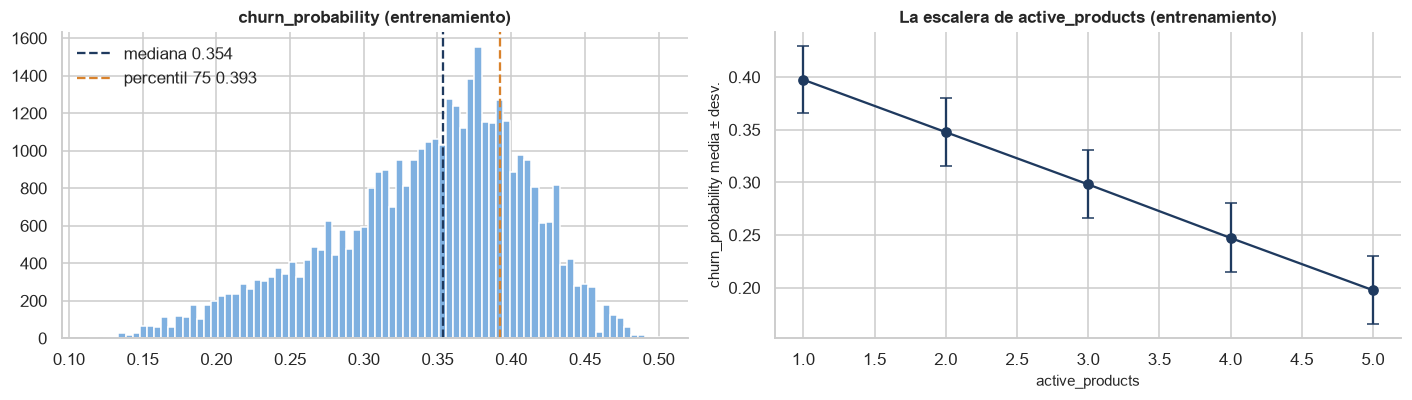

,count,mean,std,salto
active_products,,,,
1,15658,0.3975,0.0321,NaN
2,11714,0.3477,0.0326,-0.0498
3,5807,0.2981,0.0322,-0.0496
4,3855,0.2473,0.0328,-0.0508
5,1944,0.1977,0.0324,-0.0496


In [6]:
umbral_p75 = etiqueta.umbral
umbral_med = float(objetivo.median())
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].hist(objetivo, bins=80, color='#7fb0e0', edgecolor='white')
ax[0].axvline(umbral_med, color=graficos.AZUL, ls='--', label=f'mediana {umbral_med:.3f}')
ax[0].axvline(umbral_p75, color='#d9822b', ls='--', label=f'percentil 75 {umbral_p75:.3f}')
ax[0].set_title('churn_probability (entrenamiento)')
ax[0].legend(frameon=False)
escalera = diag['escalera']
ax[1].errorbar(escalera.index, escalera['mean'], yerr=escalera['std'], marker='o', color=graficos.AZUL, capsize=4)
ax[1].set_xlabel('active_products')
ax[1].set_ylabel('churn_probability media ± desv.')
ax[1].set_title('La escalera de active_products (entrenamiento)')
plt.tight_layout()
plt.show()
display(escalera)

In [7]:
display(Markdown(f"""
**`churn_probability` no es un evento observado sino un puntaje.** Toma valores entre
{dec(objetivo.min(), 3)} y {dec(objetivo.max(), 3)}, nunca 0 ni 1, y según la ficha del conjunto es la salida de un
modelo con ventana de 30 días. Su relación con `active_products` lo confirma: la correlación es
{dec(diag['r_active_products'], 3, True)} (esa sola variable explica el {pct(diag['r2_active_products'], 1)} de la varianza), y la media
desciende en una escalera de saltos casi idénticos ({enumerar(dec(s, 4, True) for s in escalera['salto'].dropna())};
desviación entre saltos {dec(diag['desv_saltos'], 5)}) con la misma dispersión en cada nivel. Un paso
constante es la firma de una regla de generación, no de una asociación empírica. Las variables de
tenencia de productos no la reconstruyen (su suma coincide con `active_products` en el
{pct(diag['booleanas_vs_active']['coincidencia_pct'] / 100, 1)} de los clientes; r = {dec(diag['booleanas_vs_active']['r'], 3)}), así que se conservan.

**Decisión: `active_products` se excluye como predictor.** Con ella el problema sería recuperar la
fórmula de la etiqueta, no predecir la fuga: un modelo que la conoce explica el 99,9 % del objetivo
(sección del modelo nuevo). Excluirla deja el problema con su dificultad real.

**La etiqueta.** *Riesgo alto* es el cuarto superior de `churn_probability`: el umbral es el percentil
75 **del entrenamiento** ({dec(umbral_p75, 4)}), fijo para entrenamiento y prueba, y deja un
{pct(p['y_train'].mean(), 1)} de positivos en entrenamiento y un {pct(p['y_test'].mean(), 1)} en prueba. Se prefirió al de la
mediana ({dec(umbral_med, 4)}), que usó la Entrega 2, porque la mediana deja las clases al 50 % por
construcción y vacía de sentido la etapa de balanceo: ADASYN no puede generar ningún cliente y
SMOTE añade unos pocos. La comparación con la Entrega 2 se hace con la etiqueta de la mediana, para
que las cifras sean comparables.
"""))


**`churn_probability` no es un evento observado sino un puntaje.** Toma valores entre
0,114 y 0,501, nunca 0 ni 1, y según la ficha del conjunto es la salida de un
modelo con ventana de 30 días. Su relación con `active_products` lo confirma: la correlación es
−0,876 (esa sola variable explica el 76,8 % de la varianza), y la media
desciende en una escalera de saltos casi idénticos (−0,0498, −0,0496, −0,0508 y −0,0496;
desviación entre saltos 0,00060) con la misma dispersión en cada nivel. Un paso
constante es la firma de una regla de generación, no de una asociación empírica. Las variables de
tenencia de productos no la reconstruyen (su suma coincide con `active_products` en el
15,0 % de los clientes; r = 0,006), así que se conservan.

**Decisión: `active_products` se excluye como predictor.** Con ella el problema sería recuperar la
fórmula de la etiqueta, no predecir la fuga: un modelo que la conoce explica el 99,9 % del objetivo
(sección del modelo nuevo). Excluirla deja el problema con su dificultad real.

**La etiqueta.** *Riesgo alto* es el cuarto superior de `churn_probability`: el umbral es el percentil
75 **del entrenamiento** (0,3927), fijo para entrenamiento y prueba, y deja un
24,6 % de positivos en entrenamiento y un 24,6 % en prueba. Se prefirió al de la
mediana (0,3540), que usó la Entrega 2, porque la mediana deja las clases al 50 % por
construcción y vacía de sentido la etapa de balanceo: ADASYN no puede generar ningún cliente y
SMOTE añade unos pocos. La comparación con la Entrega 2 se hace con la etiqueta de la mediana, para
que las cifras sean comparables.


## 4. Variables que se eliminan

Cada eliminación se apoya en una cifra calculada en esta ejecución.

In [8]:
pares = diag['pares_duplicados'].set_index('par')
eta = diag['eta2'].set_index('variable')['eta2']
falt = diag['faltantes']
aus = diag['ausencia_vs_objetivo']
eliminadas = pd.DataFrame([
    ('customer_id', 'llave única', 'identificador'),
    ('active_products', f"r = {dec(diag['r_active_products'], 3)} con el objetivo y escalera de paso constante", 'fuga de información'),
    ('customer_lifetime_value', f"ρ de Spearman = {dec(diag['rho_clv_volumen'], 3)} con el volumen transaccional", 'segundo objetivo del proyecto'),
    ('clv_segment', 'derivada del CLV', 'segundo objetivo del proyecto'),
    ('average_transaction_value', f"mismos valores que avg_tx_value ({dec(pares.iloc[0]['mismos_valores_pct'], 0)} %) pero coincidencia por fila del {dec(pares.iloc[0]['coincide_por_fila_pct'], 3)} %", 'duplicado desalineado'),
    ('total_transaction_volume', f"mismos valores que total_tx_volume ({dec(pares.iloc[1]['mismos_valores_pct'], 0)} %) pero coincidencia por fila del {dec(pares.iloc[1]['coincide_por_fila_pct'], 3)} %", 'duplicado desalineado'),
    ('avg_daily_transactions', f"r = {dec(pares.iloc[2]['r'], 3)} con transaction_frequency", 'duplicado exacto'),
    ('monthly_transaction_count', f"r = {dec(pares.iloc[3]['r'], 3)} con transaction_frequency", 'duplicado reescalado'),
    ('first_transaction_date, last_transaction_date', 'duplican first_tx y last_tx', 'duplicado'),
    ('nps_score', f"r = {dec(diag['r_satisfaccion_nps'], 3)} con satisfaction_score", 'colinealidad'),
    ('occupation', f"{int(diag['eta2'].set_index('variable').loc['occupation', 'niveles'])} niveles, η² = {dec(eta['occupation'], 4)}", 'alta cardinalidad sin señal'),
    ('complaint_topics', f"{dec(falt.loc['complaint_topics', 'pct'], 1)} % ausente; correlación de la ausencia con el objetivo {dec(aus['complaint_topics']['r_con_objetivo'], 3)}", 'faltante sin mecanismo ni señal'),
    ('feature_requests', f"{dec(falt.loc['feature_requests', 'pct'], 1)} % ausente; correlación de la ausencia con el objetivo {dec(aus['feature_requests']['r_con_objetivo'], 3)}", 'faltante sin mecanismo ni señal'),
    ('last_survey_date, first_tx, last_tx', f"η² = {dec(eta['last_survey_date'], 4)}, {dec(eta['first_tx'], 4)} y {dec(eta['last_tx'], 4)}", 'fechas sin señal'),
], columns=['columna', 'evidencia', 'criterio'])
eliminadas

,columna,evidencia,criterio
0,customer_id,llave única,identificador
1,active_products,"r = −0,876 con el objetivo y escalera de paso ...",fuga de información
2,customer_lifetime_value,"ρ de Spearman = 0,984 con el volumen transacci...",segundo objetivo del proyecto
3,clv_segment,derivada del CLV,segundo objetivo del proyecto
4,average_transaction_value,mismos valores que avg_tx_value (100 %) pero c...,duplicado desalineado
5,total_transaction_volume,mismos valores que total_tx_volume (100 %) per...,duplicado desalineado
6,avg_daily_transactions,"r = 1,000 con transaction_frequency",duplicado exacto
7,monthly_transaction_count,"r = 1,000 con transaction_frequency",duplicado reescalado
8,"first_transaction_date, last_transaction_date",duplican first_tx y last_tx,duplicado
9,nps_score,"r = 0,917 con satisfaction_score",colinealidad


In [9]:
cont = diag['contingencia_credito']
display(Markdown(f"""
Un **duplicado desalineado** tiene exactamente los mismos valores que otra columna pero repartidos
entre clientes distintos: es una copia permutada que no describe al cliente de su fila. El único
faltante que se conserva es `credit_utilization_ratio`: falta en el {dec(falt.loc['credit_utilization_ratio', 'pct'], 1)} % de los
clientes, y falta **exactamente** cuando el cliente no tiene tarjeta de crédito (la tabla de
contingencia es {dec(cont.loc[True, False] * 100, 0)} % / {dec(cont.loc[False, True] * 100, 0)} %). No es un dato perdido sino un *no
aplica*, y se imputa con cero por definición del dominio, sin usar ningún estadístico de los datos.
Tras la depuración quedan {p['datos'].shape[1] - 1} predictores, que el preprocesamiento convierte en 78
columnas (escalado de las numéricas e indicadoras de las categóricas, ajustados dentro de cada
pliegue).
"""))


Un **duplicado desalineado** tiene exactamente los mismos valores que otra columna pero repartidos
entre clientes distintos: es una copia permutada que no describe al cliente de su fila. El único
faltante que se conserva es `credit_utilization_ratio`: falta en el 37,5 % de los
clientes, y falta **exactamente** cuando el cliente no tiene tarjeta de crédito (la tabla de
contingencia es 100 % / 100 %). No es un dato perdido sino un *no
aplica*, y se imputa con cero por definición del dominio, sin usar ningún estadístico de los datos.
Tras la depuración quedan 48 predictores, que el preprocesamiento convierte en 78
columnas (escalado de las numéricas e indicadoras de las categóricas, ajustados dentro de cada
pliegue).


## 5. Dónde está la señal

In [10]:
X_tr = p['conjuntos'].X_train
numericas = X_tr.select_dtypes(include=['number', 'bool']).columns
rho = X_tr[numericas].astype(float).corrwith(p['conjuntos'].y_train_cont, method='spearman').dropna()
rho = rho.reindex(rho.abs().sort_values(ascending=False).index)
display(rho.head(10).to_frame('ρ de Spearman con churn_probability (entrenamiento)'))
max_tx = rho.reindex(derivadas).abs().max()

,ρ de Spearman con churn_probability (entrenamiento)
app_logins_frequency,-0.2794
age,0.2103
satisfaction_score,-0.1905
base_satisfaction,-0.1643
product_satisfaction,0.0429
savings_account,0.0411
feature_usage_diversity,0.0301
credit_card,0.0296
credit_utilization_ratio,0.0254
investment_account,0.0237


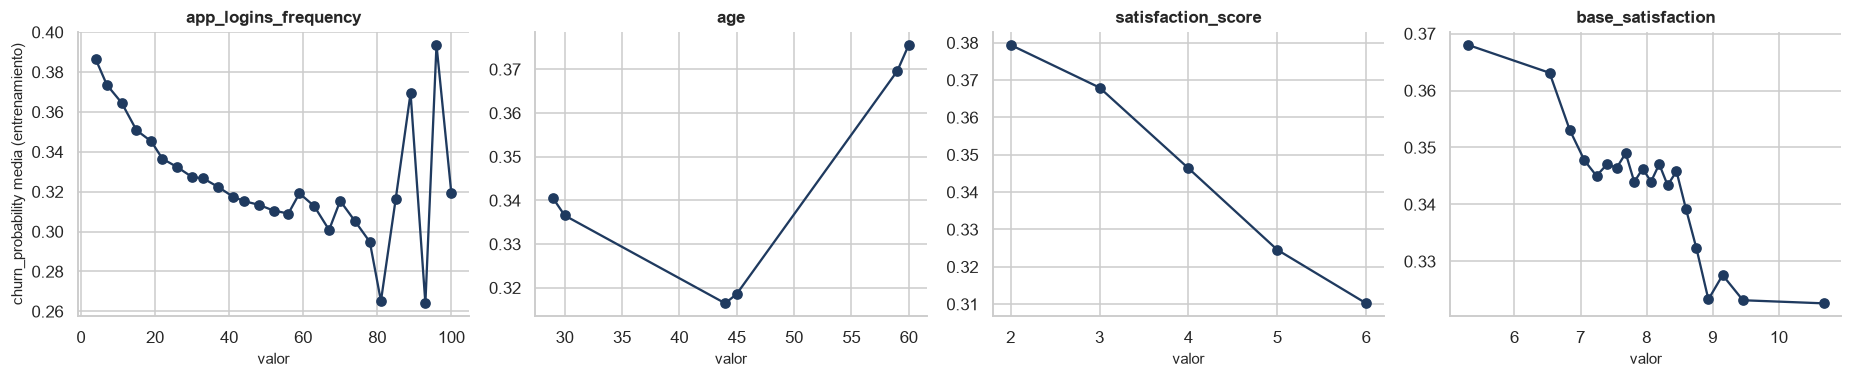


Sin `active_products`, la señal está en cuatro variables: `app_logins_frequency` (ρ = −0,279), `age` (ρ = +0,210), `satisfaction_score` (ρ = −0,190) y `base_satisfaction` (ρ = −0,164).
Las 12 variables transaccionales no aportan (|ρ| ≤ 0,018). Las curvas muestran que las
relaciones **no son lineales**: la frecuencia de uso de la aplicación reduce el riesgo con fuerza al
principio y luego se aplana, la satisfacción baja el riesgo por escalones y la satisfacción de base
lo hace en forma de S. Es la razón por la que los modelos lineales de la Entrega 2 se quedaron cortos.


In [11]:
variables = ['app_logins_frequency', 'age', 'satisfaction_score', 'base_satisfaction']
fig, ax = plt.subplots(1, 4, figsize=(17, 3.6))
for a, v in zip(ax, variables):
    x = entrenamiento[v]
    grupos = x if x.nunique() <= 30 else pd.qcut(x, 20, duplicates='drop').apply(lambda i: i.mid)
    m = objetivo.groupby(grupos).agg(['mean', 'count'])
    a.plot(m.index.astype(float), m['mean'], marker='o', color=graficos.AZUL)
    a.set_title(v)
    a.set_xlabel('valor')
ax[0].set_ylabel('churn_probability media (entrenamiento)')
plt.tight_layout()
plt.show()
display(Markdown(f"""
Sin `active_products`, la señal está en cuatro variables: {enumerar(f'`{v}` (ρ = {dec(rho[v], 3, True)})' for v in variables)}.
Las {len(derivadas)} variables transaccionales no aportan (|ρ| ≤ {dec(max_tx, 3)}). Las curvas muestran que las
relaciones **no son lineales**: la frecuencia de uso de la aplicación reduce el riesgo con fuerza al
principio y luego se aplana, la satisfacción baja el riesgo por escalones y la satisfacción de base
lo hace en forma de S. Es la razón por la que los modelos lineales de la Entrega 2 se quedaron cortos.
"""))

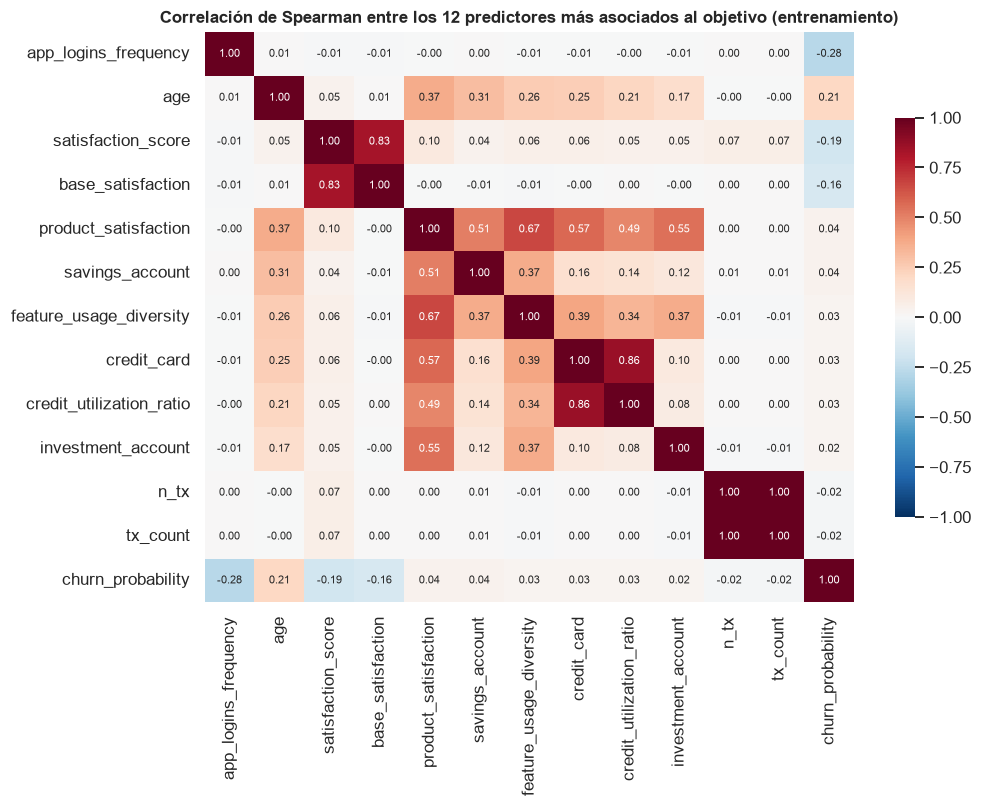


Entre las cuatro variables con señal, `satisfaction_score` y `base_satisfaction` están correlacionadas (ρ = 0,83);
el resto de los pares no supera |ρ| = 0,05. Las dos satisfacciones miden aspectos parecidos, así que la segunda aporta poco cuando el modelo ya tiene la primera (de ahí su peso pequeño en las explicaciones de la sección de interpretabilidad); la edad y la frecuencia de uso aportan información propia. Entre los demás predictores hay un duplicado: `n_tx` y `tx_count` (ρ = 1,00): `n_tx`, que se deriva del detalle de transacciones, repite `tx_count`, que ya venía en la tabla de clientes. Es una copia redundante sin efecto en los resultados (su correlación con el objetivo es de 0,018) y se mantuvo para que todas las corridas usen las mismas columnas.


In [12]:
top = list(rho.index[:12])
corr = pd.concat([X_tr[top].astype(float), p['conjuntos'].y_train_cont], axis=1).corr(method='spearman')
fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7}, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlación de Spearman entre los 12 predictores más asociados al objetivo (entrenamiento)')
plt.tight_layout()
plt.show()
fuera_diag = corr.drop(index='churn_probability', columns='churn_probability').where(~np.eye(12, dtype=bool))
pares_altos = fuera_diag.abs().stack()
pares_altos = pares_altos[pares_altos > 0.9]
pares_altos = pares_altos[[a < b for a, b in pares_altos.index]]
senal = corr.loc[variables, variables].where(~np.eye(4, dtype=bool)).abs().max().max()
rho_obj = {v: abs(rho.get(v, 0)) for pair in pares_altos.index for v in pair}
frase_pares = ''
if len(pares_altos):
    frase_pares = (' Entre los demás predictores hay un duplicado: ' + enumerar(f'`{a}` y `{b}` (ρ = {dec(fuera_diag.loc[a, b], 2)})' for a, b in pares_altos.index)
                   + ': `n_tx`, que se deriva del detalle de transacciones, repite `tx_count`, que ya venía en la tabla de '
                   'clientes. Es una copia redundante sin efecto en los resultados (su correlación con el objetivo es de '
                   f'{dec(max(rho_obj.values()), 3)}) y se mantuvo para que todas las corridas usen las mismas columnas.'
                   if any('n_tx' in p for p in pares_altos.index) else
                   ' Los pares con ρ > 0,9 son ' + enumerar(f'`{a}` y `{b}`' for a, b in pares_altos.index) + '.')
c4 = corr.loc[variables, variables]
pares4 = [(a, b, c4.loc[a, b]) for i, a in enumerate(variables) for b in variables[i + 1:]]
fuertes = [(a, b, r) for a, b, r in pares4 if abs(r) >= 0.3]
debiles = max(abs(r) for a, b, r in pares4 if abs(r) < 0.3)
display(Markdown(f"""
Entre las cuatro variables con señal, {enumerar(f'`{a}` y `{b}` están correlacionadas (ρ = {dec(r, 2)})' for a, b, r in fuertes) if fuertes else 'ningún par está correlacionado'};
el resto de los pares no supera |ρ| = {dec(debiles, 2)}. {'Las dos satisfacciones miden aspectos parecidos, así que la segunda aporta poco cuando el modelo ya tiene la primera (de ahí su peso pequeño en las explicaciones de la sección de interpretabilidad); ' if any('satisfaction' in a and 'satisfaction' in b for a, b, _ in fuertes) else ''}la edad y la frecuencia de uso aportan información propia.{frase_pares}
"""))

## 6. Estructura del archivo: tres cohortes de edad

In [13]:
edades = df['age'].value_counts().sort_index()
display(edades.to_frame('clientes'))
posicion = pd.Series(np.arange(len(df)), index=df.index)
decil = pd.qcut(posicion, 10, labels=[f'{i}' for i in range(1, 11)])
por_decil = pd.DataFrame({'edad media (todos)': df['age'].groupby(decil).mean(),
                          'riesgo alto (entrenamiento)': (objetivo > umbral_p75).groupby(decil.loc[objetivo.index]).mean()})
por_decil.index.name = 'decil de posición en el archivo'
por_decil

,clientes
age,
29,8115
30,8104
44,8057
45,8082
59,8190
60,8175


,edad media (todos),riesgo alto (entrenamiento)
decil de posición en el archivo,,
1,44.5044,0.0896
2,44.4934,0.0846
3,44.5025,0.0899
4,54.8229,0.3261
5,59.4966,0.4501
6,59.4977,0.4571
7,49.6359,0.3739
8,29.4889,0.1997
9,29.5111,0.1860


In [14]:
display(Markdown(f"""
La edad toma **solo {df['age'].nunique()} valores** ({enumerar(str(e) for e in edades.index)} años), con unos
{ent(edades.mean())} clientes cada uno: el conjunto se generó por tres cohortes de edad, no a partir
de una población con edades continuas. El archivo además está **ordenado por bloques** que siguen a
esas cohortes, y el riesgo alto pasa del {pct(por_decil['riesgo alto (entrenamiento)'].min(), 0)} al
{pct(por_decil['riesgo alto (entrenamiento)'].max(), 0)} según el bloque. Esto tiene dos consecuencias. La
partición tenía que ser aleatoria (una partición por posición habría dejado cohortes enteras fuera
del entrenamiento). Y en las pruebas que dependen del orden de las filas (Ljung-Box, BDS, bootstrap
estacionario) el orden del archivo induce dependencia entre vecinos, que el bootstrap estacionario
tiene en cuenta al elegir la longitud de bloque.
"""))


La edad toma **solo 6 valores** (29, 30, 44, 45, 59 y 60 años), con unos
8.120 clientes cada uno: el conjunto se generó por tres cohortes de edad, no a partir
de una población con edades continuas. El archivo además está **ordenado por bloques** que siguen a
esas cohortes, y el riesgo alto pasa del 8 % al
46 % según el bloque. Esto tiene dos consecuencias. La
partición tenía que ser aleatoria (una partición por posición habría dejado cohortes enteras fuera
del entrenamiento). Y en las pruebas que dependen del orden de las filas (Ljung-Box, BDS, bootstrap
estacionario) el orden del archivo induce dependencia entre vecinos, que el bootstrap estacionario
tiene en cuenta al elegir la longitud de bloque.


## 7. El valor del cliente (CLV): corrección de la Entrega 1

El profesor señaló una contradicción entre dos conclusiones consecutivas de la Entrega 1. La
primera decía que el CLV **no varía** con el número de productos activos; la siguiente, que **crece de
forma ordenada** con ellos. Los datos de entrenamiento resuelven cuál es la correcta.

In [15]:
clv = entrenamiento['customer_lifetime_value']
rho_clv_ap = clv.corr(entrenamiento['active_products'], method='spearman')
clv_por_productos = clv.groupby(entrenamiento['active_products']).median()
orden_seg = ['Bronze', 'Silver', 'Gold', 'Platinum']
clv_por_segmento = clv.groupby(entrenamiento['clv_segment']).median().reindex(
    [s for s in orden_seg if s in entrenamiento['clv_segment'].unique()])
clv_por_cliente = clv.groupby(entrenamiento['customer_segment']).median().sort_values()
millones = lambda serie, nombre: (serie / 1e6).round(1).to_frame(nombre).T
display(millones(clv_por_productos, 'CLV mediano (millones de COP) por active_products'))
display(millones(clv_por_segmento, 'CLV mediano (millones de COP) por clv_segment'))
display(millones(clv_por_cliente, 'CLV mediano (millones de COP) por customer_segment'))
display(Markdown(f"""
**Conclusión corregida.** El CLV **no varía** con el número de productos activos: la correlación de
Spearman es {dec(rho_clv_ap, 4, True)} y la mediana se mantiene entre {dec(clv_por_productos.min() / 1e6, 1)} y
{dec(clv_por_productos.max() / 1e6, 1)} millones de pesos en todos los niveles. Lo que sí lo ordena es
`clv_segment` (de {dec(clv_por_segmento.iloc[0] / 1e6, 1)} a {dec(clv_por_segmento.iloc[-1] / 1e6, 1)} millones de mediana) y
`customer_segment` (de {dec(clv_por_cliente.iloc[0] / 1e6, 1)} a {dec(clv_por_cliente.iloc[-1] / 1e6, 1)} millones), y su motor es la
intensidad transaccional (ρ de Spearman = {dec(diag['rho_clv_volumen'], 3)} con el volumen total). La primera de
las dos conclusiones de la Entrega 1 era la correcta; la segunda queda corregida. La variable que
casi determina la fuga (`active_products`) no guarda relación con el valor del cliente: los dos
objetivos responden a mecanismos distintos.
"""))

active_products,1,2,3,4,5
CLV mediano (millones de COP) por active_products,128.9000,130.6000,127.9000,128.1000,134.5000


clv_segment,Bronze,Silver,Gold,Platinum
CLV mediano (millones de COP) por clv_segment,40.9000,95.7000,191.1000,492.7000


customer_segment,inactive,occasional,regular,power
CLV mediano (millones de COP) por customer_segment,31.4000,87.9000,235.9000,534.1000



**Conclusión corregida.** El CLV **no varía** con el número de productos activos: la correlación de
Spearman es −0,0013 y la mediana se mantiene entre 127,9 y
134,5 millones de pesos en todos los niveles. Lo que sí lo ordena es
`clv_segment` (de 40,9 a 492,7 millones de mediana) y
`customer_segment` (de 31,4 a 534,1 millones), y su motor es la
intensidad transaccional (ρ de Spearman = 0,984 con el volumen total). La primera de
las dos conclusiones de la Entrega 1 era la correcta; la segunda queda corregida. La variable que
casi determina la fuga (`active_products`) no guarda relación con el valor del cliente: los dos
objetivos responden a mecanismos distintos.


## 8. Observaciones del profesor y dónde se corrigen

| Entrega | Observación | Dónde se corrige |
|---|---|---|
| 1 | No había partición entrenamiento/prueba; los estadísticos del objetivo usaban todos los clientes | Sección 2 de esta página: la partición va antes de cualquier estadístico del objetivo, y `datos.diagnosticos_objetivo` lo impone en código |
| 1 | Contradicción entre dos conclusiones sobre el CLV y los productos activos | Sección 7 de esta página |
| 2 | El cuaderno se entregó sin salidas ejecutadas | Todas las páginas del libro se ejecutan de principio a fin con `libro/construir.py` y se publican con sus salidas |
| 2 | Cifras escritas a mano en las conclusiones | Toda cifra del texto se genera desde variables (`src/formato.py`) |
| 2 | Fuga en el umbral de la etiqueta (mediana del conjunto completo) | El umbral se estima solo con entrenamiento (`datos.construir_etiqueta`), aquí y en la comparación con la Entrega 2 |
| 2 | No se entrenó ninguna regresión Ridge o Lasso | La regresión es una tarea completa: 7 modelos (Ridge y Lasso incluidos) × 4 optimizadores, más la EBM |

# Metodología

Esta página describe el diseño experimental completo: el pipeline que recibe cada modelo, el
catálogo de modelos con sus espacios de búsqueda, las técnicas de balanceo, la validación cruzada
anidada, los cuatro métodos de optimización y las reglas de reproducibilidad. Todo lo que se
describe está en el paquete `src/` (código con *docstrings* en formato NumPy y pruebas
automáticas en `tests/`), y las tablas de esta página se generan leyendo ese código, de modo que
no pueden desviarse de lo que realmente se ejecutó.

In [16]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import pandas as pd
from IPython.display import Markdown, display

from src import balanceo, config, modelos, optimizacion
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar

pd.set_option('display.max_colwidth', 400)

## 1. El pipeline

Cada combinación se ensambla como un `Pipeline` de `imbalanced-learn` con tres etapas:

1. **Preprocesado** (`src/preprocesamiento.py`): un `ColumnTransformer` que estandariza las
   variables numéricas y booleanas y codifica las categóricas con indicadoras (`OneHotEncoder`
   con `drop='first'` para evitar colinealidad perfecta y `handle_unknown='ignore'` por si un
   nivel aparece solo en validación o prueba). Resultan 78 columnas.
2. **Muestreo** (solo con SMOTE o ADASYN): genera clientes sintéticos de la clase minoritaria.
3. **Modelo**.

Como las tres etapas viven dentro del mismo objeto, en cada pliegue de cada validación cruzada
(externa o interna) el escalado, la codificación y el sobremuestreo se ajustan **solo con las filas
de entrenamiento de ese pliegue**, y las filas de validación nunca se remuestrean. Es la garantía
contra la fuga de información que pide la guía (§3.1) y que faltó en las entregas anteriores.

## 2. Los modelos y sus espacios de búsqueda

Los siete modelos de cada tarea son los de la guía (§7.2), más la EBM como modelo nuevo. Cada uno
se describe una sola vez (`src/modelos.py`) con una rejilla explícita para Grid Search y un espacio
tipado para los otros tres optimizadores (escala logarítmica para C, alpha y tasas de aprendizaje;
enteros en escala logarítmica para vecinos y tamaños de hoja), junto con su complejidad y la
justificación de los rangos.

In [17]:
def describir(espacio):
    partes = []
    for k, (tipo, *args) in espacio.items():
        nombre = k.split('__', 1)[1]
        if tipo == 'cat':
            partes.append(f'{nombre} ∈ {{{", ".join(map(str, args[0]))}}}')
        else:
            escala = {'log': 'log', 'int_log': 'entero, log', 'int': 'entero', 'float': 'uniforme'}[tipo]
            partes.append(f'{nombre} ∈ [{args[0]:g}, {args[1]:g}] ({escala})')
    return '; '.join(partes)

filas = []
for tarea in ('clasificacion', 'regresion'):
    for nombre, spec in modelos.catalogo(tarea, incluir_nuevo=True).items():
        filas.append({'tarea': tarea, 'modelo': NOMBRES_MODELO[nombre],
                      'puntos de la rejilla': spec.n_configuraciones_grid(),
                      'presupuesto por búsqueda': optimizacion.presupuesto_por_defecto(spec.espacio_grid),
                      'espacio de búsqueda': describir(spec.espacio),
                      'ponderación de clases': (f'{spec.peso_clases[0]}={spec.peso_clases[1]}' if spec.peso_clases
                                                else ('—' if tarea == 'regresion' else 'no aplica')),
                      'multi-fidelidad': ('; '.join(f'{fase}: ' + ', '.join(f'{k.split("__", 1)[1]}={v}' for k, v in d.items())
                                                    for fase, d in spec.fidelidad.items()) if spec.fidelidad else '—'),
                      'entrenamiento': spec.complejidad.get('entrenamiento', ''),
                      'inferencia': spec.complejidad.get('inferencia', '')})
catalogo = pd.DataFrame(filas).set_index(['tarea', 'modelo'])
catalogo[['puntos de la rejilla', 'presupuesto por búsqueda', 'espacio de búsqueda', 'ponderación de clases',
          'multi-fidelidad']]

puntos de la rejilla  \
tarea         modelo                                      
clasificacion k-NN                                   32   
              Naive Bayes                            30   
              Regresión logística                    30   
              Árbol de decisión                      48   
              Random Forest                          36   
              XGBoost                                32   
              SVM lineal                             30   
              EBM                                    36   
regresion     k-NN                                   32   
              Ridge                                  30   
              Lasso                                  30   
              Árbol de decisión                      48   
              Random Forest                          36   
              XGBoost                                32   
              SVR lineal                             30   
              EBM                                    36   

                                   presupuesto por búsqueda  \
tarea         modelo                                          
clasificacion k-NN                                       32   
              Naive Bayes                                30   
              Regresión logística                        30   
              Árbol de decisión                          48   
              Random Forest                              36   
              XGBoost                                    32   
              SVM lineal                                 30   
              EBM                                        36   
regresion     k-NN                                       32   
              Ridge                                      30   
              Lasso                                      30   
              Árbol de decisión                          48   
              Random Forest                              36   
              XGBoost                                    32   
              SVR lineal                                 30   
              EBM                                        36   

                                                                                                                                                                                                                                                                            espacio de búsqueda  \
tarea         modelo                                                                                                                                                                                                                                                                              
clasificacion k-NN                                                                                                                                                                                              n_neighbors ∈ [5, 600] (entero, log); weights ∈ {uniform, distance}; p ∈ {1, 2}   
              Naive Bayes                                                                                                                                                                                                                                  var_smoothing ∈ [1e-11, 0.001] (log)   
              Regresión logística                                                                                                                                                                                                                 C ∈ [0.001, 100] (log); l1_ratio ∈ {1.0, 0.0}   
              Árbol de decisión                                                                                                                           max_depth ∈ [3, 30] (entero); min_samples_leaf ∈ [1, 300] (entero, log); ccp_alpha ∈ [1e-06, 0.01] (log); criterion ∈ {gini, entropy}   
              Random Forest                                                                

In [18]:
catalogo[['entrenamiento', 'inferencia']]

entrenamiento  \
tarea         modelo                                                                                                                              
clasificacion k-NN                                                                                 O(1) fuerza bruta; O(n·p·log n) KD/Ball Tree   
              Naive Bayes                                                                                                                O(n·p)   
              Regresión logística                                                                           O(k·n·p) (liblinear, k iteraciones)   
              Árbol de decisión                                                                                                    O(n·p·log n)   
              Random Forest                                                                                                      O(T·n·p·log n)   
              XGBoost                                                                   O(T·d·(n·p + bins·p)) con hist; O(T·d·n·p·log n) exacto   
              SVM lineal                                                                              O(k·n·p) lineal; O(n²·p)–O(n³) con núcleo   
              EBM                  O(B·R·p·(n + bins)) efectos principales + O(p²·bins²) detección de pares (FAST) + O(B·R·K·(n + bins²)) pares   
regresion     k-NN                                                                                 O(1) fuerza bruta; O(n·p·log n) KD/Ball Tree   
              Ridge                                                                                        O(n·p² + p³) cholesky; O(k·n·p) SAGA   
              Lasso                                                                                           O(k·n·p) descenso por coordenadas   
              Árbol de decisión                                                                                                    O(n·p·log n)   
              Random Forest                                                                                                      O(T·n·p·log n)   
              XGBoost                                                                   O(T·d·(n·p + bins·p)) con hist; O(T·d·n·p·log n) exacto   
              SVR lineal                                                                              O(k·n·p) lineal; O(n²·p)–O(n³) con núcleo   
              EBM                  O(B·R·p·(n + bins)) efectos principales + O(p²·bins²) detección de pares (FAST) + O(B·R·K·(n + bins²)) pares   

                                                                                               inferencia  
tarea         modelo                                                                                       
clasificacion k-NN                 O(n·p) por consulta en fuerza bruta; O(p·log n) en árbol con p pequeño  
              Naive Bayes                                                        O(p·clases) por consulta  
              Regresión logística                                                                    O(p)  
              Árbol de decisión                                                         O(d) por consulta  
              Random Forest                                                           O(T·d) por consulta  
              XGBoost                                                                 O(T·d) por consulta  
              SVM lineal                                                   O(p) lineal; O(s·p) con núcleo  
              EBM                                  O(p + K) por consulta: una búsqueda de bin por término  
regresion     k-NN                 O(n·p) por consulta en fuerza bruta; O(p·log n) en árbol con p pequeño  
              Ridge                                                                                  O(p)  
              Lasso                                                                                  O(p)  
              Árbol de decisión                                                

La justificación de cada espacio, tal como está escrita en el código:

In [19]:
for tarea in ('clasificacion', 'regresion'):
    for nombre, spec in modelos.catalogo(tarea, incluir_nuevo=True).items():
        display(Markdown(f'**{NOMBRES_MODELO[nombre]} ({"clasificación" if tarea == "clasificacion" else "regresión"})**: {spec.justificacion}'))

**k-NN (clasificación)**: n_neighbors en escala logarítmica hasta 600: en la Entrega 2 el AUC seguía creciendo en k = 200, así que la rejilla debe cubrir más allá; weights=distance suaviza el voto y p elige entre distancia Manhattan y euclídea. Con p = 78 el árbol KD degenera a fuerza bruta.

**Naive Bayes (clasificación)**: GaussianNB solo tiene var_smoothing, que añade una fracción de la varianza máxima a todas las varianzas para estabilizar; se explora en escala log. No admite class_weight: priors=[0.5, 0.5] es su equivalente exacto (reponderar las clases a prioris iguales).

**Regresión logística (clasificación)**: C es el inverso de la penalización (escala log 1e-3..1e2, como en la Entrega 2, donde el óptimo fue interior). l1_ratio=1 es la penalización L1 (Lasso logístico) y l1_ratio=0 la L2 (Ridge logístico); scikit-learn ≥ 1.8 deprecó el parámetro penalty en favor de l1_ratio. liblinear soporta ambas en binario.

**Árbol de decisión (clasificación)**: max_depth y min_samples_leaf controlan el sobreajuste por dos vías (profundidad y tamaño mínimo de hoja, log hasta 300 ≈ 0,8 % de n); ccp_alpha poda por coste-complejidad en escala log.

**Random Forest (clasificación)**: n_estimators no se optimiza: el error de un bosque decrece de forma monótona con el número de árboles y se estabiliza, así que no tiene un óptimo interior que buscar. Se aplica multi-fidelidad (guía §3.3, «presupuestos parciales: menos árboles»): durante la búsqueda cada configuración se evalúa con 100 árboles y el modelo que se mide en el bucle externo y se guarda se reajusta con 300 (factor de reducción 3). Supuesto: el orden relativo de las configuraciones de max_features, max_depth y min_samples_leaf se conserva con 100 árboles; se contrasta en la sección de cómputo. El presupuesto se gasta en max_features (decorrelación entre árboles), max_depth y min_samples_leaf (regularización de cada árbol).

...

**Árbol de decisión (regresión)**: Igual que el árbol de clasificación; ccp_alpha en una escala menor porque la impureza (MSE) del objetivo, acotado en [0,11; 0,50], es del orden de 1e-3.

**Random Forest (regresión)**: Igual que el bosque de clasificación, incluida la multi-fidelidad (100 → 300 árboles).

**XGBoost (regresión)**: Igual que XGBoost de clasificación, con objetivo reg:squarederror.

**SVR lineal (regresión)**: LinearSVR por la misma razón de coste que LinearSVC. Pérdida ε-insensible cuadrática con el solucionador primal (dual=False): medido el 29-sep sobre un pliegue interno real, la pérdida ε-insensible lineal solo admite el solucionador dual, que no converge en 1.000 iteraciones para ningún C (45-85 s por ajuste con max_iter=10000, sin llegar), mientras que la cuadrática converge en 4-5 iteraciones y < 1 s. epsilon (ancho del tubo insensible) en log entre 1e-4 y 5e-2 porque la desviación típica del objetivo es ≈ 0,067: un tubo mayor que eso ignoraría casi toda la señal.

**EBM (regresión)**: Modelo nuevo, no explicado en clase: Explainable Boosting Machine (Lou, Caruana, Gehrke y Hooker, 2013; paquete interpret de Nori y otros, 2019). Es un modelo aditivo generalizado con interacciones por pares (GA²M): g(E[y]) = β<sub>0</sub> + Σ<sub>j</sub> <i>f</i><sub>j</sub>(<i>x</i><sub>j</sub>) + Σ<sub>ij</sub> <i>f</i><sub>ij</sub>(<i>x</i><sub>i</sub>, <i>x</i><sub>j</sub>). Cada función de forma <i>f</i><sub>j</sub> se aprende por boosting cíclico de árboles de pocas hojas sobre una sola variable a la vez, con una tasa de aprendizaje baja para que el orden de las variables no importe, y se promedia sobre outer_bags submuestras. Es tan legible como una regresión logística (cada variable aporta una curva que se puede graficar) y capta efectos no lineales como el boosting, que es justo lo que faltó en la Entrega 2. learning_rate en log entre 0,008 y 0,1: incluye los valores por defecto de la librería (0,015 en clasificación y 0,04 en regresión), y por debajo de 0,008 cada ajuste tarda el doble (26 s frente a 12 s medidos sobre un pliegue interno de 20.788 filas). max_leaves entre 2 y 4: la EBM aprende en pasos pequeños. min_samples_leaf en log entre 2 y 200 regulariza las funciones de forma. interactions entre 0 (GAM puro, sin pares) y 20: el valor por defecto, 3·p ≈ 234 pares, tardó 112 s por ajuste y en el benchmark sobre entrenamiento las interacciones no aportaron. max_bins en log entre 64 y 1024 fija la resolución de las curvas. Multi-fidelidad como en el Random Forest: la búsqueda usa 2 bolsas externas y el modelo final 8 (las bolsas promedian, no cambian la forma de la función, así que el orden de las configuraciones se conserva). class_weight se implementa con sample_weight (EBMConPesos).

## 3. Balanceo

| Técnica | Implementación | Cuándo no aplica |
|---|---|---|
| Sin balanceo | — | — |
| SMOTE | `imblearn.over_sampling.SMOTE`: interpola nuevos clientes de riesgo alto entre vecinos de la misma clase | Clases ya equilibradas (minoritaria > 40 %), donde no tiene nada que generar |
| ADASYN | Como SMOTE, pero genera más clientes donde la clase minoritaria es más difícil de separar | Igual que SMOTE |
| `class_weight` | Pondera los errores de cada clase en proporción inversa a su frecuencia: `class_weight='balanced'` en logística, árbol, Random Forest y SVM; `priors=[0,5; 0,5]` en Naive Bayes; `scale_pos_weight = negativos/positivos` en XGBoost (calculado con el pliegue); pesos por fila en la EBM | k-NN, cuya predicción es un voto sin función de pérdida que ponderar |

En regresión no hay balanceo de clases (guía §2). Las combinaciones que no aplican se registran en
la tabla maestra con su motivo.

## 4. Validación cruzada anidada

In [20]:
display(Markdown(f"""
- **Bucle externo**: {config.K_EXT} pliegues (estratificados en clasificación), siempre los mismos para
  todos los modelos. Es el único que produce la métrica que se reporta.
- **Bucle interno**: {config.K_INT} pliegues dentro de cada pliegue externo, donde cada optimizador elige los
  hiperparámetros. El mejor puntaje interno se guarda para medir el optimismo de selección, pero
  nunca se reporta como desempeño.
- **Modelo final**: al terminar, la misma búsqueda se repite sobre todo el entrenamiento y el ganador
  se reajusta con todo él. Es el que se guarda, se evalúa una sola vez en la prueba
  ({dec(config.TEST_SIZE * 100, 0)} % de los clientes, reservada desde el principio) y se usa en la interpretabilidad.
- **Métrica principal**: AUC en clasificación, porque no depende del umbral ni de la prevalencia y
  mide lo que necesita una campaña de retención (ordenar a los clientes por riesgo); el umbral y la
  calibración se tratan aparte. RMSE en regresión, porque penaliza más los errores grandes y está en
  las unidades del objetivo.
- **Presupuesto**: cada método evalúa tantas configuraciones como tiene la rejilla de Grid del mismo
  modelo, con un mínimo de {config.PRESUPUESTO_MINIMO}; así los cuatro métodos gastan lo mismo dentro de cada modelo.
"""))


- **Bucle externo**: 5 pliegues (estratificados en clasificación), siempre los mismos para
  todos los modelos. Es el único que produce la métrica que se reporta.
- **Bucle interno**: 3 pliegues dentro de cada pliegue externo, donde cada optimizador elige los
  hiperparámetros. El mejor puntaje interno se guarda para medir el optimismo de selección, pero
  nunca se reporta como desempeño.
- **Modelo final**: al terminar, la misma búsqueda se repite sobre todo el entrenamiento y el ganador
  se reajusta con todo él. Es el que se guarda, se evalúa una sola vez en la prueba
  (20 % de los clientes, reservada desde el principio) y se usa en la interpretabilidad.
- **Métrica principal**: AUC en clasificación, porque no depende del umbral ni de la prevalencia y
  mide lo que necesita una campaña de retención (ordenar a los clientes por riesgo); el umbral y la
  calibración se tratan aparte. RMSE en regresión, porque penaliza más los errores grandes y está en
  las unidades del objetivo.
- **Presupuesto**: cada método evalúa tantas configuraciones como tiene la rejilla de Grid del mismo
  modelo, con un mínimo de 30; así los cuatro métodos gastan lo mismo dentro de cada modelo.


**Por qué 5 pliegues externos y 3 internos.** Con 38.978 clientes de entrenamiento, cada pliegue
externo valida sobre unos 7.800 clientes, lo bastante para que el AUC de un pliegue tenga un error
estándar de unas 5 milésimas, y entrena con el 80 % de los datos, de modo que la estimación apenas
subestima al modelo final entrenado con todos. Diez pliegues duplicarían el coste de las 140 corridas
sin una ganancia apreciable. El bucle interno se repite para cada configuración candidata (30 a 48
por búsqueda) y para cada pliegue externo, así que su número de pliegues multiplica el coste total:
con 3, cada búsqueda entrena con unos 20.800 clientes y valida con unos 10.400, validaciones grandes
que bastan para ordenar las configuraciones, y una corrida completa supone entre 540 y 864 ajustes.
Con 5 pliegues internos el coste crecería un 67 %. La sección de optimizadores mide el precio de esta
elección: el puntaje interno subestima al externo en una milésima de AUC, porque los modelos internos
se entrenan con menos filas, pero ordena las configuraciones igual.

**Entrenamiento, validación y prueba.** La prueba (20 %) se separa al principio y no interviene en
ninguna decisión. Dentro del entrenamiento, la validación es siempre la de la validación cruzada: los
pliegues internos validan para elegir hiperparámetros y los externos, para estimar la
generalización. Las predicciones *fuera de pliegue* (cada cliente de entrenamiento predicho por un
modelo que no lo vio) son el conjunto de validación de la gráfica de entrenamiento, validación y
prueba de la sección de evaluación. Donde un método necesita un conjunto de validación propio (el
*early stopping* de XGBoost en la sección de cómputo), se aparta un 10 % del entrenamiento,
estratificado y con la semilla del proyecto.

## 5. Los cuatro métodos de optimización

| Método | Cómo propone configuraciones | Justificación de sus componentes |
|---|---|---|
| **Grid Search** | Recorre la rejilla explícita completa | Referencia exhaustiva; paraleliza configuraciones × pliegues |
| **Random Search** | Muestrea el espacio tipado con distribuciones continuas (log-uniforme, uniforme, enteros) | Bergstra y Bengio (2012): con pocos hiperparámetros importantes, el muestreo aleatorio cubre mejor cada dimensión que una rejilla del mismo tamaño |
| **Bayesiana (Optuna)** | *Tree-structured Parzen Estimator* (TPE) | **Sustituto**: en lugar de modelar f(x) con un proceso gaussiano, TPE estima dos densidades, ℓ(x) para las configuraciones del cuantil superior (γ = 0,10) y g(x) para el resto, y escala linealmente con el número de ensayos y admite espacios mixtos sin adaptación. **Adquisición**: propone el x que maximiza ℓ(x)/g(x), que equivale a maximizar la mejora esperada (EI). **Arranque**: los primeros 10 ensayos son aleatorios, para que las densidades tengan datos |
| **Genética (DEAP)** | Evoluciona una población de vectores de genes en [0, 1], uno por hiperparámetro | **Selección**: torneo de 3, invariante a la escala del *fitness* (las diferencias de AUC son de milésimas, y la ruleta las aplanaría). **Cruce**: uniforme por gen con probabilidad de intercambio 0,5, aplicado con probabilidad 0,6. **Mutación**: gaussiana con σ = 0,15 en la escala [0, 1], probabilidad 1/n por gen, aplicada con probabilidad 0,3; un hijo idéntico a un genoma ya evaluado se vuelve a mutar. **Elitismo**: el mejor individuo histórico se reinserta en cada generación. **Población**: max(4, min(presupuesto/4, 12)), para tener al menos 3 a 5 generaciones con 30 a 48 evaluaciones. **Diversidad**: se registra por generación (desviación típica media de los genes) para detectar convergencia prematura. Una caché de genomas evita gastar presupuesto en repeticiones |

**Multi-fidelidad (guía §3.3).** Random Forest se busca con 100 árboles y el modelo final se
reajusta con 300; la EBM, con 2 y 8 bolsas externas. Más árboles o más bolsas reducen la varianza del
modelo sin cambiar qué configuración es mejor, así que la búsqueda puede hacerse con la versión
barata. El supuesto se comprueba en la sección de cómputo.

## 6. Reproducibilidad

In [21]:
import importlib.metadata as md
versiones = {p: md.version(p) for p in ('scikit-learn', 'imbalanced-learn', 'xgboost', 'optuna', 'deap',
                                         'interpret-core', 'shap', 'lime', 'statsmodels', 'arch', 'scipy', 'numpy', 'pandas')}
import re
import subprocess
recogidas = subprocess.run([sys.executable, '-m', 'pytest', '--collect-only', '-q'], cwd=RAIZ,
                           capture_output=True, text=True).stdout
n_pruebas = int(re.search(r'(\d+) tests? collected', recogidas).group(1))
display(pd.Series(versiones).to_frame('versión'))
display(Markdown(f"""
- **Semilla única**: `config.SEED = {config.SEED}`, propagada a la partición, a cada estimador
  (`random_state`), a SMOTE y ADASYN, al muestreador TPE de Optuna, al genético y a los bootstrap.
- **Versiones exactas** en `requirements.txt` (arriba, las de las librerías principales).
- **Código congelado**: cada ejecución larga (las 140 corridas, las del modelo nuevo, la comparación con
  la Entrega 2, los experimentos de cómputo) copia `src/` y registra su huella SHA-256, de modo que
  editar el código mientras corre no mezcla versiones. Las corridas de la tabla maestra usaron dos
  versiones documentadas: las 12 primeras se hicieron antes de corregir las especificaciones de SVR y
  SVM, que no convergían, y el resto, con la corrección (la sección de cómputo da los detalles).
- **Tabla maestra** (`resultados/experimentos.parquet`): una fila por corrida con métricas por pliegue,
  hiperparámetros, tiempos, trazas y detalles de cada optimizador; se escribe de forma atómica y con
  un cerrojo, y las corridas se pueden reanudar.
- **{n_pruebas} pruebas automáticas** (`tests/`): ausencia de fugas en la partición y en el pipeline, uniformidad de
  los optimizadores y del registro, y cada contraste estadístico comparado con su definición directa.
"""))

,versión
scikit-learn,1.9.1
imbalanced-learn,0.14.2
xgboost,3.4.1
optuna,5.0.0
deap,1.4.4
interpret-core,0.7.8
shap,0.52.0
lime,0.2.0.1
statsmodels,0.15.0
arch,8.0.0



- **Semilla única**: `config.SEED = 42`, propagada a la partición, a cada estimador
  (`random_state`), a SMOTE y ADASYN, al muestreador TPE de Optuna, al genético y a los bootstrap.
- **Versiones exactas** en `requirements.txt` (arriba, las de las librerías principales).
- **Código congelado**: cada ejecución larga (las 140 corridas, las del modelo nuevo, la comparación con
  la Entrega 2, los experimentos de cómputo) copia `src/` y registra su huella SHA-256, de modo que
  editar el código mientras corre no mezcla versiones. Las corridas de la tabla maestra usaron dos
  versiones documentadas: las 12 primeras se hicieron antes de corregir las especificaciones de SVR y
  SVM, que no convergían, y el resto, con la corrección (la sección de cómputo da los detalles).
- **Tabla maestra** (`resultados/experimentos.parquet`): una fila por corrida con métricas por pliegue,
  hiperparámetros, tiempos, trazas y detalles de cada optimizador; se escribe de forma atómica y con
  un cerrojo, y las corridas se pueden reanudar.
- **72 pruebas automáticas** (`tests/`): ausencia de fugas en la partición y en el pipeline, uniformidad de
  los optimizadores y del registro, y cada contraste estadístico comparado con su definición directa.


# Las 140 corridas del pipeline combinatorio

La guía (§2) pide recorrer el producto completo de modelos, técnicas de balanceo y métodos de
optimización: 7 clasificadores × 4 balanceos × 4 optimizadores = 112 corridas y 7 regresores × 4
optimizadores = 28, **140 en total**, automatizadas y registradas en una tabla maestra. Cada corrida
es una validación cruzada anidada completa (5 pliegues externos × 3 internos): la búsqueda de
hiperparámetros ocurre dentro de cada pliegue externo y la métrica reportada sale solo del bucle
externo. Al terminar, la búsqueda se repite sobre todo el entrenamiento para obtener el modelo final
y sus hiperparámetros, que se guardan en disco para la evaluación en prueba.

La clasificación usa la etiqueta del percentil 75 (25 % de clientes de riesgo alto, umbral estimado
solo con entrenamiento), para que las técnicas de balanceo tengan sentido; la regresión, el objetivo
continuo `churn_probability`. Las corridas se ejecutaron con `correr_140.py` entre el 29 de
septiembre y el 1 de octubre de 2026, y el modelo nuevo (la EBM) se añadió después con el mismo
lanzador y las mismas reglas.

In [22]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, graficos
from src import estadistica as est
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, p_valor, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
pd.set_option('display.max_colwidth', 120)

tabla = analisis.cargar_tabla()
ok = tabla[tabla['estado'] == 'ok']
guia = tabla[tabla['modelo'] != 'ebm']
print('estado de la tabla maestra:')
print(tabla.groupby(['tarea', 'estado']).size().unstack(fill_value=0))

estado de la tabla maestra:
estado         no_aplica   ok
tarea                        
clasificacion          4  124
regresion              0   32


## La tabla maestra

Cada fila es una corrida y guarda todo lo que la guía (§7.3) exige registrar y lo necesario para
los análisis de las páginas siguientes: la métrica por pliegue externo (y todas las métricas
secundarias), los hiperparámetros finales y los de cada pliegue, el mejor puntaje interno (para
medir el optimismo de selección), el número de evaluaciones, los tiempos, las trazas *anytime* y
los detalles de cada optimizador (historial de Optuna, diversidad por generación del genético).

In [23]:
columnas = pd.DataFrame({'columna': tabla.columns,
                         'ejemplo': [str(tabla[tabla['estado'] == 'ok'].iloc[0][c])[:70] for c in tabla.columns]})
columnas

,columna,ejemplo
0,tarea,regresion
1,modelo,ridge
2,balanceo,ninguno
3,optimizador,grid
4,semilla,42
5,k_ext,5
6,k_int,3
7,metrica_principal,rmse
8,etiqueta_metodo,percentil
9,etiqueta_umbral,0.3927235928772468


In [24]:
no_aplica = tabla[tabla['estado'] == 'no_aplica'][['tarea', 'modelo', 'balanceo', 'optimizador', 'motivo']]
display(no_aplica)
display(Markdown(f"""
De las {len(guia)} combinaciones de la guía, {int((guia['estado'] == 'ok').sum())} se entrenaron y
{int((guia['estado'] == 'no_aplica').sum())} se registraron como *no aplica*: k-NN no admite ponderación de clases
(su predicción es un voto entre vecinos, sin función de pérdida que ponderar), y el registro lo deja
explícito en lugar de omitir la fila.
"""))

,tarea,modelo,balanceo,optimizador,motivo
120,clasificacion,knn,class_weight,grid,knn no admite ponderación de clases
121,clasificacion,knn,class_weight,random,knn no admite ponderación de clases
122,clasificacion,knn,class_weight,bayesiana,knn no admite ponderación de clases
123,clasificacion,knn,class_weight,genetica,knn no admite ponderación de clases



De las 140 combinaciones de la guía, 136 se entrenaron y
4 se registraron como *no aplica*: k-NN no admite ponderación de clases
(su predicción es un voto entre vecinos, sin función de pérdida que ponderar), y el registro lo deja
explícito en lugar de omitir la fila.


## Métrica externa de todas las combinaciones

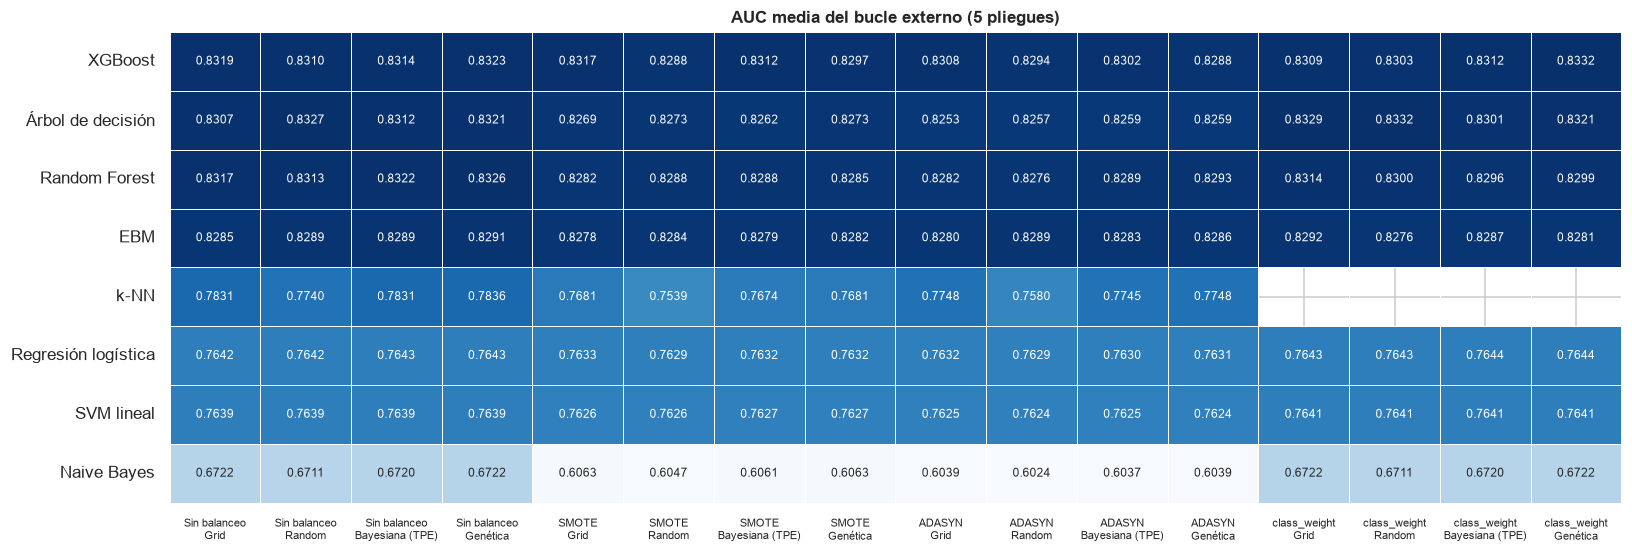

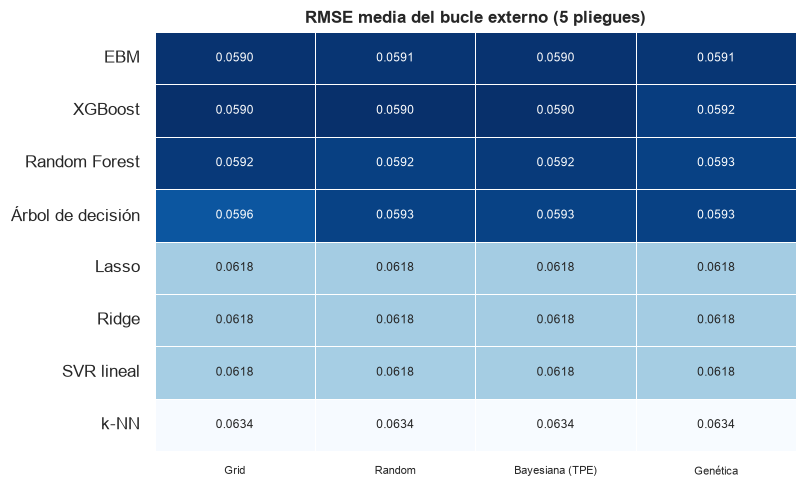

In [25]:
fig, ax = plt.subplots(figsize=(15, 5.2))
graficos.mapa_corridas(tabla, 'clasificacion', ax=ax)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7.5, 4.6))
graficos.mapa_corridas(tabla, 'regresion', ax=ax)
plt.tight_layout()
plt.show()

## La mejor combinación de cada modelo

Es la que se lleva a la evaluación en prueba y a la comparación estadística. Se elige por la
métrica media del bucle externo, sin mirar la prueba.

In [26]:
def tabla_mejores(tarea):
    m = analisis.mejores_por_modelo(tabla, tarea)
    return pd.DataFrame({
        'modelo': m['modelo'].map(NOMBRES_MODELO), 'balanceo': m['balanceo'], 'optimizador': m['optimizador'],
        ('AUC' if tarea == 'clasificacion' else 'RMSE') + ' externa': m['metrica'], 'desv. entre pliegues': m['desv_ext'],
        'minutos': m['tiempo_total_s'] / 60,
        'hiperparámetros finales': m['hiperparametros'].apply(
            lambda h: ', '.join(f'{k.split("__", 1)[1]}={v:.4g}' if isinstance(v, float) else f'{k.split("__", 1)[1]}={v}'
                                for k, v in h.items()))}).set_index('modelo')

mejores_clf, mejores_reg = tabla_mejores('clasificacion'), tabla_mejores('regresion')
display(mejores_clf)
display(mejores_reg)

,balanceo,optimizador,AUC externa,desv. entre pliegues,minutos,hiperparámetros finales
modelo,,,,,,
XGBoost,class_weight,genetica,0.8332,0.0049,8.8883,"n_estimators=145, max_depth=6, learning_rate=0.003304, subsample=0.8081, colsample_bytree=0.9683, reg_lambda=0.8792,..."
Árbol de decisión,class_weight,random,0.8332,0.0021,1.8027,"ccp_alpha=0.0003897, criterion=gini, max_depth=22, min_samples_leaf=7"
Random Forest,ninguno,genetica,0.8326,0.0029,20.8890,"max_depth=32, max_features=0.5, min_samples_leaf=11, n_estimators=300"
EBM,class_weight,grid,0.8292,0.0037,18.6728,"interactions=0, learning_rate=0.008, max_leaves=2, min_samples_leaf=100, outer_bags=8"
k-NN,ninguno,genetica,0.7836,0.0072,34.7139,"n_neighbors=600, weights=distance, p=1"
Regresión logística,class_weight,genetica,0.7644,0.0047,3.0827,"C=0.05631, l1_ratio=1"
SVM lineal,class_weight,grid,0.7641,0.0044,2.0670,C=0.001083
Naive Bayes,ninguno,grid,0.6722,0.0119,0.6732,var_smoothing=0.001


,balanceo,optimizador,RMSE externa,desv. entre pliegues,minutos,hiperparámetros finales
modelo,,,,,,
XGBoost,ninguno,bayesiana,0.0590,0.0004,10.3978,"n_estimators=512, max_depth=2, learning_rate=0.02361, subsample=0.8025, colsample_bytree=0.7268, reg_lambda=0.2158, ..."
EBM,ninguno,grid,0.0590,0.0004,26.5974,"interactions=0, learning_rate=0.008, max_leaves=3, min_samples_leaf=20, outer_bags=8"
Random Forest,ninguno,grid,0.0592,0.0004,16.0544,"max_depth=8, max_features=0.5, min_samples_leaf=50, n_estimators=300"
Árbol de decisión,ninguno,genetica,0.0593,0.0004,3.7207,"max_depth=13, min_samples_leaf=101, ccp_alpha=1.811e-06"
Lasso,ninguno,genetica,0.0618,0.0005,6.6994,alpha=0.0001087
Ridge,ninguno,genetica,0.0618,0.0005,1.4725,alpha=613.9
SVR lineal,ninguno,bayesiana,0.0618,0.0005,2.6889,"C=46.43, epsilon=0.0003846"
k-NN,ninguno,grid,0.0634,0.0004,24.9263,"n_neighbors=80, p=1, weights=distance"


In [27]:
mc = analisis.mejores_por_modelo(tabla, 'clasificacion')
mr = analisis.mejores_por_modelo(tabla, 'regresion')
display(Markdown(f"""
En **clasificación** el orden es {enumerar(f"{NOMBRES_MODELO[f.modelo]} ({dec(f.metrica)})" for f in mc.itertuples())}.
Los modelos basados en árboles encabezan la tabla con diferencias de milésimas entre sí; k-NN queda
{dec(mc.iloc[0]['metrica'] - mc.set_index('modelo').loc['knn', 'metrica'], 3)} por debajo del mejor y los dos lineales, unas
{dec(mc.iloc[0]['metrica'] - mc.set_index('modelo').loc['logistica', 'metrica'], 2)}. En **regresión**, {enumerar(f"{NOMBRES_MODELO[f.modelo]} ({dec(f.metrica)})" for f in mr.itertuples())}.
La desviación entre pliegues externos es de {dec(mc['desv_ext'].min(), 4)} a {dec(mc['desv_ext'].max(), 4)} de AUC: del mismo
orden que las diferencias entre los mejores modelos, que por eso se contrastan formalmente en la
sección de comparación estadística.
"""))


En **clasificación** el orden es XGBoost (0,8332), Árbol de decisión (0,8332), Random Forest (0,8326), EBM (0,8292), k-NN (0,7836), Regresión logística (0,7644), SVM lineal (0,7641) y Naive Bayes (0,6722).
Los modelos basados en árboles encabezan la tabla con diferencias de milésimas entre sí; k-NN queda
0,050 por debajo del mejor y los dos lineales, unas
0,07. En **regresión**, XGBoost (0,0590), EBM (0,0590), Random Forest (0,0592), Árbol de decisión (0,0593), Lasso (0,0618), Ridge (0,0618), SVR lineal (0,0618) y k-NN (0,0634).
La desviación entre pliegues externos es de 0,0021 a 0,0119 de AUC: del mismo
orden que las diferencias entre los mejores modelos, que por eso se contrastan formalmente en la
sección de comparación estadística.


### Todas las métricas como media ± desviación de los pliegues externos

La guía (§5.4) pide reportar cada métrica como media ± desviación estándar sobre los pliegues del
bucle externo. La tabla lo hace para la mejor combinación de cada modelo, con todas las métricas que
registra la tabla maestra (las de clasificación con umbral usan 0,5).

In [28]:
def media_desv(fila, metricas):
    return {m: f"{np.mean(fila['metricas_ext'][m]):.4f} ± {np.std(fila['metricas_ext'][m], ddof=1):.4f}"
            for m in metricas if m in fila['metricas_ext']}

pliegues_clf = pd.DataFrame({NOMBRES_MODELO[f['modelo']]: media_desv(f, ['auc', 'accuracy', 'precision', 'recall', 'f1', 'brier'])
                             for _, f in analisis.mejores_por_modelo(tabla, 'clasificacion').iterrows()}).T
pliegues_reg = pd.DataFrame({NOMBRES_MODELO[f['modelo']]: media_desv(f, ['rmse', 'mae', 'r2'])
                             for _, f in analisis.mejores_por_modelo(tabla, 'regresion').iterrows()}).T
display(pliegues_clf)
display(pliegues_reg)

,auc,accuracy,precision,recall,f1,brier
XGBoost,0.8332 ± 0.0049,0.7007 ± 0.0051,0.4506 ± 0.0039,0.9866 ± 0.0151,0.6186 ± 0.0038,0.2098 ± 0.0211
Árbol de decisión,0.8332 ± 0.0021,0.7009 ± 0.0051,0.4512 ± 0.0042,0.9976 ± 0.0021,0.6214 ± 0.0040,0.1664 ± 0.0030
Random Forest,0.8326 ± 0.0029,0.7838 ± 0.0037,0.6603 ± 0.0301,0.2521 ± 0.0212,0.3641 ± 0.0193,0.1307 ± 0.0012
EBM,0.8292 ± 0.0037,0.7311 ± 0.0047,0.4690 ± 0.0056,0.7008 ± 0.0134,0.5618 ± 0.0037,0.1724 ± 0.0032
k-NN,0.7836 ± 0.0072,0.7540 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.1667 ± 0.0004
Regresión logística,0.7644 ± 0.0047,0.6733 ± 0.0035,0.4026 ± 0.0030,0.6770 ± 0.0126,0.5049 ± 0.0039,0.1992 ± 0.0009
SVM lineal,0.7641 ± 0.0044,0.6723 ± 0.0022,0.4015 ± 0.0026,0.6770 ± 0.0151,0.5041 ± 0.0056,nan ± nan
Naive Bayes,0.6722 ± 0.0119,0.2882 ± 0.0068,0.2527 ± 0.0026,0.9670 ± 0.0074,0.4007 ± 0.0038,0.6550 ± 0.0244


,rmse,mae,r2
XGBoost,0.0590 ± 0.0004,0.0469 ± 0.0004,0.2274 ± 0.0086
EBM,0.0590 ± 0.0004,0.0471 ± 0.0004,0.2260 ± 0.0094
Random Forest,0.0592 ± 0.0004,0.0471 ± 0.0003,0.2230 ± 0.0077
Árbol de decisión,0.0593 ± 0.0004,0.0474 ± 0.0003,0.2200 ± 0.0074
Lasso,0.0618 ± 0.0005,0.0508 ± 0.0003,0.1518 ± 0.0099
Ridge,0.0618 ± 0.0005,0.0508 ± 0.0004,0.1514 ± 0.0098
SVR lineal,0.0618 ± 0.0005,0.0509 ± 0.0003,0.1509 ± 0.0103
k-NN,0.0634 ± 0.0004,0.0513 ± 0.0002,0.1087 ± 0.0043


## El efecto del balanceo

La guía (§5.1) pide comparar sin balanceo, SMOTE, ADASYN y `class_weight`. El balanceo actúa sobre
el entrenamiento de cada pliegue (SMOTE y ADASYN generan clientes sintéticos de riesgo alto;
`class_weight` pondera los errores de la clase minoritaria) y nunca sobre los datos de validación o
prueba. Para cada modelo se toma el mejor optimizador dentro de cada técnica.

In [29]:
clf = ok[ok['tarea'] == 'clasificacion'].copy()
mejor_por_bal = clf.loc[clf.groupby(['modelo', 'balanceo'])['metrica'].idxmax()]
efecto_auc = mejor_por_bal.pivot(index='modelo', columns='balanceo', values='metrica')
efecto_auc = efecto_auc[[b for b in graficos.NOMBRE_BALANCEO if b in efecto_auc.columns]]
delta = efecto_auc.sub(efecto_auc['ninguno'], axis=0).drop(columns='ninguno')
delta.index = [NOMBRES_MODELO[m] for m in delta.index]
display(delta.style.format('{:+.4f}', na_rep='no aplica').background_gradient(cmap='RdBu', vmin=-0.05, vmax=0.05))

matriz_bal = clf.pivot_table(index=['modelo', 'optimizador'], columns='balanceo', values='metrica')[
    ['ninguno', 'smote', 'adasyn']].dropna()
fr_bal = est.friedman(matriz_bal)
fr_bal['rangos_medios']

balanceo,smote,adasyn,class_weight
Árbol de decisión,-0.0054,-0.0068,+0.0005
EBM,-0.0007,-0.0002,+0.0001
k-NN,-0.0154,-0.0087,no aplica
Regresión logística,-0.0010,-0.0011,+0.0001
Naive Bayes,-0.0659,-0.0683,-0.0000
Random Forest,-0.0037,-0.0032,-0.0012
SVM lineal,-0.0012,-0.0014,+0.0002
XGBoost,-0.0006,-0.0015,+0.0009


balanceo
ninguno   1.0312
smote     2.3438
adasyn    2.6250
dtype: float64

In [30]:
def media_pliegues(fila, metrica):
    return float(np.mean(fila['metricas_ext'][metrica]))

for metrica in ('recall', 'precision', 'f1', 'brier'):
    mejor_por_bal[metrica] = mejor_por_bal.apply(lambda f: media_pliegues(f, metrica), axis=1)
umbral = mejor_por_bal[mejor_por_bal['modelo'].isin(['xgboost', 'random_forest', 'logistica', 'arbol'])]
compromiso = umbral.pivot_table(index='modelo', columns='balanceo', values=['recall', 'precision'])
compromiso.index = [NOMBRES_MODELO[m] for m in compromiso.index]
compromiso

precision                             recall               \
balanceo               adasyn class_weight ninguno  smote adasyn class_weight   
Árbol de decisión      0.4874       0.4512  0.6935 0.4879 0.5604       0.9976   
Regresión logística    0.4028       0.4026  0.6215 0.4016 0.6711       0.6770   
Random Forest          0.5142       0.4517  0.6603 0.5266 0.4606       0.9870   
XGBoost                0.5787       0.4506  0.0000 0.5783 0.3318       0.9866   

                                    
balanceo            ninguno  smote  
Árbol de decisión    0.2224 0.6023  
Regresión logística  0.2799 0.6726  
Random Forest        0.2521 0.4391  
XGBoost              0.0000 0.3290

In [31]:
dif_smote = delta['smote'].dropna()
dif_adasyn = delta['adasyn'].dropna()
dif_cw = delta['class_weight'].dropna()
rec = umbral.pivot_table(index='modelo', columns='balanceo', values='recall')
prob_max_sin = None
siempre_mejor = fr_bal['rangos_medios'].get('ninguno', 99) == 1.0
peor_smote = dif_smote.idxmin()
frase_umbral = (f"Con el umbral de 0,5, el recall de XGBoost pasa de {dec(rec.loc['xgboost', 'ninguno'], 3)} sin balanceo a "
                f"{dec(rec.loc['xgboost', 'class_weight'], 3)} con `class_weight`, a costa de la precisión")
if rec.loc['xgboost', 'ninguno'] == 0:
    frase_umbral += (': su mejor configuración sin balanceo (una tasa de aprendizaje muy baja con pocos árboles) '
                     'no asigna a ningún cliente una probabilidad mayor que 0,5, aunque los ordena tan bien como las demás')
display(Markdown(f"""
**`class_weight` no cambia el AUC** (de {dec(dif_cw.min(), 4, True)} a {dec(dif_cw.max(), 4, True)} frente a no balancear),
y **el sobremuestreo lo empeora**: SMOTE entre {dec(dif_smote.max(), 4, True)} y {dec(dif_smote.min(), 4, True)}, y ADASYN entre
{dec(dif_adasyn.max(), 4, True)} y {dec(dif_adasyn.min(), 4, True)}. {'En todos los bloques modelo × optimizador, no balancear es la mejor de las tres opciones (rango medio 1,00' if siempre_mejor else 'Friedman sobre los bloques modelo × optimizador da rangos medios ' + enumerar(f"{graficos.NOMBRE_BALANCEO[b]} {dec(v, 2)}" for b, v in fr_bal['rangos_medios'].items()) + ' ('}; Friedman {p_valor(fr_bal['p'])}). El AUC mide el orden de los clientes: reponderar
la clase minoritaria desplaza las probabilidades sin cambiar ese orden, y los clientes sintéticos de
SMOTE y ADASYN, interpolados entre vecinos de riesgo alto, añaden ruido en la frontera entre clases. El
caso extremo es {NOMBRES_MODELO.get(peor_smote, peor_smote)} ({dec(dif_smote.min(), 4, True)} con SMOTE): los clientes sintéticos alteran
las medias y varianzas por clase que el modelo estima.

**Donde sí actúa el balanceo es en las métricas que dependen del umbral.** {frase_umbral}. Es el mismo
efecto que se lograría moviendo el umbral de un modelo sin balancear: la elección no es de modelo
sino de punto de operación, y se trata con la calibración y el umbral en la sección de evaluación.
"""))


**`class_weight` no cambia el AUC** (de −0,0012 a +0,0009 frente a no balancear),
y **el sobremuestreo lo empeora**: SMOTE entre −0,0006 y −0,0659, y ADASYN entre
−0,0002 y −0,0683. Friedman sobre los bloques modelo × optimizador da rangos medios Sin balanceo 1,03, SMOTE 2,34 y ADASYN 2,62 (; Friedman p < 10⁻¹⁰). El AUC mide el orden de los clientes: reponderar
la clase minoritaria desplaza las probabilidades sin cambiar ese orden, y los clientes sintéticos de
SMOTE y ADASYN, interpolados entre vecinos de riesgo alto, añaden ruido en la frontera entre clases. El
caso extremo es Naive Bayes (−0,0659 con SMOTE): los clientes sintéticos alteran
las medias y varianzas por clase que el modelo estima.

**Donde sí actúa el balanceo es en las métricas que dependen del umbral.** Con el umbral de 0,5, el recall de XGBoost pasa de 0,000 sin balanceo a 0,987 con `class_weight`, a costa de la precisión: su mejor configuración sin balanceo (una tasa de aprendizaje muy baja con pocos árboles) no asigna a ningún cliente una probabilidad mayor que 0,5, aunque los ordena tan bien como las demás. Es el mismo
efecto que se lograría moviendo el umbral de un modelo sin balancear: la elección no es de modelo
sino de punto de operación, y se trata con la calibración y el umbral en la sección de evaluación.


## Coste de las corridas

In [32]:
horas = ok.pivot_table(index='modelo', columns='optimizador', values='tiempo_total_s', aggfunc='sum') / 3600
horas = horas[analisis.OPTIMIZADORES]
horas['total'] = horas.sum(axis=1)
horas.index = [NOMBRES_MODELO[m] for m in horas.index]
display(horas.sort_values('total', ascending=False))
total_guia = guia[guia['estado'] == 'ok']['tiempo_total_s'].sum() / 3600
caros = horas.drop(index=NOMBRES_MODELO['ebm'], errors='ignore').sort_values('total', ascending=False)
horas_ebm = horas.loc[NOMBRES_MODELO['ebm'], 'total'] if NOMBRES_MODELO['ebm'] in horas.index else None
display(Markdown(f"""
Las 140 corridas de la guía sumaron {dec(total_guia, 1)} horas de reloj en el equipo de 6 núcleos lógicos. Los
modelos más caros fueron {enumerar(f"{m} ({dec(h, 1)} h)" for m, h in caros['total'].head(3).items())}; los más
baratos, {enumerar(f"{m} ({dec(h * 60, 0)} min)" for m, h in caros['total'].tail(2).items())}.{(' Las 20 corridas de la EBM sumaron por sí solas ' + dec(horas_ebm, 1) + ' horas, sobre todo por el sobremuestreo (sección del modelo nuevo).') if horas_ebm else ''} En k-NN cada evaluación calcula
distancias entre todos los pares de clientes del pliegue; en Random Forest pesan los 300 árboles del
modelo final (la búsqueda ya usaba solo 100 gracias a la multi-fidelidad). La sección de cómputo mide
estos costes uno a uno y prueba alternativas más rápidas.
"""))

optimizador,grid,random,bayesiana,genetica,total
EBM,4.1947,4.3745,5.9366,4.9597,19.4655
Random Forest,2.5857,2.2791,3.0343,2.3189,10.2180
k-NN,1.3450,1.0057,2.7911,2.9965,8.1383
XGBoost,0.5280,0.7733,1.3344,1.6079,4.2435
Árbol de decisión,0.2086,0.2350,0.4377,0.4500,1.3312
Regresión logística,0.2260,0.2101,0.3068,0.2933,1.0362
SVM lineal,0.1736,0.1686,0.2490,0.2558,0.8469
Naive Bayes,0.0768,0.0769,0.1492,0.1489,0.4518
Lasso,0.1183,0.1203,0.0849,0.1117,0.4351
SVR lineal,0.0308,0.0281,0.0448,0.0436,0.1474



Las 140 corridas de la guía sumaron 26,9 horas de reloj en el equipo de 6 núcleos lógicos. Los
modelos más caros fueron Random Forest (10,2 h), k-NN (8,1 h) y XGBoost (4,2 h); los más
baratos, SVR lineal (9 min) y Ridge (5 min). Las 20 corridas de la EBM sumaron por sí solas 19,5 horas, sobre todo por el sobremuestreo (sección del modelo nuevo). En k-NN cada evaluación calcula
distancias entre todos los pares de clientes del pliegue; en Random Forest pesan los 300 árboles del
modelo final (la búsqueda ya usaba solo 100 gracias a la multi-fidelidad). La sección de cómputo mide
estos costes uno a uno y prueba alternativas más rápidas.


## Estabilidad de los hiperparámetros entre pliegues

Si los hiperparámetros ganadores cambian mucho de un pliegue externo a otro, la búsqueda es
inestable o el óptimo es una meseta plana donde muchas configuraciones rinden igual. La tabla cuenta,
para cada optimizador, cuántas configuraciones distintas eligieron los 5 pliegues de cada corrida.

In [33]:
def distintas(params):
    return len({tuple(sorted((k, round(v, 6) if isinstance(v, float) else v) for k, v in p.items())) for p in params})

ok_est = ok.assign(configuraciones_distintas=ok['params_por_pliegue'].apply(distintas))
estabilidad = ok_est.groupby(['tarea', 'optimizador'])['configuraciones_distintas'].agg(['mean', 'min', 'max']).reindex(
    analisis.OPTIMIZADORES, level='optimizador')
estabilidad

mean  min  max
tarea         optimizador                 
clasificacion grid        2.7742    1    5
              random      2.9677    1    5
              bayesiana   4.2258    1    5
              genetica    3.4194    1    5
regresion     grid        2.3750    1    4
              random      2.2500    1    4
              bayesiana   3.8750    2    5
              genetica    4.0000    1    5

In [34]:
e = estabilidad.xs('clasificacion')
display(Markdown(f"""
En clasificación, Grid y Random son los más estables ({dec(e.loc['grid', 'mean'], 1)} y {dec(e.loc['random', 'mean'], 1)}
configuraciones distintas de media en 5 pliegues): los dos evalúan el **mismo conjunto de candidatos**
en todos los pliegues (la rejilla, o la misma muestra aleatoria porque la semilla es fija), así que
solo cambia cuál gana. La bayesiana ({dec(e.loc['bayesiana', 'mean'], 1)}) y la genética ({dec(e.loc['genetica', 'mean'], 1)})
adaptan sus propuestas a los puntajes de cada pliegue y rara vez visitan los mismos puntos. Que
configuraciones distintas den la misma métrica externa (la desviación entre pliegues es de
milésimas) indica que el óptimo es una meseta: lo que importa es llegar a ella, no el punto exacto,
y eso es coherente con que los cuatro métodos terminen en el mismo nivel.
"""))


En clasificación, Grid y Random son los más estables (2,8 y 3,0
configuraciones distintas de media en 5 pliegues): los dos evalúan el **mismo conjunto de candidatos**
en todos los pliegues (la rejilla, o la misma muestra aleatoria porque la semilla es fija), así que
solo cambia cuál gana. La bayesiana (4,2) y la genética (3,4)
adaptan sus propuestas a los puntajes de cada pliegue y rara vez visitan los mismos puntos. Que
configuraciones distintas den la misma métrica externa (la desviación entre pliegues es de
milésimas) indica que el óptimo es una meseta: lo que importa es llegar a ella, no el punto exacto,
y eso es coherente con que los cuatro métodos terminen en el mismo nivel.


# Comparación de los métodos de optimización

La guía (§3.4) pide comparar los cuatro métodos de búsqueda de hiperparámetros por la métrica del
bucle externo, el tiempo total y por evaluación, el número de evaluaciones y las curvas *anytime*,
y aportar evidencia cuantitativa de si la optimización bayesiana y la genética rinden más por
unidad de presupuesto. Esta página responde con los registros de la tabla maestra: cada corrida
guarda, para cada pliegue externo, la traza del mejor puntaje interno tras cada evaluación, el
historial de Optuna y, en el genético, la diversidad de la población por generación.

**Diseño de la comparación.** Dentro de cada modelo los cuatro métodos reciben el mismo presupuesto:
tantas configuraciones como tiene la rejilla de Grid Search de ese modelo (entre 30 y 48). Cada
configuración se evalúa con la misma validación interna de 3 pliegues dentro de cada uno de los 5
pliegues externos, de modo que las diferencias se deben solo a *qué* configuraciones elige cada
método y en qué orden. Un **bloque** es una pareja modelo × balanceo: los cuatro métodos se comparan
dentro del bloque y los bloques hacen de repeticiones. El análisis usa las 140 corridas de la guía,
que se ejecutaron en serie y con el equipo dedicado; las 20 del modelo nuevo siguen el mismo diseño,
pero compartieron el equipo con otros trabajos y sus tiempos no son comparables.

In [35]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, graficos
from src import estadistica as est
from src.formato import dec, ent, enumerar, p_valor, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

tabla = analisis.cargar_tabla()
tabla = tabla[tabla['modelo'] != 'ebm']          # las 140 corridas de la guía
ok = tabla[tabla['estado'] == 'ok']
print(f'corridas de la guía: {len(tabla)} · entrenadas: {len(ok)} · '
      f'no aplican: {(tabla["estado"] == "no_aplica").sum()}')
print(ok.groupby(['tarea', 'optimizador']).size().unstack())

corridas de la guía: 140 · entrenadas: 136 · no aplican: 4
optimizador    bayesiana  genetica  grid  random
tarea                                           
clasificacion         27        27    27      27
regresion              7         7     7       7


## Resumen por método

Para cada tarea, el rango medio ordena los cuatro métodos dentro de cada bloque por la métrica del
bucle externo (1 = mejor; los empates reparten el rango) y las victorias cuentan en cuántos bloques
fue el mejor. El tiempo por evaluación es el tiempo de búsqueda entre el número de configuraciones
evaluadas, y el optimismo es la diferencia entre el mejor puntaje de la validación interna y el del
bucle externo.

In [36]:
resumen = analisis.resumen_optimizadores(tabla)
resumen

corridas  rango_medio  victorias  metrica_media  \
tarea         optimizador                                                    
clasificacion grid               27       2.2222         12         0.7759   
              random             27       3.2222          4         0.7740   
              bayesiana          27       2.6296          2         0.7757   
              genetica           27       1.9259         15         0.7760   
regresion     grid                7       2.7143          2         0.0609   
              random              7       2.7143          0         0.0609   
              bayesiana           7       2.1429          2         0.0609   
              genetica            7       2.4286          3         0.0609   

                           evaluaciones  s_por_evaluacion  min_por_corrida  \
tarea         optimizador                                                    
clasificacion grid             170.3704            2.6095           9.6200   
              random           170.3704            2.4555           9.0566   
              bayesiana        170.3704            4.4804          16.0614   
              genetica         170.3704            4.2678          15.3162   
regresion     grid             170.0000            2.4319           8.3754   
              random           170.0000            2.0550           7.1805   
              bayesiana        170.0000            2.9382          10.5272   
              genetica         170.0000            3.3694          11.6464   

                           horas_totales  optimismo  
tarea         optimizador                            
clasificacion grid                4.3290    -0.0013  
              random              4.0755    -0.0009  
              bayesiana           7.2276    -0.0010  
              genetica            6.8923    -0.0012  
regresion     grid                0.9771    -0.0001  
              random              0.8377    -0.0001  
              bayesiana           1.2282    -0.0001  
              genetica            1.3587    -0.0001

In [37]:
def fila(tarea, opt, col):
    return resumen.loc[(tarea, opt), col]

ratio_t = {t: (fila(t, 'bayesiana', 's_por_evaluacion') + fila(t, 'genetica', 's_por_evaluacion'))
           / (fila(t, 'grid', 's_por_evaluacion') + fila(t, 'random', 's_por_evaluacion'))
           for t in ('clasificacion', 'regresion')}
horas = resumen['horas_totales'].sum()
display(Markdown(f"""
Las {ent(len(ok))} corridas entrenadas consumieron {dec(horas, 1)} horas de cómputo. Con el mismo
número de evaluaciones, la bayesiana y la genética tardaron **{dec(ratio_t['clasificacion'], 1)} veces
más por evaluación** que Grid y Random en clasificación y {dec(ratio_t['regresion'], 1)} veces más en
regresión. La causa no es el coste del método (proponer un punto con TPE o generar una población
cuesta milisegundos) sino el paralelismo: Grid y Random conocen de antemano todas sus
configuraciones y `scikit-learn` reparte configuraciones × pliegues entre los 6 núcleos, mientras
que la bayesiana y la genética necesitan el resultado de una evaluación para proponer la siguiente
(o la generación siguiente), así que solo paralelizan los 3 pliegues internos de cada evaluación.
"""))


Las 136 corridas entrenadas consumieron 26,9 horas de cómputo. Con el mismo
número de evaluaciones, la bayesiana y la genética tardaron **1,7 veces
más por evaluación** que Grid y Random en clasificación y 1,4 veces más en
regresión. La causa no es el coste del método (proponer un punto con TPE o generar una población
cuesta milisegundos) sino el paralelismo: Grid y Random conocen de antemano todas sus
configuraciones y `scikit-learn` reparte configuraciones × pliegues entre los 6 núcleos, mientras
que la bayesiana y la genética necesitan el resultado de una evaluación para proponer la siguiente
(o la generación siguiente), así que solo paralelizan los 3 pliegues internos de cada evaluación.


## ¿Encuentran configuraciones distintas? Prueba de Friedman sobre la métrica externa

Si los métodos fueran equivalentes, su rango dentro de cada bloque sería aleatorio. La prueba de
Friedman contrasta esa hipótesis con los rangos de los bloques completos, y el diagrama de
diferencia crítica de Nemenyi muestra qué parejas de métodos se distinguen (las unidas por una barra
no difieren al 5 %).

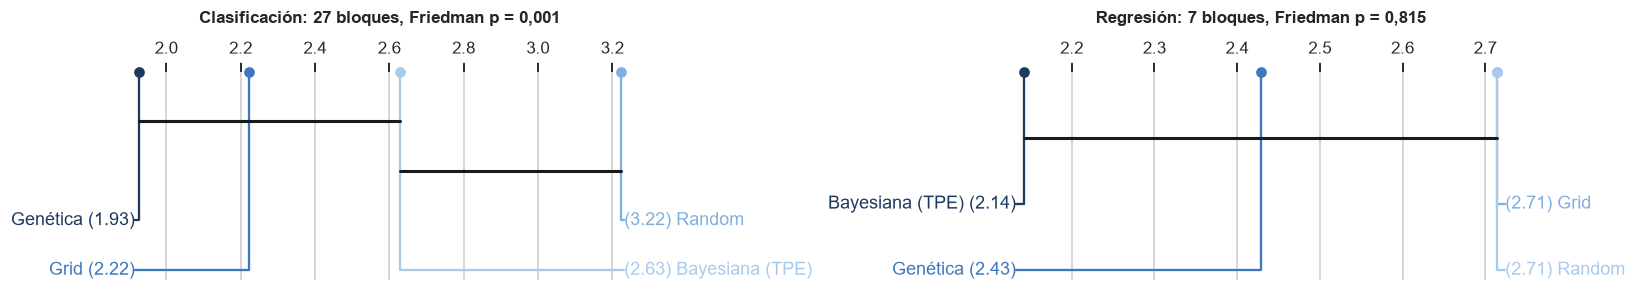

,bloques,chi2,p,F Iman-Davenport,p Iman-Davenport,diferencia crítica
clasificacion,27.0000,15.6591,0.0013,6.2310,0.0008,0.9027
regresion,7.0000,0.9429,0.8151,0.2821,0.8377,1.7728


In [38]:
friedman_metrica = {t: est.friedman(analisis.matriz_optimizadores(tabla, t)) for t in ('clasificacion', 'regresion')}
fig, ax = plt.subplots(1, 2, figsize=(15, 2.8))
for a, (t, r) in zip(ax, friedman_metrica.items()):
    graficos.diagrama_cd(r, ax=a, etiquetas=graficos.NOMBRE_OPTIMIZADOR,
                         titulo=f'{graficos.NOMBRE_TAREA[t]}: {r["n_bloques"]} bloques, Friedman {p_valor(r["p"], grafico=True)}')
plt.tight_layout()
plt.show()
pd.DataFrame({t: {'bloques': r['n_bloques'], 'chi2': r['chi2'], 'p': r['p'],
                  'F Iman-Davenport': r['F'], 'p Iman-Davenport': r['p_iman_davenport'],
                  'diferencia crítica': r['dc']} for t, r in friedman_metrica.items()}).T

In [39]:
dif_grid = analisis.diferencias_con_grid(tabla)
dif_grid

bloques   media  minimo  maximo  supera_a_grid  \
tarea         optimizador                                                   
clasificacion random            27 -0.0019 -0.0168  0.0019         0.2593   
              bayesiana         27 -0.0002 -0.0028  0.0008         0.4074   
              genetica          27  0.0001 -0.0020  0.0023         0.4444   
regresion     random             7  0.0000 -0.0001  0.0003         0.4286   
              bayesiana          7  0.0000 -0.0000  0.0003         0.7143   
              genetica           7  0.0000 -0.0002  0.0004         0.5714   

                           p_wilcoxon  
tarea         optimizador              
clasificacion random           0.0039  
              bayesiana        0.1864  
              genetica         0.4140  
regresion     random           1.0000  
              bayesiana        0.6875  
              genetica         0.9375

In [40]:
fc, fr = friedman_metrica['clasificacion'], friedman_metrica['regresion']
rc = fc['rangos_medios']
d_random = dif_grid.loc[('clasificacion', 'random')]
display(Markdown(f"""
En **clasificación** los métodos no son equivalentes (Friedman {p_valor(fc['p'])}, Iman-Davenport
{p_valor(fc['p_iman_davenport'])}, {fc['n_bloques']} bloques). El orden por rango medio es
{enumerar(f"{graficos.NOMBRE_CORTO_OPTIMIZADOR[o]} ({dec(v, 2)})" for o, v in rc.items())}. La diferencia que
sostiene la prueba es la de **Random**, que queda por debajo de Grid en {pct(1 - d_random['supera_a_grid'], 0)}
de los bloques, con una pérdida media de {dec(-d_random['media'], 4)} de AUC y hasta {dec(-d_random['minimo'], 4)}
en el peor bloque (Wilcoxon {p_valor(d_random['p_wilcoxon'])}). La bayesiana y la genética terminan
en el mismo nivel que Grid: sus diferencias medias son de {dec(dif_grid.loc[('clasificacion', 'bayesiana'), 'media'], 5, True)}
y {dec(dif_grid.loc[('clasificacion', 'genetica'), 'media'], 5, True)} de AUC, sin significación.

En **regresión** no hay diferencias (Friedman {p_valor(fr['p'])}, {fr['n_bloques']} bloques): con
uno a tres hiperparámetros por modelo, cualquier método que recorra el espacio con 30 puntos llega
al mismo óptimo.

La métrica final, por tanto, no separa a la bayesiana y la genética de Grid. Lo que sí las separa es
**cuánto presupuesto necesitan** para llegar a ese nivel, que es lo que miden las curvas *anytime*.
"""))


En **clasificación** los métodos no son equivalentes (Friedman p = 0,001, Iman-Davenport
p < 0,001, 27 bloques). El orden por rango medio es
genética (1,93), Grid (2,22), bayesiana (2,63) y Random (3,22). La diferencia que
sostiene la prueba es la de **Random**, que queda por debajo de Grid en 74 %
de los bloques, con una pérdida media de 0,0019 de AUC y hasta 0,0168
en el peor bloque (Wilcoxon p = 0,004). La bayesiana y la genética terminan
en el mismo nivel que Grid: sus diferencias medias son de −0,00022
y +0,00006 de AUC, sin significación.

En **regresión** no hay diferencias (Friedman p = 0,815, 7 bloques): con
uno a tres hiperparámetros por modelo, cualquier método que recorra el espacio con 30 puntos llega
al mismo óptimo.

La métrica final, por tanto, no separa a la bayesiana y la genética de Grid. Lo que sí las separa es
**cuánto presupuesto necesitan** para llegar a ese nivel, que es lo que miden las curvas *anytime*.


## Rendimiento por unidad de presupuesto: curvas *anytime*

Para cada bloque y cada pliegue externo se toma como referencia el mejor puntaje interno que
alcanzó cualquiera de los cuatro métodos y como punto de partida el peor primer puntaje. El
**arrepentimiento normalizado** tras *t* evaluaciones es la fracción de esa brecha que el método
todavía no ha cerrado: vale 1 al principio y 0 cuando el método ya encontró lo mejor que se
encontró. Así se pueden promediar modelos con métricas en escalas distintas. El área bajo la curva
resume la eficiencia en una cifra (menor es mejor) y se contrasta con Friedman sobre las
búsquedas (bloque × pliegue).

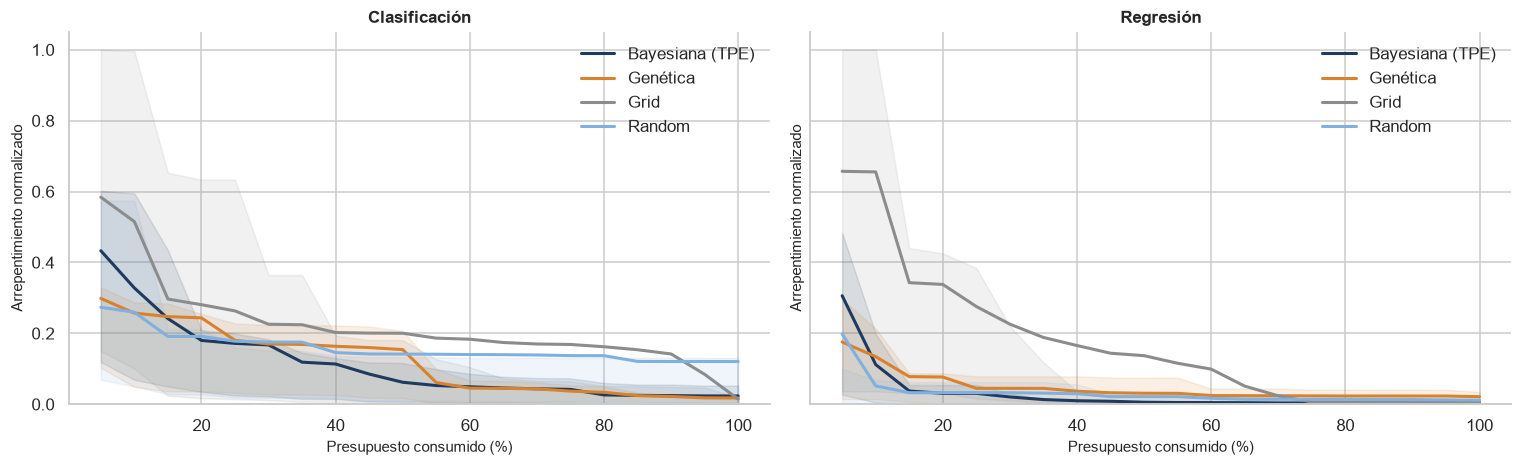

In [41]:
anytime = {t: analisis.curvas_anytime(tabla, t) for t in ('clasificacion', 'regresion')}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for a, (t, (curvas, _)) in zip(ax, anytime.items()):
    graficos.curvas_anytime(curvas, ax=a, titulo=graficos.NOMBRE_TAREA[t])
plt.tight_layout()
plt.show()

In [42]:
filas = []
friedman_area = {}
for t, (_, por_busqueda) in anytime.items():
    m = por_busqueda.pivot_table(index=['modelo', 'balanceo', 'pliegue'], columns='optimizador', values='area')
    friedman_area[t] = est.friedman(m[analisis.OPTIMIZADORES], mayor_es_mejor=False)
    g = por_busqueda.groupby('optimizador')
    resumen_area = pd.DataFrame({
        'área media': g['area'].mean(), 'arrepentimiento final': g['final'].mean(),
        'evaluaciones hasta el 95 %': g['evals_al_95'].mean(),
        'búsquedas que llegan al 95 %': g['evals_al_95'].apply(lambda s: s.notna().mean()),
        'rango medio del área': friedman_area[t]['rangos_medios']})
    filas.append(resumen_area.reindex(analisis.OPTIMIZADORES).assign(tarea=t).set_index('tarea', append=True)
                 .reorder_levels([1, 0]))
eficiencia = pd.concat(filas)
eficiencia

área media  arrepentimiento final  \
tarea         optimizador                                      
clasificacion grid             0.2342                 0.0146   
              random           0.1707                 0.1205   
              bayesiana        0.1226                 0.0234   
              genetica         0.1365                 0.0176   
regresion     grid             0.1811                 0.0065   
              random           0.0409                 0.0117   
              bayesiana        0.0377                 0.0029   
              genetica         0.0575                 0.0214   

                           evaluaciones hasta el 95 %  \
tarea         optimizador                               
clasificacion grid                            14.2195   
              random                           7.1912   
              bayesiana                       10.2900   
              genetica                        13.0690   
regresion     grid                             9.9143   
              random                           7.4062   
              bayesiana                        5.4571   
              genetica                         7.4000   

                           búsquedas que llegan al 95 %  rango medio del área  
tarea         optimizador                                                      
clasificacion grid                               0.9111                2.9407  
              random                             0.5037                2.4481  
              bayesiana                          0.7407                2.0111  
              genetica                           0.8593                2.6000  
regresion     grid                               1.0000                3.5714  
              random                             0.9143                2.2000  
              bayesiana                          1.0000                1.9429  
              genetica                           0.8571                2.2857

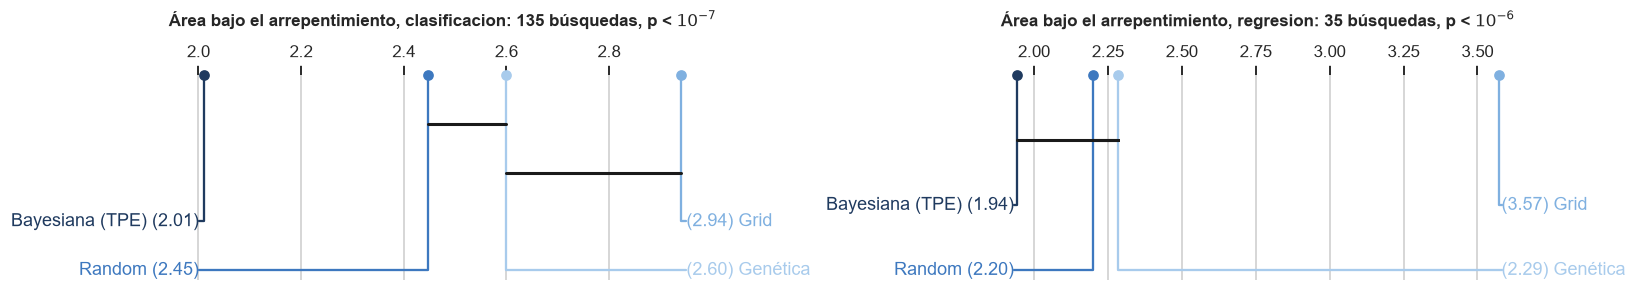

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(15, 2.8))
for a, (t, r) in zip(ax, friedman_area.items()):
    graficos.diagrama_cd(r, ax=a, etiquetas=graficos.NOMBRE_OPTIMIZADOR,
                         titulo=f'Área bajo el arrepentimiento, {t}: {r["n_bloques"]} búsquedas, {p_valor(r["p"], grafico=True)}')
plt.tight_layout()
plt.show()

In [44]:
fa_c, fa_r = friedman_area['clasificacion'], friedman_area['regresion']
pn_c = fa_c['p_nemenyi']
e_c = eficiencia.loc['clasificacion']
e_r = eficiencia.loc['regresion']
display(Markdown(f"""
Aquí sí hay un ganador claro. La **optimización bayesiana** es el método más eficiente por unidad de
presupuesto en las dos tareas: tiene el menor rango medio del área bajo el arrepentimiento
({dec(fa_c['rangos_medios']['bayesiana'], 2)} en clasificación y {dec(fa_r['rangos_medios']['bayesiana'], 2)} en
regresión; Friedman {p_valor(fa_c['p'])} y {p_valor(fa_r['p'])}). En clasificación cierra el 95 % de la
brecha en {dec(e_c.loc['bayesiana', 'evaluaciones hasta el 95 %'], 1)} evaluaciones de media, frente a
{dec(e_c.loc['grid', 'evaluaciones hasta el 95 %'], 1)} de Grid, y Nemenyi la separa de Grid
({p_valor(pn_c.loc['bayesiana', 'grid'])}), de Random ({p_valor(pn_c.loc['bayesiana', 'random'])}) y de la
genética ({p_valor(pn_c.loc['bayesiana', 'genetica'])}).

La **genética** es más eficiente que Grid en regresión (Nemenyi {p_valor(fa_r['p_nemenyi'].loc['genetica', 'grid'])})
pero no en clasificación ({p_valor(pn_c.loc['genetica', 'grid'])}): su población inicial es aleatoria y
necesita varias generaciones para concentrarse, y con presupuestos de 30 a 48 evaluaciones solo
alcanza 5 a 7 generaciones. A cambio, es la que termina con mejor rango en la métrica externa de
clasificación: explora más y, cuando el presupuesto se agota, sus mejores configuraciones
generalizan igual o mejor que las de Grid.

**Random** arranca rápido (las primeras evaluaciones ya cubren el espacio entero), pero solo
{pct(e_c.loc['random', 'búsquedas que llegan al 95 %'], 0)} de sus búsquedas de clasificación llegan a cerrar el 95 % de la
brecha y termina con el mayor arrepentimiento final ({dec(e_c.loc['random', 'arrepentimiento final'], 3)}).
**Grid** es el menos eficiente: recorre la rejilla en un orden fijo que no aprende de lo evaluado.
"""))


Aquí sí hay un ganador claro. La **optimización bayesiana** es el método más eficiente por unidad de
presupuesto en las dos tareas: tiene el menor rango medio del área bajo el arrepentimiento
(2,01 en clasificación y 1,94 en
regresión; Friedman p < 10⁻⁷ y p < 10⁻⁶). En clasificación cierra el 95 % de la
brecha en 10,3 evaluaciones de media, frente a
14,2 de Grid, y Nemenyi la separa de Grid
(p < 10⁻⁷), de Random (p = 0,028) y de la
genética (p = 0,001).

La **genética** es más eficiente que Grid en regresión (Nemenyi p < 0,001)
pero no en clasificación (p = 0,132): su población inicial es aleatoria y
necesita varias generaciones para concentrarse, y con presupuestos de 30 a 48 evaluaciones solo
alcanza 5 a 7 generaciones. A cambio, es la que termina con mejor rango en la métrica externa de
clasificación: explora más y, cuando el presupuesto se agota, sus mejores configuraciones
generalizan igual o mejor que las de Grid.

**Random** arranca rápido (las primeras evaluaciones ya cubren el espacio entero), pero solo
50 % de sus búsquedas de clasificación llegan a cerrar el 95 % de la
brecha y termina con el mayor arrepentimiento final (0,120).
**Grid** es el menos eficiente: recorre la rejilla en un orden fijo que no aprende de lo evaluado.


## Dentro de la optimización bayesiana: arranque aleatorio y explotación del modelo

TPE empieza con un tercio del presupuesto (como máximo 10 ensayos) de puntos aleatorios para
estimar sus dos densidades, ℓ(x) de las configuraciones buenas y g(x) de las malas, y a partir de
ahí propone el punto que maximiza ℓ(x)/g(x), que equivale a maximizar la mejora esperada. Si el
modelo aprende algo útil, los ensayos posteriores al arranque deben puntuar mejor que los del
arranque.

In [45]:
filas = []
for _, f in ok[ok['optimizador'] == 'bayesiana'].iterrows():
    for d in f['detalles']:
        h = np.asarray(d['historial'], dtype=float)
        k = d['n_startup_trials']
        h = h[np.isfinite(h)]
        if len(h) <= k:
            continue
        corte = np.quantile(h, 0.75)
        filas.append({'tarea': f['tarea'], 'modelo': f['modelo'],
                      'arranque en el cuartil superior': np.mean(h[:k] >= corte),
                      'guiados en el cuartil superior': np.mean(h[k:] >= corte),
                      'mediana arranque': np.median(h[:k]), 'mediana guiados': np.median(h[k:])})
tpe = pd.DataFrame(filas)
tpe_resumen = tpe.groupby('tarea')[['arranque en el cuartil superior', 'guiados en el cuartil superior']].mean()
tpe_resumen

,arranque en el cuartil superior,guiados en el cuartil superior
tarea,,
clasificacion,0.0533,0.3486
regresion,0.1000,0.3274


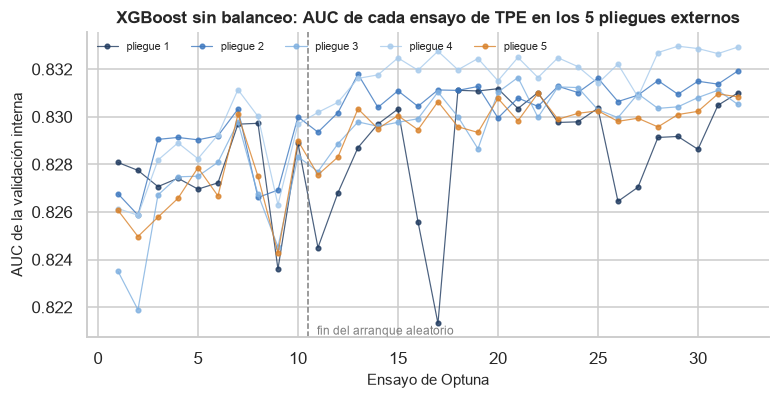

In [46]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ejemplo = ok[(ok['optimizador'] == 'bayesiana') & (ok['modelo'] == 'xgboost') & (ok['tarea'] == 'clasificacion')
             & (ok['balanceo'] == 'ninguno')].iloc[0]
for i, d in enumerate(ejemplo['detalles']):
    h = np.asarray(d['historial'], dtype=float)
    ax.plot(np.arange(1, len(h) + 1), h, marker='o', ms=3, lw=0.8, alpha=0.8, label=f'pliegue {i + 1}')
ax.axvline(ejemplo['detalles'][0]['n_startup_trials'] + 0.5, color='grey', ls='--', lw=1)
ax.text(ejemplo['detalles'][0]['n_startup_trials'] + 0.8, ax.get_ylim()[0], ' fin del arranque aleatorio',
        va='bottom', fontsize=8, color='grey')
ax.set_xlabel('Ensayo de Optuna')
ax.set_ylabel('AUC de la validación interna')
ax.set_title('XGBoost sin balanceo: AUC de cada ensayo de TPE en los 5 pliegues externos')
ax.legend(frameon=False, fontsize=7, ncol=5)
plt.show()

In [47]:
tc = tpe_resumen.loc['clasificacion']
display(Markdown(f"""
En clasificación, {pct(tc['guiados en el cuartil superior'], 0)} de los ensayos que propone TPE después del
arranque caen en el cuartil superior de su propio estudio, frente a {pct(tc['arranque en el cuartil superior'], 0)}
de los ensayos aleatorios del arranque. Si el modelo no aprendiera nada, las dos cifras serían
parecidas: el sustituto concentra la búsqueda en la región buena, que es la fuente de la ventaja
*anytime* de la sección anterior.
"""))


En clasificación, 35 % de los ensayos que propone TPE después del
arranque caen en el cuartil superior de su propio estudio, frente a 5 %
de los ensayos aleatorios del arranque. Si el modelo no aprendiera nada, las dos cifras serían
parecidas: el sustituto concentra la búsqueda en la región buena, que es la fuente de la ventaja
*anytime* de la sección anterior.


## Dentro del algoritmo genético: diversidad y convergencia

El genético usa selección por torneo de tamaño 3, cruce uniforme (probabilidad de intercambio 0,5
por gen, aplicado con probabilidad 0,6), mutación gaussiana con desviación 0,15 sobre genes
codificados en [0, 1] (probabilidad 1/n por gen, aplicada con probabilidad 0,3) y elitismo: el
mejor individuo se reinserta en cada generación. La población y el número de generaciones se
derivan del presupuesto (con 30 evaluaciones, 7 individuos y 6 generaciones), y una caché de
genomas evita gastar presupuesto en configuraciones repetidas. La guía pide registrar la
diversidad por generación: aquí es la desviación típica de cada gen (codificado en [0, 1]) a través
de la población, promediada sobre los genes; vale 0 cuando todos los individuos son idénticos.

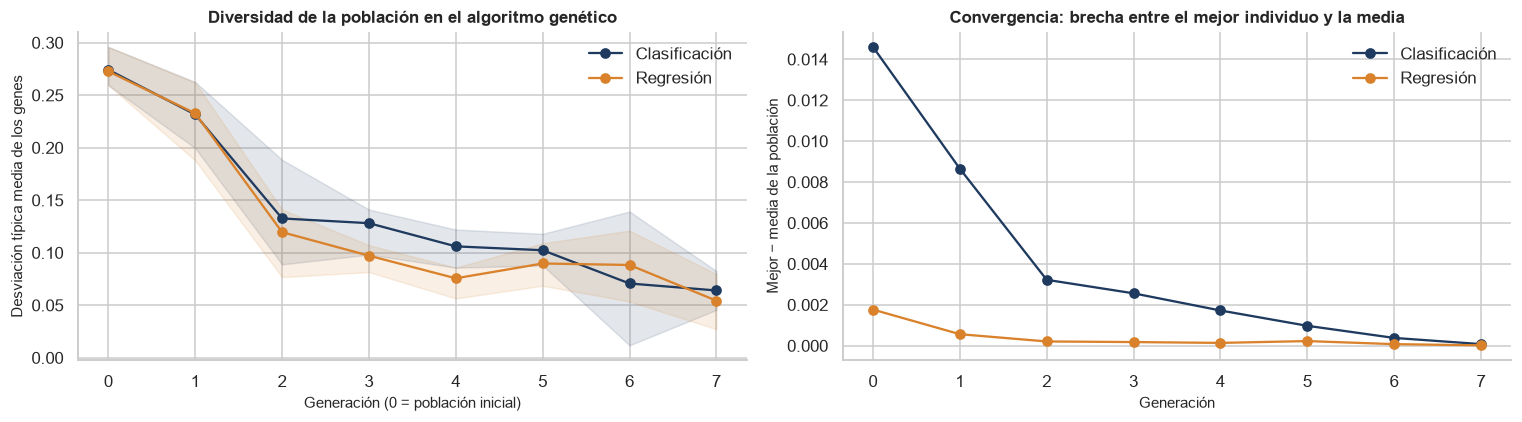


La diversidad cae de 0,274 en la población inicial a 0,078 en la última generación:
la población converge hacia la región de las mejores configuraciones sin colapsar del todo, porque la
mutación sigue introduciendo variación. La brecha entre el mejor individuo y la media se cierra al
mismo ritmo, señal de que el elitismo y el torneo están arrastrando a toda la población, no solo
conservando al mejor.


In [48]:
div = analisis.diversidad_genetica(tabla)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
graficos.diversidad_genetica(div, ax=ax[0])
conv = div.groupby(['tarea', 'generacion'])[['mejor', 'media']].mean()
for t, color in (('clasificacion', graficos.AZUL), ('regresion', '#d9822b')):
    g = div[div['tarea'] == t].copy()
    g['brecha'] = g['mejor'] - g['media']
    b = g.groupby('generacion')['brecha'].mean()
    ax[1].plot(b.index, b.values, marker='o', color=color, label=graficos.NOMBRE_TAREA[t])
ax[1].set_xlabel('Generación')
ax[1].set_ylabel('Mejor − media de la población')
ax[1].set_title('Convergencia: brecha entre el mejor individuo y la media')
ax[1].legend(frameon=False)
plt.tight_layout()
plt.show()
d_ini = div[div['generacion'] == 0]['diversidad'].mean()
d_fin = div.groupby(['tarea', 'modelo', 'balanceo', 'pliegue'])['diversidad'].last().mean()
display(Markdown(f"""
La diversidad cae de {dec(d_ini, 3)} en la población inicial a {dec(d_fin, 3)} en la última generación:
la población converge hacia la región de las mejores configuraciones sin colapsar del todo, porque la
mutación sigue introduciendo variación. La brecha entre el mejor individuo y la media se cierra al
mismo ritmo, señal de que el elitismo y el torneo están arrastrando a toda la población, no solo
conservando al mejor.
"""))

## Optimismo de selección

El mejor puntaje de la validación interna es una estimación sesgada al alza, porque es el máximo de
muchas evaluaciones ruidosas; por eso la guía obliga a reportar la métrica del bucle externo. La
diferencia entre ambos mide ese sesgo.

In [49]:
opt = ok.groupby(['tarea', 'optimizador'])['optimismo_seleccion'].agg(['mean', 'min', 'max']).reindex(
    analisis.OPTIMIZADORES, level='optimizador')
opt

mean     min     max
tarea         optimizador                        
clasificacion grid        -0.0013 -0.0084  0.0022
              random      -0.0009 -0.0084  0.0025
              bayesiana   -0.0010 -0.0084  0.0023
              genetica    -0.0012 -0.0084  0.0027
regresion     grid        -0.0001 -0.0003 -0.0000
              random      -0.0001 -0.0002 -0.0000
              bayesiana   -0.0001 -0.0002 -0.0000
              genetica    -0.0001 -0.0002 -0.0000

In [50]:
oc = ok[ok['tarea'] == 'clasificacion']['optimismo_seleccion']
media_opt = opt.loc['clasificacion', 'mean']
adaptativos_mas_optimistas = max(media_opt['bayesiana'], media_opt['genetica']) > media_opt['grid'] + 0.0005
n_train = int(ok['n_train'].iloc[0])
display(Markdown(f"""
El optimismo sale **{'negativo' if oc.mean() < 0 else 'positivo'}** en promedio (media {dec(oc.mean(), 4, True)} de AUC
en clasificación){': la validación interna *subestima* el desempeño externo' if oc.mean() < 0 else ''}. Hay dos
fuerzas opuestas. El máximo de 30 a 48 evaluaciones sesga al alza, pero cada modelo interno se
entrena con dos tercios del pliegue externo (unas {ent(n_train * 4 / 5 * 2 / 3)} filas) y el del bucle
externo con el pliegue completo (unas {ent(n_train * 4 / 5)}): con curvas de aprendizaje que todavía
suben, el efecto del tamaño {'domina' if oc.mean() < 0 else 'no alcanza a compensar el de la selección'}.
{'Los métodos adaptativos, que buscan el máximo con más insistencia, muestran más optimismo que Grid ('
 + dec(media_opt['bayesiana'], 4, True) + ' la bayesiana y ' + dec(media_opt['genetica'], 4, True) + ' la genética, frente a '
 + dec(media_opt['grid'], 4, True) + ').' if adaptativos_mas_optimistas else
 'Los métodos adaptativos, que buscan el máximo con más insistencia, no muestran más optimismo que Grid ('
 + dec(media_opt['bayesiana'], 4, True) + ' la bayesiana y ' + dec(media_opt['genetica'], 4, True) + ' la genética, frente a '
 + dec(media_opt['grid'], 4, True) + '): su mejor puntaje interno no está sobreajustado a los pliegues internos.'}
"""))


El optimismo sale **negativo** en promedio (media −0,0011 de AUC
en clasificación): la validación interna *subestima* el desempeño externo. Hay dos
fuerzas opuestas. El máximo de 30 a 48 evaluaciones sesga al alza, pero cada modelo interno se
entrena con dos tercios del pliegue externo (unas 20.788 filas) y el del bucle
externo con el pliegue completo (unas 31.182): con curvas de aprendizaje que todavía
suben, el efecto del tamaño domina.
Los métodos adaptativos, que buscan el máximo con más insistencia, no muestran más optimismo que Grid (−0,0010 la bayesiana y −0,0012 la genética, frente a −0,0013): su mejor puntaje interno no está sobreajustado a los pliegues internos.


## Conclusión

In [51]:
display(Markdown(f"""
- Con el mismo número de evaluaciones, **la optimización bayesiana es la que mejor aprovecha el
  presupuesto**: llega antes al nivel final en las dos tareas, con diferencias significativas frente
  a Grid y Random. Es la respuesta cuantitativa que pide la guía.
- **La métrica final apenas distingue a los métodos.** Bayesiana, genética y Grid terminan dentro
  de una fracción de milésima de AUC; solo Random queda por debajo de forma consistente. Con
  espacios de 1 a 7 hiperparámetros y 30 a 48 evaluaciones, el presupuesto alcanza para que los
  métodos sistemáticos encuentren la meseta del óptimo.
- **En tiempo de reloj la ventaja se invierte**: la bayesiana y la genética son secuenciales y
  tardaron {dec(ratio_t['clasificacion'], 1)} veces más por evaluación en este equipo de 6 núcleos. Con más
  núcleos, o con evaluaciones caras que ya usan todos los núcleos por sí mismas (Random Forest,
  la EBM), la ventaja por evaluación se convierte en ventaja de tiempo.
- La multi-fidelidad aplicada a Random Forest (100 árboles en la búsqueda y 300 en el modelo final)
  y a la EBM (2 y 8 bolsas) se valida en la sección de cómputo.
"""))


- Con el mismo número de evaluaciones, **la optimización bayesiana es la que mejor aprovecha el
  presupuesto**: llega antes al nivel final en las dos tareas, con diferencias significativas frente
  a Grid y Random. Es la respuesta cuantitativa que pide la guía.
- **La métrica final apenas distingue a los métodos.** Bayesiana, genética y Grid terminan dentro
  de una fracción de milésima de AUC; solo Random queda por debajo de forma consistente. Con
  espacios de 1 a 7 hiperparámetros y 30 a 48 evaluaciones, el presupuesto alcanza para que los
  métodos sistemáticos encuentren la meseta del óptimo.
- **En tiempo de reloj la ventaja se invierte**: la bayesiana y la genética son secuenciales y
  tardaron 1,7 veces más por evaluación en este equipo de 6 núcleos. Con más
  núcleos, o con evaluaciones caras que ya usan todos los núcleos por sí mismas (Random Forest,
  la EBM), la ventaja por evaluación se convierte en ventaja de tiempo.
- La multi-fidelidad aplicada a Random Forest (100 árboles en la búsqueda y 300 en el modelo final)
  y a la EBM (2 y 8 bolsas) se valida en la sección de cómputo.


# Optimización computacional

La guía (§4) pide analizar la complejidad de entrenamiento e inferencia de cada modelo y
contrastarla con tiempos medidos, probar variantes más eficientes de cada uno, estudiar la
paralelización, perfilar el código y resumirlo todo en una tabla de versión estándar frente a
versión optimizada. Los experimentos están en `computo.py`. Se ejecutan con los hiperparámetros
finales de la mejor combinación de cada modelo, sobre el entrenamiento completo, y miden con
tiempos de reloj la mediana de varias repeticiones. Para que esos tiempos sean válidos, el guion
espera a que el equipo no esté corriendo ningún otro experimento.

In [52]:
import json
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

from src import graficos, modelos
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
CARPETA = RAIZ / 'resultados' / 'computo'


def leer(nombre):
    ruta = CARPETA / f'{nombre}.csv'
    if not ruta.exists():
        display(Markdown(f'*Resultado pendiente: `{nombre}` todavía no se ha medido (lo produce `computo.py`).*'))
        return None
    return pd.read_csv(ruta)


if (CARPETA / 'equipo.json').exists():
    equipo = json.loads((CARPETA / 'equipo.json').read_text(encoding='utf-8'))
    display(pd.Series(equipo).to_frame('equipo de medición'))

,equipo de medición
procesador,"AMD64 Family 23 Model 113 Stepping 0, Authenti..."
nucleos_logicos,6
nucleos_fisicos,6
memoria_gb,15.9000
sistema,Windows-11-10.0.26200-SP0
python,3.13.3
gpu,"NVIDIA GeForce RTX 3050, 6144 MiB"


## 1. Complejidad teórica frente a tiempos medidos

Si el tiempo de entrenamiento crece como O(<i>n</i><sup><i>a</i></sup>), en escala log-log es una recta de pendiente *a*.
Se entrena cada modelo con 2.500 a 38.978 clientes y se estima la pendiente con los tamaños
mayores, donde los costes fijos ya no dominan. La inferencia se mide siempre sobre los 9.745 clientes
de prueba.

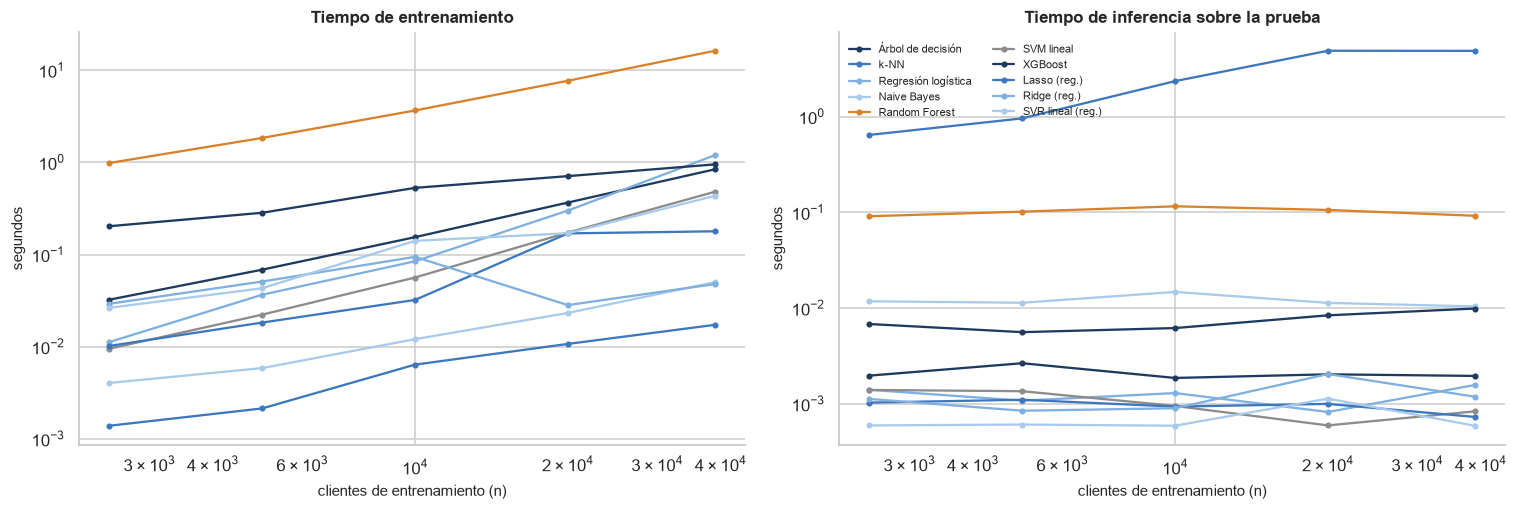

complejidad de entrenamiento  \
tarea         modelo                                                                   
clasificacion Árbol de decisión                                         O(n·p·log n)   
              k-NN                      O(1) fuerza bruta; O(n·p·log n) KD/Ball Tree   
              Regresión logística                O(k·n·p) (liblinear, k iteraciones)   
              Naive Bayes                                                     O(n·p)   
              Random Forest                                           O(T·n·p·log n)   
              SVM lineal                   O(k·n·p) lineal; O(n²·p)–O(n³) con núcleo   
              XGBoost              O(T·d·(n·p + bins·p)) con hist; O(T·d·n·p·log ...   
regresion     Lasso                                O(k·n·p) descenso por coordenadas   
              Ridge                             O(n·p² + p³) cholesky; O(k·n·p) SAGA   
              SVR lineal                   O(k·n·p) lineal; O(n²·p)–O(n³) con núcleo   

                                   pendiente medida (entrenamiento)  \
tarea         modelo                                                  
clasificacion Árbol de decisión                              1.2240   
              k-NN                                           0.9910   
              Regresión logística                            1.7095   
              Naive Bayes                                    1.0355   
              Random Forest                                  1.0616   
              SVM lineal                                     1.5078   
              XGBoost                                        0.5726   
regresion     Lasso                                          1.2435   
              Ridge                                         -0.2050   
              SVR lineal                                     1.0386   

                                                           complejidad de inferencia  \
tarea         modelo                                                                   
clasificacion Árbol de decisión                                    O(d) por consulta   
              k-NN                 O(n·p) por consulta en fuerza bruta; O(p·log n...   
              Regresión logística                                               O(p)   
              Naive Bayes                                   O(p·clases) por consulta   
              Random Forest                                      O(T·d) por consulta   
              SVM lineal                              O(p) lineal; O(s·p) con núcleo   
              XGBoost                                            O(T·d) por consulta   
regresion     Lasso                                                             O(p)   
              Ridge                                                             O(p)   
              SVR lineal                              O(p) lineal; O(s·p) con núcleo   

                                   pendiente medida (inferencia frente al n de entrenamiento)  \
tarea         modelo                                                                            
clasificacion Árbol de decisión                                              -0.1215            
              k-NN                                                            0.8203            
              Regresión logística                                             0.0970            
              Naive Bayes                                                    -0.0766            
              Random Forest                                                  -0.0553            
              SVM lineal                                                     -0.2828            
              XGBoost                                                         0.2936            
regresion     Lasso                                                          -0.1708            
              Ridge                                                           0.2702            
              SVR line

In [53]:
esc = leer('escalamiento')
if esc is not None:
    teoria = {('clasificacion', m): s.complejidad for m, s in modelos.catalogo('clasificacion').items()}
    teoria |= {('regresion', m): s.complejidad for m, s in modelos.catalogo('regresion').items()}
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
    filas = []
    for (tarea, m), g in esc.groupby(['tarea', 'modelo']):
        g = g.sort_values('n')
        etiqueta = f'{NOMBRES_MODELO[m]}{" (reg.)" if tarea == "regresion" else ""}'
        ax[0].plot(g['n'], g['entrenamiento_s'], marker='o', ms=3, label=etiqueta)
        ax[1].plot(g['n'], g['inferencia_s'], marker='o', ms=3, label=etiqueta)
        grandes = g[g['n'] >= g['n'].max() / 8]
        pendiente = np.polyfit(np.log(grandes['n']), np.log(grandes['entrenamiento_s']), 1)[0] if len(grandes) >= 2 else np.nan
        pend_inf = np.polyfit(np.log(grandes['n']), np.log(grandes['inferencia_s']), 1)[0] if len(grandes) >= 2 else np.nan
        ultimo = g.iloc[-1]
        filas.append({'tarea': tarea, 'modelo': NOMBRES_MODELO[m],
                      'complejidad de entrenamiento': teoria[(tarea, m)].get('entrenamiento', ''),
                      'pendiente medida (entrenamiento)': pendiente,
                      'complejidad de inferencia': teoria[(tarea, m)].get('inferencia', ''),
                      'pendiente medida (inferencia frente al n de entrenamiento)': pend_inf,
                      'entrenamiento con todo (s)': ultimo['entrenamiento_s'],
                      'inferencia de la prueba (s)': ultimo['inferencia_s'],
                      'memoria pico (MB)': ultimo.get('memoria_mb'), 'tamaño del modelo (MB)': ultimo.get('tamano_modelo_mb')})
    for a, t in zip(ax, ('entrenamiento', 'inferencia sobre la prueba')):
        a.set_xscale('log')
        a.set_yscale('log')
        a.set_xlabel('clientes de entrenamiento (n)')
        a.set_ylabel('segundos')
        a.set_title(f'Tiempo de {t}')
    ax[1].legend(frameon=False, fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()
    complejidad = pd.DataFrame(filas).set_index(['tarea', 'modelo'])
    display(complejidad)

In [54]:
if esc is not None:
    c = complejidad.xs('clasificacion')
    pend = complejidad['pendiente medida (entrenamiento)'].droplevel(0)
    pend = pend[~pend.index.duplicated()]
    casi_lineal = pend[(pend > 0.85) & (pend < 1.3)]
    rapido = pend[pend >= 1.3]
    lento = pend[pend <= 0.85]
    inf = complejidad['inferencia de la prueba (s)']
    ent_ = complejidad['entrenamiento con todo (s)']
    mem = complejidad['memoria pico (MB)']
    tam = complejidad['tamaño del modelo (MB)']
    lista = lambda s: enumerar(f"{m} ({dec(v, 2)})" for m, v in s.sort_values().items())
    display(Markdown(f"""
Crecen de forma casi lineal en n, como predicen O(n·p) y O(n·p·log n), {lista(casi_lineal)}. Crecen más
deprisa {lista(rapido)}: resuelven problemas iterativos (liblinear) que necesitan más iteraciones
cuanto más datos ven, de modo que el coste real es O(k·n·p) con un k que
también crece. Crecen más despacio {lista(lento)}: Ridge resuelve un sistema de 78 × 78 (el término p³ es
despreciable) y tarda milisegundos, así que la medición la dominan costes fijos; XGBoost con `hist`
reparte la construcción de histogramas entre 6 hilos y amortiza mejor el coste fijo de cada árbol cuando
hay más filas. La inferencia es casi instantánea en todos salvo k-NN, que «entrena» solo guardando los datos
y traslada el coste a la consulta: tarda {dec(inf.max(), 2)} s en puntuar la prueba, con una
pendiente de {dec(c.loc['k-NN', 'pendiente medida (inferencia frente al n de entrenamiento)'], 2)} frente al número de clientes guardados, como
corresponde a O(n·m·p). El más caro de entrenar es {ent_.idxmax()[1]} ({dec(ent_.max(), 1)} s){', que es también el más pesado en memoria (' + dec(mem.max(), 0) + ' MB de pico) y en disco (' + dec(tam.max(), 0) + ' MB serializado), por sus 300 árboles profundos' if mem.idxmax() == ent_.idxmax() == tam.idxmax() else ''}.
"""))


Crecen de forma casi lineal en n, como predicen O(n·p) y O(n·p·log n), k-NN (0,99), Naive Bayes (1,04), SVR lineal (1,04), Random Forest (1,06), Árbol de decisión (1,22) y Lasso (1,24). Crecen más
deprisa SVM lineal (1,51) y Regresión logística (1,71): resuelven problemas iterativos (liblinear) que necesitan más iteraciones
cuanto más datos ven, de modo que el coste real es O(k·n·p) con un k que
también crece. Crecen más despacio Ridge (−0,21) y XGBoost (0,57): Ridge resuelve un sistema de 78 × 78 (el término p³ es
despreciable) y tarda milisegundos, así que la medición la dominan costes fijos; XGBoost con `hist`
reparte la construcción de histogramas entre 6 hilos y amortiza mejor el coste fijo de cada árbol cuando
hay más filas. La inferencia es casi instantánea en todos salvo k-NN, que «entrena» solo guardando los datos
y traslada el coste a la consulta: tarda 4,87 s en puntuar la prueba, con una
pendiente de 0,82 frente al número de clientes guardados, como
corresponde a O(n·m·p). El más caro de entrenar es Random Forest (16,3 s), que es también el más pesado en memoria (68 MB de pico) y en disco (44 MB serializado), por sus 300 árboles profundos.


## 2. k-NN: árboles de búsqueda y FAISS

In [55]:
knn = leer('knn')
if knn is not None:
    display(knn.set_index(['dimension', 'metodo']).drop(columns=['k', 'pesos', 'p']))
    k78 = knn[knn['dimension'] == '78 variables'].set_index('metodo')
    k4 = knn[knn['dimension'] == '4 variables con señal'].set_index('metodo')
    base = 'scikit-learn brute'
    hnsw = [m for m in k78.index if 'HNSW' in m][0]
    display(Markdown(f"""
Con {knn['k'].iloc[0]} vecinos y distancia {'Manhattan' if knn['p'].iloc[0] == 1 else 'euclídea'} (los hiperparámetros finales):

- En las **78 dimensiones** del problema, KD-Tree y Ball Tree son {dec(k78.loc['scikit-learn kd_tree', 'consulta_s'] / k78.loc[base, 'consulta_s'], 1)} y
  {dec(k78.loc['scikit-learn ball_tree', 'consulta_s'] / k78.loc[base, 'consulta_s'], 1)} veces **más lentos** que la fuerza bruta
  ({dec(k78.loc[base, 'consulta_s'], 2)} s). Es la maldición de la dimensión: con tantas variables, un árbol casi
  nunca puede descartar regiones enteras y acaba visitando casi todos los puntos, con el sobrecoste de recorrerse.
- FAISS **tampoco acelera** en este caso: su índice exacto tarda {dec(k78.loc['FAISS IndexFlat (exacto)', 'consulta_s'], 2)} s,
  porque sus rutinas rápidas (multiplicación de matrices con BLAS) son para la distancia euclídea y el producto
  interno, y la Manhattan cae en una implementación genérica. El índice aproximado HNSW obtiene
  prácticamente el mismo AUC ({dec(k78.loc[hnsw, 'auc'], 4)} frente a {dec(k78.loc[base, 'auc'], 4)}) pero tampoco gana tiempo
  ({dec(k78.loc[hnsw, 'consulta_s'], 2)} s): para devolver {knn['k'].iloc[0]} vecinos tiene que explorar al menos otros tantos
  candidatos por consulta, y su ventaja, que es visitar muy pocos, desaparece.
- Con las **4 variables con señal** el orden se invierte: KD-Tree es el más rápido
  ({dec(k4.loc['scikit-learn kd_tree', 'consulta_s'], 2)} s frente a {dec(k4.loc[base, 'consulta_s'], 2)} s de la fuerza bruta), como predice su
  coste de O(log n) por consulta en baja dimensión, y el AUC sube a {dec(k4.loc[base, 'auc'], 4)}: quitar las 74 columnas
  de ruido mejora a la vez la velocidad y la calidad de k-NN, que es lo que la Entrega 2 no hizo.
"""))

ke = leer('knn_euclidea')
if ke is not None:
    display(ke.set_index(['k', 'metodo']))
    filas_e = []
    for k_, g in ke.groupby('k'):
        g = g.set_index('metodo')
        h = [m for m in g.index if 'HNSW' in m][0]
        t_sk, t_fx, t_h = g.loc['scikit-learn brute', 'consulta_s'], g.loc['FAISS IndexFlatL2 (exacto)', 'consulta_s'], g.loc[h, 'consulta_s']
        exacto = (f"el índice exacto de FAISS tarda {dec(t_fx, 2)} s frente a {dec(t_sk, 2)} s de scikit-learn"
                  + (' (algo más: los dos usan multiplicación de matrices con BLAS)' if t_fx >= t_sk else f' ({dec(t_sk / t_fx, 1)} veces más rápido)'))
        aprox = (f"HNSW consulta en {dec(t_h, 2)} s, {dec(t_sk / t_h, 1)} veces más rápido que scikit-learn, recuperando el {pct(g.loc[h, 'exhaustividad'], 1)} de los vecinos exactos"
                 if t_h < 0.9 * t_sk else f"HNSW ya no gana tiempo ({dec(t_h, 2)} s) aunque recupera el {pct(g.loc[h, 'exhaustividad'], 1)} de los vecinos exactos")
        filas_e.append(f"con k = {k_}, {exacto}, y {aprox}")
    display(Markdown(f"""
**Distancia euclídea.** Se repitió la comparación con la distancia euclídea, para la que FAISS está
optimizado: {'; '.join(filas_e)}. La búsqueda exacta no mejora a scikit-learn, que ya es eficiente en
este tamaño; la aproximada (HNSW) sí acelera cuando se piden pocos vecinos, a cambio de perder una
fracción mínima de ellos, y pierde su ventaja a medida que crece k, porque tiene que explorar al menos k
candidatos por consulta. Con el k-NN óptimo de este problema (600 vecinos y distancia Manhattan), la
fuerza bruta de scikit-learn es la mejor opción, y la optimización que de verdad compensa es reducir las
variables.
"""))

exacto  construccion_s  \
dimension             metodo                                                  
78 variables          scikit-learn brute               True          0.0033   
                      scikit-learn kd_tree             True          0.6638   
                      scikit-learn ball_tree           True          0.4045   
                      FAISS IndexFlat (exacto)         True          0.0106   
                      FAISS HNSW (aproximado, M=32)   False          2.6646   
4 variables con señal scikit-learn brute               True          0.0019   
                      scikit-learn kd_tree             True          0.0407   
                      scikit-learn ball_tree           True          0.0337   
                      FAISS IndexFlat (exacto)         True          0.0001   
                      FAISS HNSW (aproximado, M=32)   False          0.9234   

                                                     consulta_s    auc  \
dimension             metodo                                             
78 variables          scikit-learn brute                 8.0370 0.7874   
                      scikit-learn kd_tree              24.0691 0.7874   
                      scikit-learn ball_tree            24.2643 0.7874   
                      FAISS IndexFlat (exacto)          11.9519 0.7874   
                      FAISS HNSW (aproximado, M=32)     11.4479 0.7873   
4 variables con señal scikit-learn brute                 2.5011 0.8212   
                      scikit-learn kd_tree               1.8495 0.8212   
                      scikit-learn ball_tree             3.0975 0.8212   
                      FAISS IndexFlat (exacto)           1.9340 0.8212   
                      FAISS HNSW (aproximado, M=32)      8.3182 0.8212   

                                                     indice_mb  
dimension             metodo                                    
78 variables          scikit-learn brute               11.8958  
                      scikit-learn kd_tree             37.8880  
                      scikit-learn ball_tree           36.6699  
                      FAISS IndexFlat (exacto)         11.5978  
                      FAISS HNSW (aproximado, M=32)    21.7169  
4 variables con señal scikit-learn brute                0.8928  
                      scikit-learn kd_tree              2.5676  
                      scikit-learn ball_tree            2.5052  
                      FAISS IndexFlat (exacto)          0.5948  
                      FAISS HNSW (aproximado, M=32)    10.7139


Con 600 vecinos y distancia Manhattan (los hiperparámetros finales):

- En las **78 dimensiones** del problema, KD-Tree y Ball Tree son 3,0 y
  3,0 veces **más lentos** que la fuerza bruta
  (8,04 s). Es la maldición de la dimensión: con tantas variables, un árbol casi
  nunca puede descartar regiones enteras y acaba visitando casi todos los puntos, con el sobrecoste de recorrerse.
- FAISS **tampoco acelera** en este caso: su índice exacto tarda 11,95 s,
  porque sus rutinas rápidas (multiplicación de matrices con BLAS) son para la distancia euclídea y el producto
  interno, y la Manhattan cae en una implementación genérica. El índice aproximado HNSW obtiene
  prácticamente el mismo AUC (0,7873 frente a 0,7874) pero tampoco gana tiempo
  (11,45 s): para devolver 600 vecinos tiene que explorar al menos otros tantos
  candidatos por consulta, y su ventaja, que es visitar muy pocos, desaparece.
- Con las **4 variables con señal** el orden se invierte: KD-Tree es el más rápido
  (1,85 s frente a 2,50 s de la fuerza bruta), como predice su
  coste de O(log n) por consulta en baja dimensión, y el AUC sube a 0,8212: quitar las 74 columnas
  de ruido mejora a la vez la velocidad y la calidad de k-NN, que es lo que la Entrega 2 no hizo.


construccion_s  consulta_s  exhaustividad
k   metodo                                                                  
10  scikit-learn brute                     0.0000      0.6467         1.0000
    FAISS IndexFlatL2 (exacto)             0.0126      0.7443         1.0000
    FAISS HNSW (aproximado, M=32)          1.0144      0.2362         0.9943
100 scikit-learn brute                     0.0000      0.6894         1.0000
    FAISS IndexFlatL2 (exacto)             0.0035      0.9262         1.0000
    FAISS HNSW (aproximado, M=32)          0.7802      0.7184         0.9972


**Distancia euclídea.** Se repitió la comparación con la distancia euclídea, para la que FAISS está
optimizado: con k = 10, el índice exacto de FAISS tarda 0,74 s frente a 0,65 s de scikit-learn (algo más: los dos usan multiplicación de matrices con BLAS), y HNSW consulta en 0,24 s, 2,7 veces más rápido que scikit-learn, recuperando el 99,4 % de los vecinos exactos; con k = 100, el índice exacto de FAISS tarda 0,93 s frente a 0,69 s de scikit-learn (algo más: los dos usan multiplicación de matrices con BLAS), y HNSW ya no gana tiempo (0,72 s) aunque recupera el 99,7 % de los vecinos exactos. La búsqueda exacta no mejora a scikit-learn, que ya es eficiente en
este tamaño; la aproximada (HNSW) sí acelera cuando se piden pocos vecinos, a cambio de perder una
fracción mínima de ellos, y pierde su ventaja a medida que crece k, porque tiene que explorar al menos k
candidatos por consulta. Con el k-NN óptimo de este problema (600 vecinos y distancia Manhattan), la
fuerza bruta de scikit-learn es la mejor opción, y la optimización que de verdad compensa es reducir las
variables.


## 3. Solucionadores de los modelos lineales

In [56]:
lin = leer('lineales')
if lin is not None:
    display(lin.set_index(['modelo', 'solucionador']))
    r = lin[lin['modelo'] == 'Ridge'].set_index('solucionador')
    l = lin[lin['modelo'] == 'Lasso'].set_index('solucionador')
    g = lin[lin['modelo'] == 'Logística L1'].set_index('solucionador')
    display(Markdown(f"""
**Ridge.** El problema es pequeño en columnas (p = 78), así que los métodos directos son los más rápidos:
el más veloz fue `{r['entrenamiento_s'].idxmin()}` ({dec(r['entrenamiento_s'].min(), 3)} s), y SAGA, pensado para n y p muy grandes,
tardó {dec(r.loc['saga', 'entrenamiento_s'], 3)} s ({r.loc['saga', 'iteraciones']:.0f} iteraciones) para el mismo RMSE. **Lasso.** El
descenso por coordenadas ({dec(l.loc['descenso por coordenadas', 'entrenamiento_s'], 3)} s) supera al SGD con penalización L1
({dec(l.loc['SGD con penalización L1', 'entrenamiento_s'], 3)} s), que además converge a un RMSE algo peor. **Logística L1.**
liblinear ({dec(g.loc['liblinear', 'entrenamiento_s'], 3)} s) frente a SAGA ({dec(g.loc['saga', 'entrenamiento_s'], 3)} s), con el mismo AUC. Con
39.000 filas y 78 columnas, los solucionadores estocásticos no compensan: su ventaja aparece cuando los
datos no caben en memoria o p es muy grande.
"""))

entrenamiento_s  iteraciones metrica  \
modelo       solucionador                                                     
Ridge        cholesky                           0.0791          NaN    rmse   
             svd                                0.4226          NaN    rmse   
             lsqr                               0.2492      37.0000    rmse   
             sparse_cg                          0.2600          NaN    rmse   
             sag                                8.3779     305.0000    rmse   
             saga                              15.0818     567.0000    rmse   
Lasso        descenso por coordenadas           0.2187      28.0000    rmse   
             SGD con penalización L1            0.8792      35.0000    rmse   
Logística L1 liblinear                          1.2672      21.0000     auc   
             saga                              19.3958     577.0000     auc   

                                       valor  coeficientes_no_nulos  
modelo       solucionador                                            
Ridge        cholesky                 0.0617                    NaN  
             svd                      0.0617                    NaN  
             lsqr                     0.0617                    NaN  
             sparse_cg                0.0617                    NaN  
             sag                      0.0617                    NaN  
             saga                     0.0617                    NaN  
Lasso        descenso por coordenadas 0.0617                39.0000  
             SGD con penalización L1  0.0671                25.0000  
Logística L1 liblinear                0.7710                47.0000  
             saga                     0.7710                47.0000


**Ridge.** El problema es pequeño en columnas (p = 78), así que los métodos directos son los más rápidos:
el más veloz fue `cholesky` (0,079 s), y SAGA, pensado para n y p muy grandes,
tardó 15,082 s (567 iteraciones) para el mismo RMSE. **Lasso.** El
descenso por coordenadas (0,219 s) supera al SGD con penalización L1
(0,879 s), que además converge a un RMSE algo peor. **Logística L1.**
liblinear (1,267 s) frente a SAGA (19,396 s), con el mismo AUC. Con
39.000 filas y 78 columnas, los solucionadores estocásticos no compensan: su ventaja aparece cuando los
datos no caben en memoria o p es muy grande.


## 4. Naive Bayes con `partial_fit`

In [57]:
nb = leer('naive_bayes')
if nb is not None:
    display(nb.set_index('modo'))
    nbi = nb.set_index('modo')
    display(Markdown(f"""
`partial_fit` permite entrenar por lotes sin cargar todo en memoria: las medias y varianzas por clase se
actualizan de forma exacta, y la memoria adicional del ajuste baja de {dec(nbi.iloc[0]['memoria_mb'], 1)} MB con el
ajuste completo a {dec(nbi.iloc[-1]['memoria_mb'], 2)} MB con lotes de 1.000. Las probabilidades, en cambio, no son idénticas:
el suavizado de varianza se calcula con la varianza máxima del **primer** lote, y la diferencia máxima con el
ajuste completo crece al achicar los lotes ({enumerar(f"{dec(v, 3)} con {m.split('lotes de ')[-1]}" for m, v in nbi['max_dif_probabilidad'].iloc[1:].items())}),
aunque el AUC apenas cambia (de {dec(nbi['auc'].min(), 4)} a {dec(nbi['auc'].max(), 4)}). En este conjunto, que cabe en memoria, no hace
falta; la técnica importa para flujos de datos o tablas mayores que la memoria.
"""))

,entrenamiento_s,memoria_mb,auc,max_dif_probabilidad
modo,,,,
fit completo,0.0462,32.9609,0.6662,0.0000
"partial_fit, lotes de 20000",0.0424,11.6758,0.6666,0.0377
"partial_fit, lotes de 5000",0.0384,4.5078,0.6684,0.2677
"partial_fit, lotes de 1000",0.0480,0.0117,0.6703,0.4993



`partial_fit` permite entrenar por lotes sin cargar todo en memoria: las medias y varianzas por clase se
actualizan de forma exacta, y la memoria adicional del ajuste baja de 33,0 MB con el
ajuste completo a 0,01 MB con lotes de 1.000. Las probabilidades, en cambio, no son idénticas:
el suavizado de varianza se calcula con la varianza máxima del **primer** lote, y la diferencia máxima con el
ajuste completo crece al achicar los lotes (0,038 con 20000, 0,268 con 5000 y 0,499 con 1000),
aunque el AUC apenas cambia (de 0,6662 a 0,6703). En este conjunto, que cabe en memoria, no hace
falta; la técnica importa para flujos de datos o tablas mayores que la memoria.


## 5. XGBoost: método de construcción, GPU y *early stopping*

In [58]:
xg = leer('xgboost')
if xg is not None:
    display(xg.set_index(['experimento', 'variante']))
    m = xg[xg['experimento'] == 'método y dispositivo'].set_index('variante')
    t_exact = m.loc[m.index.str.startswith('exact'), 'entrenamiento_s'].iloc[0]
    t_hist = m.loc['hist · cpu · todos los hilos', 'entrenamiento_s']
    t_gpu = m.loc[m.index.str.contains('cuda'), 'entrenamiento_s'].iloc[0]
    t_1 = m.loc['hist · cpu · 1 hilo', 'entrenamiento_s']
    es = xg[xg['experimento'] == 'early stopping'].set_index('variante')
    display(Markdown(f"""
Con los hiperparámetros finales, `hist` (agrupa cada variable en 256 intervalos y busca cortes sobre
histogramas) entrena en {dec(t_hist, 2)} s frente a {dec(t_exact, 2)} s de `exact` (que ordena los valores en cada
nodo): {dec(t_exact / t_hist, 1)} veces más rápido con el mismo AUC. Los 6 hilos aceleran {dec(t_1 / t_hist, 1)} veces frente a uno.
En la GPU RTX 3050 el entrenamiento tarda {dec(t_gpu, 2)} s{(', algo más que en la CPU: la GPU no acelera' if t_gpu >= t_hist else ': ' + dec(t_hist / t_gpu, 1) + ' veces más rápido que en la CPU, aunque')} con 39.000 filas y
árboles pequeños, porque el trabajo por árbol es poco y pesan el coste de copiar los datos a la GPU y de lanzar
sus núcleos. La GPU gana cuando el conjunto es mucho mayor o los árboles más profundos.

Con *early stopping* (validación del 10 % del entrenamiento, paciencia de 50 rondas, tasa 0,05) el
modelo se detiene en {es.iloc[1]['arboles']:.0f} árboles en lugar de 500, en {dec(es.iloc[1]['entrenamiento_s'], 2)} s frente a
{dec(es.iloc[0]['entrenamiento_s'], 2)} s, con un AUC de prueba de {dec(es.iloc[1]['auc'], 4)} frente a {dec(es.iloc[0]['auc'], 4)}: entrenar de más
no solo cuesta tiempo, también sobreajusta.
"""))

arboles  \
experimento          variante                                                      
método y dispositivo exact · cpu · todos los hilos                           145   
                     approx · cpu · todos los hilos                          145   
                     hist · cpu · todos los hilos                            145   
                     hist · cpu · 1 hilo                                     145   
                     hist · cuda · todos los hilos                           145   
early stopping       500 árboles fijos, tasa 0,05                            500   
                     hasta 5.000 árboles con early stopping (50 rondas)      153   

                                                                         entrenamiento_s  \
experimento          variante                                                              
método y dispositivo exact · cpu · todos los hilos                                5.7574   
                     approx · cpu · todos los hilos                               5.6439   
                     hist · cpu · todos los hilos                                 0.8245   
                     hist · cpu · 1 hilo                                          2.2828   
                     hist · cuda · todos los hilos                                0.8630   
early stopping       500 árboles fijos, tasa 0,05                                 2.7219   
                     hasta 5.000 árboles con early stopping (50 rondas)           1.4115   

                                                                         inferencia_s  \
experimento          variante                                                           
método y dispositivo exact · cpu · todos los hilos                             0.0116   
                     approx · cpu · todos los hilos                            0.0079   
                     hist · cpu · todos los hilos                              0.0064   
                     hist · cpu · 1 hilo                                       0.0276   
                     hist · cuda · todos los hilos                             0.0064   
early stopping       500 árboles fijos, tasa 0,05                                 NaN   
                     hasta 5.000 árboles con early stopping (50 rondas)           NaN   

                                                                           auc  
experimento          variante                                                   
método y dispositivo exact · cpu · todos los hilos                      0.8295  
                     approx · cpu · todos los hilos                     0.8283  
                     hist · cpu · todos los hilos                       0.8280  
                     hist · cpu · 1 hilo                                0.8280  
                     hist · cuda · todos los hilos                      0.8280  
early stopping       500 árboles fijos, tasa 0,05                       0.8263  
                     hasta 5.000 árboles con early stopping (50 rondas) 0.8289


Con los hiperparámetros finales, `hist` (agrupa cada variable en 256 intervalos y busca cortes sobre
histogramas) entrena en 0,82 s frente a 5,76 s de `exact` (que ordena los valores en cada
nodo): 7,0 veces más rápido con el mismo AUC. Los 6 hilos aceleran 2,8 veces frente a uno.
En la GPU RTX 3050 el entrenamiento tarda 0,86 s, algo más que en la CPU: la GPU no acelera con 39.000 filas y
árboles pequeños, porque el trabajo por árbol es poco y pesan el coste de copiar los datos a la GPU y de lanzar
sus núcleos. La GPU gana cuando el conjunto es mucho mayor o los árboles más profundos.

Con *early stopping* (validación del 10 % del entrenamiento, paciencia de 50 rondas, tasa 0,05) el
modelo se detiene en 153 árboles en lugar de 500, en 1,41 s frente a
2,72 s, con un AUC de prueba de 0,8289 frente a 0,8263: entrenar de más
no solo cuesta tiempo, también sobreajusta.


## 6. SVM: núcleo RBF frente a modelos lineales

In [59]:
svm = leer('svm')
if svm is not None:
    display(svm.set_index(['modelo', 'n']))
    rbf = svm[svm['modelo'] == 'SVC núcleo RBF']
    a, b = np.polyfit(np.log(rbf['n']), np.log(rbf['entrenamiento_s']), 1)
    n_total = svm['n'].max()
    extrapolado = float(np.exp(b) * n_total ** a)
    lineal = svm[(svm['modelo'] == 'LinearSVC (primal, L2)') & (svm['n'] == n_total)].iloc[0]
    lineal_8k = svm[(svm['modelo'] == 'LinearSVC (primal, L2)') & (svm['n'] == rbf['n'].max())].iloc[0]
    rbf_max = rbf.sort_values('n').iloc[-1]
    horas_corrida = extrapolado * 540 / 6 / 3600
    from src import analisis
    t_svm = analisis.cargar_tabla().query("modelo == 'svm' and estado == 'ok'")['tiempo_total_s'].sum() / 3600
    display(Markdown(f"""
El SVC con núcleo RBF crece con pendiente {dec(a, 2)} en n (la teoría da entre 2 y 3 para el solucionador SMO).
Extrapolando, entrenarlo con los {ent(n_total)} clientes llevaría unos **{dec(extrapolado, 0)} s** por ajuste, frente a
{dec(lineal['entrenamiento_s'], 2)} s de LinearSVC: {dec(extrapolado / lineal['entrenamiento_s'], 0)} veces más. Una corrida anidada hace unos 540 ajustes, así
que con el núcleo cada corrida tardaría {dec(horas_corrida, 1)} horas aun repartida en los 6 núcleos, y las 16 corridas del
SVM, que con LinearSVC tardaron {dec(t_svm, 1)} horas en total, pasarían a unas {dec(16 * horas_corrida, 0)} horas. La inferencia también crece: el SVC guarda {ent(rbf_max['vectores_soporte'])} vectores de soporte y
compara cada cliente nuevo con todos ellos ({dec(rbf_max['inferencia_s'], 2)} s para la prueba, frente a milisegundos del lineal).
Y el núcleo apenas mejora la métrica: con {ent(rbf_max['n'])} clientes logra {dec(rbf_max['auc'], 4)} de AUC, frente a {dec(lineal_8k['auc'], 4)}
del lineal con los mismos clientes y {dec(lineal['auc'], 4)} con todos. Por eso el SVM del pipeline es lineal.
"""))

,,entrenamiento_s,inferencia_s,auc,vectores_soporte
modelo,n,,,,
"LinearSVC (primal, L2)",1000,0.0031,0.0013,0.7320,NaN
SGD con pérdida hinge,1000,0.0043,0.0013,0.7073,NaN
SVC núcleo RBF,1000,0.0497,0.6569,0.6997,698.0000
"LinearSVC (primal, L2)",2000,0.0074,0.0018,0.7517,NaN
SGD con pérdida hinge,2000,0.0107,0.0014,0.7293,NaN
SVC núcleo RBF,2000,0.1526,1.2281,0.7237,"1,319.0000"
"LinearSVC (primal, L2)",4000,0.0175,0.0018,0.7602,NaN
SGD con pérdida hinge,4000,0.0186,0.0017,0.7334,NaN
SVC núcleo RBF,4000,0.5860,2.5169,0.7504,"2,440.0000"



El SVC con núcleo RBF crece con pendiente 1,87 en n (la teoría da entre 2 y 3 para el solucionador SMO).
Extrapolando, entrenarlo con los 38.978 clientes llevaría unos **43 s** por ajuste, frente a
0,61 s de LinearSVC: 70 veces más. Una corrida anidada hace unos 540 ajustes, así
que con el núcleo cada corrida tardaría 1,1 horas aun repartida en los 6 núcleos, y las 16 corridas del
SVM, que con LinearSVC tardaron 0,8 horas en total, pasarían a unas 17 horas. La inferencia también crece: el SVC guarda 4.676 vectores de soporte y
compara cada cliente nuevo con todos ellos (4,40 s para la prueba, frente a milisegundos del lineal).
Y el núcleo apenas mejora la métrica: con 8.000 clientes logra 0,7646 de AUC, frente a 0,7636
del lineal con los mismos clientes y 0,7697 con todos. Por eso el SVM del pipeline es lineal.


## 7. Paralelización

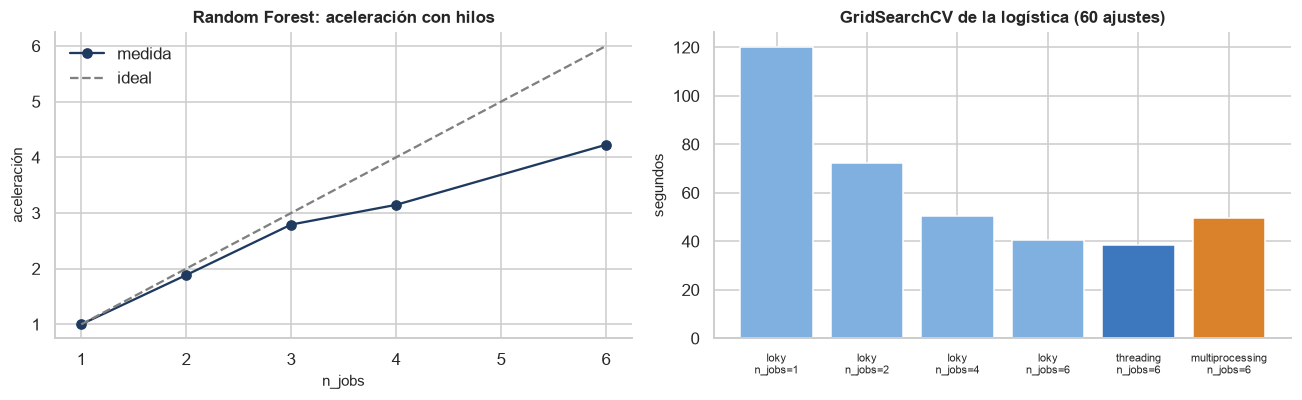

tiempo_s
experimento                                backend         n_jobs          
Random Forest (300 árboles)                hilos nativos   1        78.5477
                                                           2        41.6654
                                                           3        28.1344
                                                           4        24.9660
                                                           6        18.5886
GridSearchCV logística L1 (12 × 5 ajustes) loky            1       120.2996
                                                           2        72.3947
                                                           4        50.3577
                                                           6        40.6293
                                           threading       6        38.5717
                                           multiprocessing 6        49.5163


Random Forest acelera 4,2 veces con 6 hilos: según la ley de Amdahl, el 92 % de su trabajo es
paralelizable (los árboles son independientes; lo secuencial es preparar los datos y combinar). En la
búsqueda en rejilla, `loky` con 6 procesos tarda 40,63 s frente a 120,30 s en serie;
`threading` tarda 38,57 s, porque liblinear libera el GIL y los hilos evitan copiar los datos a cada
proceso; y `multiprocessing` tarda 49,52 s, porque en Windows cada proceso arranca un intérprete
nuevo. La elección del *backend* depende de si el trabajo libera el GIL: para los modelos de
`scikit-learn` escritos en C o Cython, los hilos son la opción más barata.


In [60]:
par = leer('paralelismo')
if par is not None:
    rf = par[par['experimento'].str.startswith('Random Forest')].set_index('n_jobs')['tiempo_s']
    acel = rf.loc[1] / rf
    fraccion = 1 - (1 / acel.loc[6] - 1 / 6) / (1 - 1 / 6)          # Amdahl: aceleración = 1 / ((1 − f) + f/N)
    gs = par[par['experimento'].str.startswith('GridSearch')]
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    ax[0].plot(acel.index, acel.values, marker='o', color=graficos.AZUL, label='medida')
    ax[0].plot(acel.index, acel.index, ls='--', color='grey', label='ideal')
    ax[0].set_xlabel('n_jobs')
    ax[0].set_ylabel('aceleración')
    ax[0].set_title('Random Forest: aceleración con hilos')
    ax[0].legend(frameon=False)
    etiquetas = [f'{b}\nn_jobs={n}' for b, n in zip(gs['backend'], gs['n_jobs'])]
    ax[1].bar(etiquetas, gs['tiempo_s'], color=['#7fb0e0'] * 4 + ['#3d78bf', '#d9822b'])
    ax[1].set_ylabel('segundos')
    ax[1].set_title('GridSearchCV de la logística (60 ajustes)')
    ax[1].tick_params(axis='x', labelsize=7)
    plt.tight_layout()
    plt.show()
    display(par.set_index(['experimento', 'backend', 'n_jobs']))
    t = gs.set_index(['backend', 'n_jobs'])['tiempo_s']
    display(Markdown(f"""
Random Forest acelera {dec(acel.loc[6], 1)} veces con 6 hilos: según la ley de Amdahl, el {pct(fraccion, 0)} de su trabajo es
paralelizable (los árboles son independientes; lo secuencial es preparar los datos y combinar). En la
búsqueda en rejilla, `loky` con 6 procesos tarda {dec(t[('loky', 6)], 2)} s frente a {dec(t[('loky', 1)], 2)} s en serie;
`threading` tarda {dec(t[('threading', 6)], 2)} s, porque liblinear libera el GIL y los hilos evitan copiar los datos a cada
proceso; y `multiprocessing` tarda {dec(t[('multiprocessing', 6)], 2)} s, porque en Windows cada proceso arranca un intérprete
nuevo. La elección del *backend* depende de si el trabajo libera el GIL: para los modelos de
`scikit-learn` escritos en C o Cython, los hilos son la opción más barata.
"""))

### Paralelizar entre modelos y cómputo distribuido

La guía (§4.3) pide paralelizar también *entre* modelos, no solo entre pliegues. El experimento
reparte los 6 núcleos de cuatro maneras para hacer las mismas cuatro búsquedas en rejilla de
modelos distintos.

In [61]:
em = leer('entre_modelos')
if em is not None:
    em = em.set_index('esquema')
    em['aceleración frente a la serie'] = em.loc['todo en serie (1 núcleo)', 'tiempo_s'] / em['tiempo_s']
    display(em)
    mejor_esq = em['tiempo_s'].idxmin()
    total_h = None
    try:
        from src import analisis
        total_h = analisis.cargar_tabla().query("estado == 'ok' and modelo != 'ebm'")['tiempo_total_s'].sum() / 3600
    except Exception:
        pass
    dentro_gana = mejor_esq.startswith('dentro')
    display(Markdown(f"""
El esquema más rápido fue **{mejor_esq}** ({dec(em.loc[mejor_esq, 'tiempo_s'], 1)} s, {dec(em.loc[mejor_esq, 'aceleración frente a la serie'], 1)} veces más rápido
que en serie). {('Cada búsqueda tiene 8 configuraciones × 3 pliegues = 24 tareas, más que núcleos, así que paralelizar dentro de cada una ya mantiene ocupados los 6 núcleos; paralelizar entre modelos, en cambio, usa solo 4 procesos y queda a la espera del modelo más lento (el árbol y la logística tardan mucho más que Naive Bayes). Paralelizar entre modelos compensa cuando cada modelo tiene pocas tareas internas o cuando hay más núcleos que tareas por modelo.' if dentro_gana else 'Combinar los dos niveles equilibra mejor la carga: ninguno de los dos, por separado, mantiene los 6 núcleos ocupados todo el tiempo.')}
En las 140 corridas se paralelizó dentro de cada corrida (pliegues × configuraciones), porque cada corrida
tiene cientos de tareas y ya ocupaba los 6 núcleos; las corridas iban en serie para que los tiempos por
evaluación de cada optimizador no se contaminaran entre sí, que es lo que compara la sección de
optimizadores.

**Dask y Ray.** Las 140 combinaciones son independientes entre sí, de modo que el problema es perfectamente
paralelizable entre máquinas: con Ray (`ray.remote` sobre la función de una corrida) o con el *backend* de
Dask para joblib, {f"las {dec(total_h, 1)} horas de cómputo de este equipo" if total_h else "el tiempo total"} se dividirían casi linealmente entre los
nodos de un clúster. No se usaron porque el conjunto cabe en la memoria de un solo equipo (unos 30 MB tras el
preprocesamiento) y el plazo admitía un día de cómputo; con más datos, o con el producto completo repetido
para varias semillas, serían el siguiente paso natural.
"""))

,tiempo_s,aceleración frente a la serie
esquema,,
todo en serie (1 núcleo),64.6990,1.0000
"dentro de cada modelo (n_jobs=6), modelos en serie",24.7223,2.6170
"entre modelos (4 a la vez, n_jobs=1 dentro)",44.2086,1.4635
mixto (2 modelos a la vez × n_jobs=3 dentro),27.5029,2.3524



El esquema más rápido fue **dentro de cada modelo (n_jobs=6), modelos en serie** (24,7 s, 2,6 veces más rápido
que en serie). Cada búsqueda tiene 8 configuraciones × 3 pliegues = 24 tareas, más que núcleos, así que paralelizar dentro de cada una ya mantiene ocupados los 6 núcleos; paralelizar entre modelos, en cambio, usa solo 4 procesos y queda a la espera del modelo más lento (el árbol y la logística tardan mucho más que Naive Bayes). Paralelizar entre modelos compensa cuando cada modelo tiene pocas tareas internas o cuando hay más núcleos que tareas por modelo.
En las 140 corridas se paralelizó dentro de cada corrida (pliegues × configuraciones), porque cada corrida
tiene cientos de tareas y ya ocupaba los 6 núcleos; las corridas iban en serie para que los tiempos por
evaluación de cada optimizador no se contaminaran entre sí, que es lo que compara la sección de
optimizadores.

**Dask y Ray.** Las 140 combinaciones son independientes entre sí, de modo que el problema es perfectamente
paralelizable entre máquinas: con Ray (`ray.remote` sobre la función de una corrida) o con el *backend* de
Dask para joblib, las 26,9 horas de cómputo de este equipo se dividirían casi linealmente entre los
nodos de un clúster. No se usaron porque el conjunto cabe en la memoria de un solo equipo (unos 30 MB tras el
preprocesamiento) y el plazo admitía un día de cómputo; con más datos, o con el producto completo repetido
para varias semillas, serían el siguiente paso natural.


## 8. Perfil de una validación cruzada

`cProfile` sobre una validación cruzada de 3 pliegues del pipeline completo con SMOTE y XGBoost.

In [62]:
perfil = leer('perfil')
if perfil is not None:
    total = perfil['acumulado_s'].max()
    componentes = {
        'preprocesado (ColumnTransformer)': perfil[perfil['archivo'].eq('_column_transformer.py') & perfil['funcion'].isin(['fit_transform', 'transform'])],
        'SMOTE (fit_resample)': perfil[perfil['funcion'].eq('fit_resample')],
        'XGBoost (entrenamiento)': perfil[perfil['archivo'].isin(['sklearn.py', 'training.py', 'core.py']) & perfil['funcion'].isin(['fit', 'train', 'update'])],
        'puntuación (predict_proba y AUC)': perfil[perfil['funcion'].isin(['predict_proba', 'roc_auc_score'])],
    }
    resumen = pd.Series({k: v['acumulado_s'].max() if len(v) else np.nan for k, v in componentes.items()})
    display((resumen / total).to_frame('fracción del tiempo total').assign(segundos=resumen))
    utiles = perfil[~perfil['archivo'].isin(['parallel.py', '_param_validation.py', '_validation.py'])]
    display(utiles.head(15))
    cuota = (resumen / total).dropna()
    display(Markdown(f"""
De los {dec(total, 1)} s de la validación cruzada, {enumerar(f"{k} se lleva el {pct(v, 0)}" for k, v in cuota.sort_values(ascending=False).items())}.
El cuello de botella es el ajuste del modelo, no la preparación de los datos ni el remuestreo: optimizar
el pipeline pasa por el modelo (método `hist`, menos árboles con *early stopping*, multi-fidelidad), que es
lo que se hizo.
"""))
    print((CARPETA / 'perfil.txt').read_text(encoding='utf-8')[:3000])

,fracción del tiempo total,segundos
preprocesado (ColumnTransformer),0.0628,0.8840
SMOTE (fit_resample),0.0951,1.3389
XGBoost (entrenamiento),0.7925,11.1571
puntuación (predict_proba y AUC),0.0199,0.2802


,funcion,archivo,llamadas,propio_s,acumulado_s,fraccion_del_total
8,wrapper,base.py,18,0.0185,13.4036,0.9520
9,fit,pipeline.py,3,0.0003,13.3974,0.9516
10,inner_f,core.py,45,0.0006,11.1910,0.7949
11,fit,sklearn.py,3,0.0002,11.1571,0.7925
12,train,training.py,3,0.0035,10.5274,0.7477
13,update,core.py,435,10.3620,10.4430,0.7417
14,_fit,pipeline.py,3,0.0085,2.2377,0.1589
15,__call__,memory.py,6,0.0000,2.2284,0.1583
16,_fit_resample_one,pipeline.py,3,0.0000,1.3389,0.0951
17,fit_resample,base.py,3,0.0000,1.3389,0.0951



De los 14,1 s de la validación cruzada, XGBoost (entrenamiento) se lleva el 79 %, SMOTE (fit_resample) se lleva el 10 %, preprocesado (ColumnTransformer) se lleva el 6 % y puntuación (predict_proba y AUC) se lleva el 2 %.
El cuello de botella es el ajuste del modelo, no la preparación de los datos ni el remuestreo: optimizar
el pipeline pasa por el modelo (método `hist`, menos árboles con *early stopping*, multi-fidelidad), que es
lo que se hizo.


         252863 function calls (247908 primitive calls) in 14.079 seconds

   Ordered by: cumulative time
   List reduced from 1287 to 25 due to restriction <25>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     24/1    0.000    0.000   14.079   14.079 D:\Ruben\universidad\machine_learning\entrega 3\.venv\Lib\site-packages\sklearn\utils\_param_validation.py:187(wrapper)
        1    0.000    0.000   14.078   14.078 D:\Ruben\universidad\machine_learning\entrega 3\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:496(cross_val_score)
        1    0.000    0.000   14.077   14.077 D:\Ruben\universidad\machine_learning\entrega 3\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:75(cross_validate)
      7/1    0.000    0.000   14.071   14.071 D:\Ruben\universidad\machine_learning\entrega 3\.venv\Lib\site-packages\sklearn\utils\parallel.py:54(__call__)
      7/1    0.000    0.000   14.071   14.071 D:\Ruben\universidad\machine_learning\entr

## 9. ¿Es válida la multi-fidelidad?

La multi-fidelidad de la búsqueda supone que la versión barata (100 árboles en Random Forest, 2 bolsas
en la EBM) ordena las configuraciones igual que la cara (300 árboles, 8 bolsas). Se comprueba con
configuraciones aleatorias del espacio de búsqueda, evaluadas con las dos fidelidades y la misma
validación cruzada de 3 pliegues.

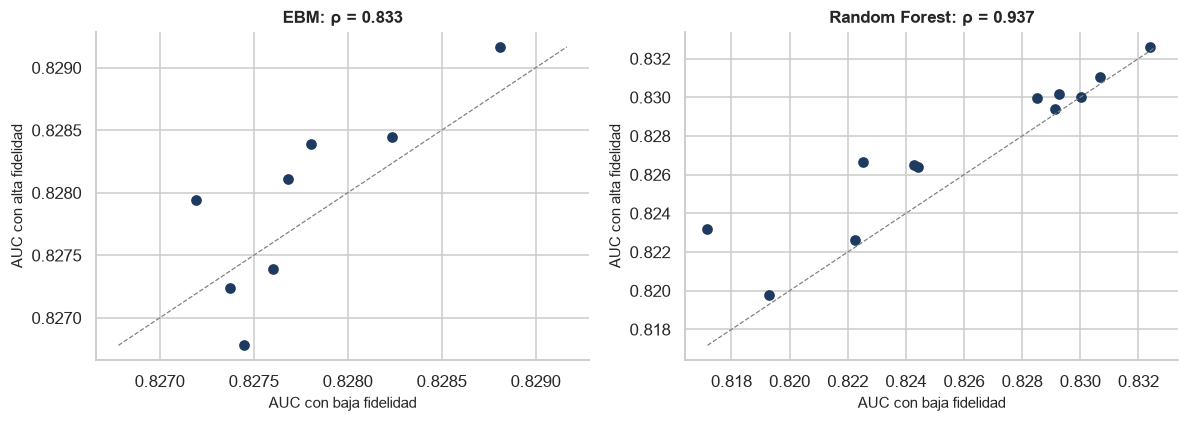

,configuraciones,ρ de Spearman baja/alta,misma mejor configuración,pérdida al elegir con baja fidelidad,ahorro de tiempo
modelo,,,,,
EBM,8,0.8333,True,0.0000,0.6553
Random Forest,12,0.9371,True,0.0000,0.6515



El orden se conserva: la correlación de Spearman entre los AUC con fidelidad baja y alta es de
0,833 en EBM y 0,937 en Random Forest.
La configuración ganadora es la misma con las dos fidelidades en los dos modelos,
y la fidelidad baja ahorra el 65 % o más del tiempo de búsqueda. La multi-fidelidad de las
corridas está justificada.


In [63]:
fid = leer('fidelidad')
if fid is not None:
    filas = []
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for a, (m, g) in zip(ax, fid.groupby('modelo')):
        rho = stats.spearmanr(g['auc_baja'], g['auc_alta']).statistic
        mismo_mejor = g['auc_baja'].idxmax() == g['auc_alta'].idxmax()
        filas.append({'modelo': NOMBRES_MODELO[m], 'configuraciones': len(g), 'ρ de Spearman baja/alta': rho,
                      'misma mejor configuración': mismo_mejor,
                      'pérdida al elegir con baja fidelidad': g['auc_alta'].max() - g.loc[g['auc_baja'].idxmax(), 'auc_alta'],
                      'ahorro de tiempo': 1 - g['tiempo_baja_s'].sum() / g['tiempo_alta_s'].sum()})
        a.scatter(g['auc_baja'], g['auc_alta'], color=graficos.AZUL)
        lim = [min(g['auc_baja'].min(), g['auc_alta'].min()), max(g['auc_baja'].max(), g['auc_alta'].max())]
        a.plot(lim, lim, ls='--', color='grey', lw=0.8)
        a.set_xlabel('AUC con baja fidelidad')
        a.set_ylabel('AUC con alta fidelidad')
        a.set_title(f'{NOMBRES_MODELO[m]}: ρ = {rho:.3f}')
    plt.tight_layout()
    plt.show()
    fidelidad = pd.DataFrame(filas).set_index('modelo')
    display(fidelidad)
    perdida = fidelidad['pérdida al elegir con baja fidelidad'].max()
    display(Markdown(f"""
El orden se conserva: la correlación de Spearman entre los AUC con fidelidad baja y alta es de
{enumerar(f"{dec(r['ρ de Spearman baja/alta'], 3)} en {m.replace(' (modelo nuevo)', '')}" for m, r in fidelidad.iterrows())}.
{'La configuración ganadora es la misma con las dos fidelidades en los dos modelos' if perdida <= 1e-9 else 'Elegir con la fidelidad baja cuesta como máximo ' + dec(perdida, 4) + ' de AUC frente a elegir con la alta'},
y la fidelidad baja ahorra el {pct(fidelidad['ahorro de tiempo'].min(), 0)} o más del tiempo de búsqueda. La multi-fidelidad de las
corridas está justificada.
"""))

## 10. Tabla resumen: versión estándar frente a versión optimizada

In [64]:
filas = []

def fila(modelo, estandar, optimizada, complejidad, t_e, t_o, i_e=np.nan, i_o=np.nan, mem_e=np.nan, mem_o=np.nan,
         met_e=np.nan, met_o=np.nan, metrica='AUC'):
    filas.append({'modelo': modelo, 'versión estándar': estandar, 'versión optimizada': optimizada,
                  'complejidad (estándar → optimizada)': complejidad, 'entrenamiento estándar (s)': t_e,
                  'entrenamiento optimizado (s)': t_o, 'aceleración del entrenamiento': t_e / t_o if t_o else np.nan,
                  'inferencia estándar (s)': i_e, 'inferencia optimizada (s)': i_o,
                  'memoria estándar (MB)': mem_e, 'memoria optimizada (MB)': mem_o,
                  'métrica': metrica, 'estándar': met_e, 'optimizada': met_o, 'cambio en la métrica': met_o - met_e})

if knn is not None:
    k = knn[knn['dimension'] == '78 variables'].set_index('metodo')
    fila('k-NN', 'scikit-learn, fuerza bruta', 'FAISS IndexFlat', 'O(n·m·p) → O(n·m·p) vectorizado',
         k.loc['scikit-learn brute', 'construccion_s'], k.loc['FAISS IndexFlat (exacto)', 'construccion_s'],
         k.loc['scikit-learn brute', 'consulta_s'], k.loc['FAISS IndexFlat (exacto)', 'consulta_s'],
         k.loc['scikit-learn brute', 'indice_mb'], k.loc['FAISS IndexFlat (exacto)', 'indice_mb'],
         k.loc['scikit-learn brute', 'auc'], k.loc['FAISS IndexFlat (exacto)', 'auc'])
    hnsw = [i for i in k.index if 'HNSW' in i]
    if hnsw:
        fila('k-NN', 'scikit-learn, fuerza bruta', 'FAISS HNSW (aproximado)', 'O(n·m·p) → O(m·log n·p)',
             k.loc['scikit-learn brute', 'construccion_s'], k.loc[hnsw[0], 'construccion_s'],
             k.loc['scikit-learn brute', 'consulta_s'], k.loc[hnsw[0], 'consulta_s'],
             k.loc['scikit-learn brute', 'indice_mb'], k.loc[hnsw[0], 'indice_mb'],
             k.loc['scikit-learn brute', 'auc'], k.loc[hnsw[0], 'auc'])
if knn is not None:
    k4 = knn[knn['dimension'] == '4 variables con señal'].set_index('metodo')
    fila('k-NN', '78 variables, fuerza bruta', '4 variables con señal, KD-Tree', "O(n·m·p) → O(m·log n·p') con p' = 4",
         k.loc['scikit-learn brute', 'construccion_s'], k4.loc['scikit-learn kd_tree', 'construccion_s'],
         k.loc['scikit-learn brute', 'consulta_s'], k4.loc['scikit-learn kd_tree', 'consulta_s'],
         k.loc['scikit-learn brute', 'indice_mb'], k4.loc['scikit-learn kd_tree', 'indice_mb'],
         k.loc['scikit-learn brute', 'auc'], k4.loc['scikit-learn kd_tree', 'auc'])
if lin is not None:
    r = lin[lin['modelo'] == 'Ridge'].set_index('solucionador')
    fila('Ridge', 'SAGA', f"{r['entrenamiento_s'].idxmin()} (directo)", 'O(k·n·p) → O(n·p² + p³)',
         r.loc['saga', 'entrenamiento_s'], r['entrenamiento_s'].min(), met_e=r.loc['saga', 'valor'],
         met_o=r.loc[r['entrenamiento_s'].idxmin(), 'valor'], metrica='RMSE')
    l = lin[lin['modelo'] == 'Lasso'].set_index('solucionador')
    fila('Lasso', 'SGD con L1', 'descenso por coordenadas', 'O(k·n·p) en los dos',
         l.loc['SGD con penalización L1', 'entrenamiento_s'], l.loc['descenso por coordenadas', 'entrenamiento_s'],
         met_e=l.loc['SGD con penalización L1', 'valor'], met_o=l.loc['descenso por coordenadas', 'valor'], metrica='RMSE')
if nb is not None:
    fila('Naive Bayes', 'fit completo', 'partial_fit en lotes de 5.000', 'O(n·p) en los dos; memoria O(lote·p)',
         nb.iloc[0]['entrenamiento_s'], nb.iloc[2]['entrenamiento_s'], mem_e=nb.iloc[0]['memoria_mb'],
         mem_o=nb.iloc[2]['memoria_mb'], met_e=nb.iloc[0]['auc'], met_o=nb.iloc[2]['auc'])
if xg is not None:
    m = xg[xg['experimento'] == 'método y dispositivo'].set_index('variante')
    ex = m[m.index.str.startswith('exact')].iloc[0]
    hi = m.loc['hist · cpu · todos los hilos']
    gp = m[m.index.str.contains('cuda')].iloc[0]
    fila('XGBoost', 'exact (CPU)', 'hist (CPU)', 'O(T·d·n·p·log n) → O(T·d·(n·p + bins·p))',
         ex['entrenamiento_s'], hi['entrenamiento_s'], ex['inferencia_s'], hi['inferencia_s'], met_e=ex['auc'], met_o=hi['auc'])
    fila('XGBoost', 'hist (CPU, 6 hilos)', 'hist (GPU RTX 3050)', 'igual, en otro dispositivo',
         hi['entrenamiento_s'], gp['entrenamiento_s'], hi['inferencia_s'], gp['inferencia_s'], met_e=hi['auc'], met_o=gp['auc'])
    es = xg[xg['experimento'] == 'early stopping'].reset_index(drop=True)
    fila('XGBoost', '500 árboles fijos', f"early stopping ({es.loc[1, 'arboles']:.0f} árboles)", 'O(T) → O(T*), T* < T',
         es.loc[0, 'entrenamiento_s'], es.loc[1, 'entrenamiento_s'], met_e=es.loc[0, 'auc'], met_o=es.loc[1, 'auc'])
if svm is not None and len(rbf):
    fila('SVM', 'SVC núcleo RBF (extrapolado a n)', 'LinearSVC primal', 'O(n²·p)–O(n³) → O(k·n·p)',
         extrapolado, lineal['entrenamiento_s'], met_e=rbf_max['auc'], met_o=lineal['auc'])
if par is not None:
    fila('Random Forest', 'n_jobs = 1', 'n_jobs = 6', 'O(T·n·p·log n) repartido en 6 núcleos', rf.loc[1], rf.loc[6])
if fid is not None:
    for m, g in fid.groupby('modelo'):
        fila(NOMBRES_MODELO[m], 'búsqueda con fidelidad alta', 'búsqueda con fidelidad baja (multi-fidelidad)',
             'O(T) → O(T/3) en Random Forest; O(B) → O(B/4) en la EBM', g['tiempo_alta_s'].sum(), g['tiempo_baja_s'].sum(),
             met_e=g['auc_alta'].max(), met_o=g.loc[g['auc_baja'].idxmax(), 'auc_alta'])
if filas:
    tabla_comp = pd.DataFrame(filas).set_index(['modelo', 'versión estándar', 'versión optimizada'])
    display(tabla_comp)
else:
    display(Markdown('*La tabla se completa cuando terminen los experimentos.*'))

complejidad (estándar → optimizada)  \
modelo        versión estándar                 versión optimizada                                                                                 
k-NN          scikit-learn, fuerza bruta       FAISS IndexFlat                                                  O(n·m·p) → O(n·m·p) vectorizado   
                                               FAISS HNSW (aproximado)                                                  O(n·m·p) → O(m·log n·p)   
              78 variables, fuerza bruta       4 variables con señal, KD-Tree                               O(n·m·p) → O(m·log n·p') con p' = 4   
Ridge         SAGA                             cholesky (directo)                                                       O(k·n·p) → O(n·p² + p³)   
Lasso         SGD con L1                       descenso por coordenadas                                                     O(k·n·p) en los dos   
Naive Bayes   fit completo                     partial_fit en lotes de 5.000                               O(n·p) en los dos; memoria O(lote·p)   
XGBoost       exact (CPU)                      hist (CPU)                                              O(T·d·n·p·log n) → O(T·d·(n·p + bins·p))   
              hist (CPU, 6 hilos)              hist (GPU RTX 3050)                                                   igual, en otro dispositivo   
              500 árboles fijos                early stopping (153 árboles)                                                O(T) → O(T*), T* < T   
SVM           SVC núcleo RBF (extrapolado a n) LinearSVC primal                                                        O(n²·p)–O(n³) → O(k·n·p)   
Random Forest n_jobs = 1                       n_jobs = 6                                                 O(T·n·p·log n) repartido en 6 núcleos   
EBM           búsqueda con fidelidad alta      búsqueda con fidelidad baja (multi-fidelidad)  O(T) → O(T/3) en Random Forest; O(B) → O(B/4) ...   
Random Forest búsqueda con fidelidad alta      búsqueda con fidelidad baja (multi-fidelidad)  O(T) → O(T/3) en Random Forest; O(B) → O(B/4) ...   

                                                                                              entrenamiento estándar (s)  \
modelo        versión estándar                 versión optimizada                                                          
k-NN          scikit-learn, fuerza bruta       FAISS IndexFlat                                                    0.0033   
                                               FAISS HNSW (aproximado)                                            0.0033   
              78 variables, fuerza bruta       4 variables con señal, KD-Tree                                     0.0033   
Ridge         SAGA                             cholesky (directo)                                                15.0818   
Lasso         SGD con L1                       descenso por coordenadas                                           0.8792   
Naive Bayes   fit completo                     partial_fit en lotes de 5.000                                      0.0462   
XGBoost       exact (CPU)                      hist (CPU)                                                         5.7574   
              hist (CPU, 6 hilos)              hist (GPU RTX 3050)                                                0.8245   
              500 árboles fijos                early stopping (153 árboles)                                       2.7219   
SVM           SVC núcleo RBF (extrapolado a n) LinearSVC primal                                                  43.1122   
Random Forest n_jobs = 1                       n_jobs = 6                                                        78.5477   
EBM           búsqueda con fidelidad alta      búsqueda con fidelidad baja (multi-fidelidad)                    306.5848   
Random Forest búsqueda con fidelidad alta      búsqueda con fidelidad baja (multi-fidelidad)                    280.0975   

                                         

# Evaluación en prueba, calibración, residuos y robustez

Cada modelo entra con su mejor combinación de balanceo y optimizador según el bucle externo, y su
modelo final (reajustado con todo el entrenamiento) toca la prueba una sola vez. Esta página cubre la
evaluación de clasificación (§5.1), la de regresión (§5.2) y la robustez (§5.4). La etiqueta es la
del percentil 75.

In [65]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, comparacion, datos, evaluacion, graficos
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, intervalo, p_valor, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

COMPLEMENTOS = RAIZ / 'resultados' / 'complementos'
tabla = analisis.cargar_tabla()
p = datos.preparar_todo()
X_te = p['conjuntos'].X_test.sort_index()                  # orden original del archivo
y_te, y_te_c = p['y_test'].loc[X_te.index], p['conjuntos'].y_test_cont.loc[X_te.index]
pred = analisis.predecir_prueba(tabla, X_te, RAIZ / 'resultados' / 'predicciones_prueba.parquet',
                                informar=lambda s: None)
metricas = analisis.metricas_prueba(tabla, pred, y_te, y_te_c)
mejores = {t: analisis.mejores_por_modelo(tabla, t) for t in ('clasificacion', 'regresion')}
claves = {t: m.set_index('modelo')['clave'] for t, m in mejores.items()}


def pendiente(nombre):
    display(Markdown(f'*Resultado pendiente: `{nombre}` todavía no se ha calculado (lo produce `complementos.py`).*'))


display(Markdown(f'Prueba: {ent(len(y_te))} clientes, {pct(y_te.mean(), 1)} de riesgo alto.'))

Prueba: 9.745 clientes, 24,6 % de riesgo alto.

## 1. Clasificación

### Métricas de prueba

La métrica principal es el **AUC**: no depende del umbral ni de la prevalencia, y mide lo que
necesita una campaña de retención con presupuesto limitado, que es ordenar a los clientes por riesgo
para contactar primero a los de mayor riesgo. Accuracy, precisión, recall y F1 se calculan con el
umbral por defecto de 0,5, y el Brier mide la calidad de las probabilidades.

In [66]:
m_clf = metricas[metricas['tarea'] == 'clasificacion'].merge(mejores['clasificacion'][analisis.CLAVE], on=analisis.CLAVE)
m_clf = m_clf.assign(modelo=m_clf['modelo'].map(NOMBRES_MODELO)).set_index('modelo')
m_clf = m_clf[['balanceo', 'optimizador', 'metrica_cv', 'auc', 'accuracy', 'precision', 'recall', 'f1', 'brier']]
m_clf.sort_values('auc', ascending=False)

,balanceo,optimizador,metrica_cv,auc,accuracy,precision,recall,f1,brier
modelo,,,,,,,,,
EBM,class_weight,grid,0.8292,0.8289,0.7301,0.4681,0.7074,0.5634,0.1732
XGBoost,class_weight,genetica,0.8332,0.8283,0.6963,0.4476,0.9983,0.6181,0.1875
Random Forest,ninguno,genetica,0.8326,0.8260,0.7812,0.6315,0.2672,0.3755,0.1323
Árbol de decisión,class_weight,random,0.8332,0.8243,0.6964,0.4477,0.9996,0.6184,0.1690
k-NN,ninguno,genetica,0.7836,0.7874,0.7538,0.0000,0.0000,0.0000,0.1660
Regresión logística,class_weight,genetica,0.7644,0.7709,0.6791,0.4102,0.6928,0.5153,0.1977
SVM lineal,class_weight,grid,0.7641,0.7706,0.6773,0.4088,0.6965,0.5152,NaN
Naive Bayes,ninguno,grid,0.6722,0.6662,0.2847,0.2504,0.9558,0.3968,0.6600


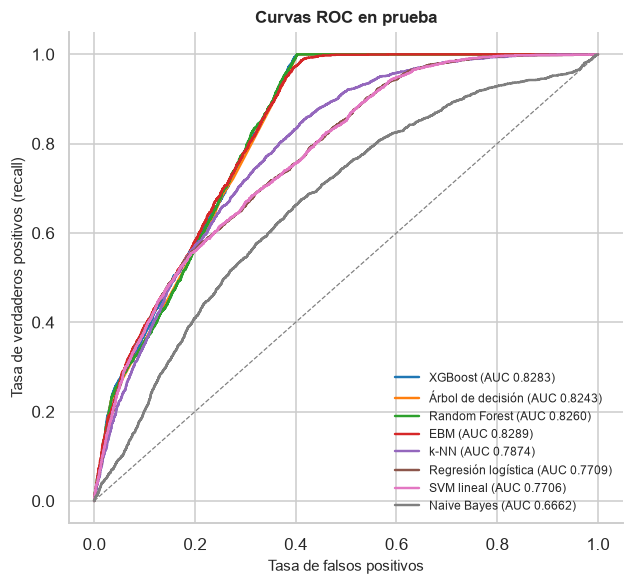

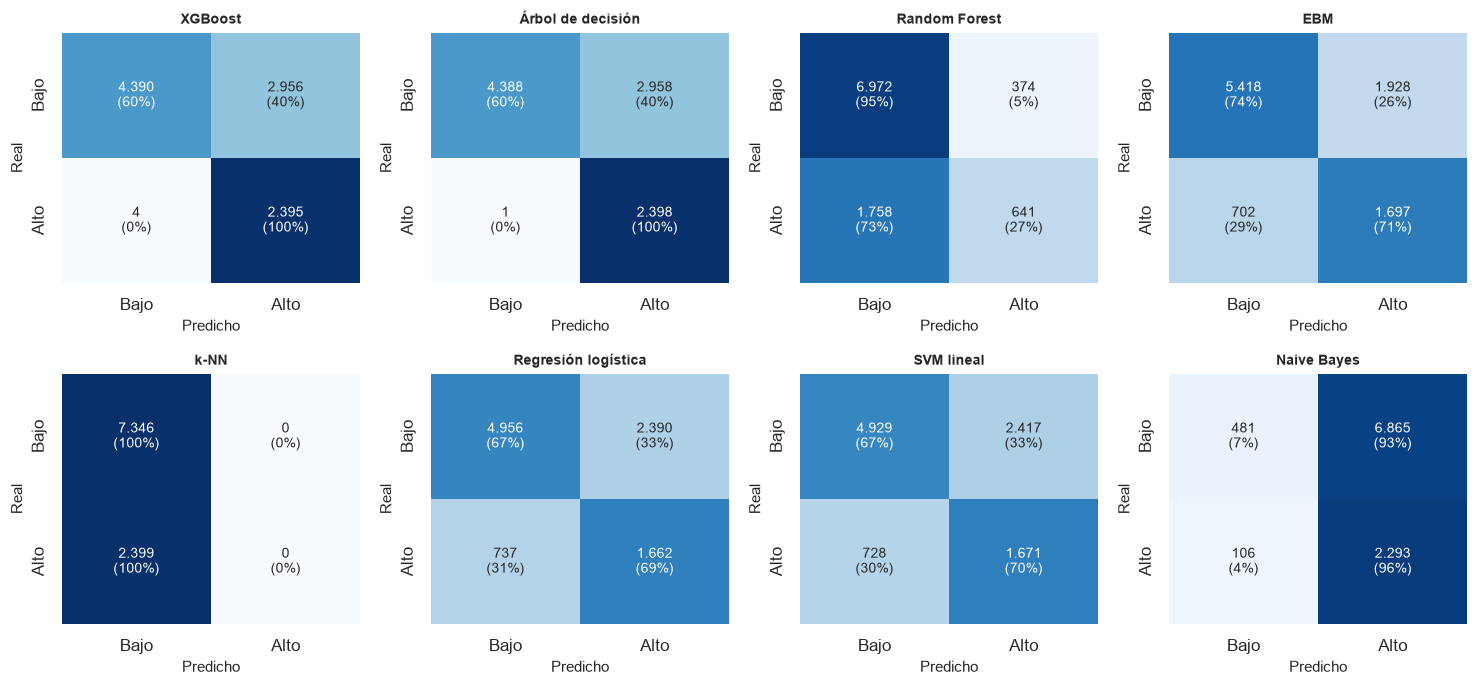

In [67]:
fig, ax = plt.subplots(figsize=(6.5, 5.8))
graficos.curvas_roc(y_te, {NOMBRES_MODELO[m]: pred[k] for m, k in claves['clasificacion'].items()}, ax=ax)
plt.show()
modelos_clf = list(claves['clasificacion'].index)
fig, axes = plt.subplots(2, (len(modelos_clf) + 1) // 2, figsize=(3.4 * ((len(modelos_clf) + 1) // 2), 6.4))
for a, m in zip(axes.ravel(), modelos_clf):
    graficos.matriz_confusion(y_te, pred[claves['clasificacion'][m] + '__clase'], ax=a, titulo=NOMBRES_MODELO[m])
for a in axes.ravel()[len(modelos_clf):]:
    a.axis('off')
plt.tight_layout()
plt.show()

In [68]:
mejor = m_clf['auc'].idxmax()
recall_extremos = m_clf['recall'].agg(['idxmin', 'idxmax'])
display(Markdown(f"""
El AUC de prueba coincide con el de la validación anidada: {enumerar(f"{m} ({dec(r.auc)} frente a {dec(r.metrica_cv)})" for m, r in m_clf.sort_values('auc', ascending=False).head(3).iterrows())}.
Las métricas con umbral, en cambio, varían de un extremo a otro aunque el AUC sea parecido: el
recall va de {dec(m_clf['recall'].min(), 3)} ({recall_extremos['idxmin']}) a {dec(m_clf['recall'].max(), 3)}
({recall_extremos['idxmax']}). El umbral de 0,5 no significa lo mismo para todos los modelos: los
entrenados con `class_weight` desplazan sus probabilidades hacia arriba y casi todo cliente lo
supera, y los entrenados sin balanceo rara vez lo alcanzan con un 25 % de positivos. Por eso el
umbral se fija aparte (abajo) y las probabilidades se calibran.
"""))


El AUC de prueba coincide con el de la validación anidada: EBM (0,8289 frente a 0,8292), XGBoost (0,8283 frente a 0,8332) y Random Forest (0,8260 frente a 0,8326).
Las métricas con umbral, en cambio, varían de un extremo a otro aunque el AUC sea parecido: el
recall va de 0,000 (k-NN) a 1,000
(Árbol de decisión). El umbral de 0,5 no significa lo mismo para todos los modelos: los
entrenados con `class_weight` desplazan sus probabilidades hacia arriba y casi todo cliente lo
supera, y los entrenados sin balanceo rara vez lo alcanzan con un 25 % de positivos. Por eso el
umbral se fija aparte (abajo) y las probabilidades se calibran.


### El umbral de operación

En la práctica, una campaña de retención contacta a una fracción fija de clientes. Si se contacta al
25 % de mayor riesgo (la prevalencia de la etiqueta), el umbral de cada modelo es su percentil 75 de
puntaje, y la comparación entre modelos se vuelve justa.

In [69]:
filas = []
n_contactar = int(round(0.25 * len(y_te)))
desempate = np.random.default_rng(42).random(len(y_te))   # los empates de puntaje se rompen al azar
for m, k in claves['clasificacion'].items():
    s = pred[k].to_numpy()
    contactados = np.zeros(len(s), dtype=bool)
    contactados[np.lexsort((desempate, -s))[:n_contactar]] = True
    vp = int((contactados & (y_te.to_numpy() == 1)).sum())
    filas.append({'modelo': NOMBRES_MODELO[m], 'precisión en el 25 % contactado': vp / contactados.sum(),
                  'recall (fracción de la fuga que se captura)': vp / int(y_te.sum()),
                  'lift frente a contactar al azar': (vp / contactados.sum()) / y_te.mean()})
operacion = pd.DataFrame(filas).set_index('modelo').sort_values('recall (fracción de la fuga que se captura)', ascending=False)
operacion

,precisión en el 25 % contactado,recall (fracción de la fuga que se captura),lift frente a contactar al azar
modelo,,,
EBM,0.5041,0.5119,2.0477
Regresión logística,0.5029,0.5106,2.0427
SVM lineal,0.5029,0.5106,2.0427
XGBoost,0.5025,0.5102,2.0411
k-NN,0.5004,0.5081,2.0327
Árbol de decisión,0.4947,0.5023,2.0094
Random Forest,0.4860,0.4935,1.9744
Naive Bayes,0.4019,0.4081,1.6325


In [70]:
top = operacion.iloc[0]
display(Markdown(f"""
Se contacta exactamente a {ent(n_contactar)} clientes con cada modelo (los empates de puntaje, frecuentes en
el árbol, se rompen al azar). Contactando al 25 % de mayor riesgo según {operacion.index[0]}, la campaña llegaría al
{pct(top['recall (fracción de la fuga que se captura)'], 0)} de los clientes de riesgo alto, con una precisión del
{pct(top['precisión en el 25 % contactado'], 0)}: {dec(top['lift frente a contactar al azar'], 2)} veces lo que se obtendría eligiendo al azar.
Con la misma capacidad, {operacion.index[-1]} capturaría el {pct(operacion.iloc[-1]['recall (fracción de la fuga que se captura)'], 0)}.
"""))


Se contacta exactamente a 2.436 clientes con cada modelo (los empates de puntaje, frecuentes en
el árbol, se rompen al azar). Contactando al 25 % de mayor riesgo según EBM, la campaña llegaría al
51 % de los clientes de riesgo alto, con una precisión del
50 %: 2,05 veces lo que se obtendría eligiendo al azar.
Con la misma capacidad, Naive Bayes capturaría el 41 %.


### Calibración

Una probabilidad está calibrada si, entre los clientes a los que el modelo asigna 0,3, el 30 % es de
riesgo alto. Importa si las probabilidades se van a usar como tales (por ejemplo, para estimar la
pérdida esperada de clientes). Se mide con el diagrama de confiabilidad, el **Brier** (error
cuadrático de la probabilidad) y el **ECE** (distancia media ponderada entre probabilidad anunciada y
frecuencia observada, con 10 intervalos). Cuando hace falta se recalibra con **Platt** (una logística
sobre el puntaje) o con regresión **isotónica** (una función monótona por tramos), ajustadas **solo con
predicciones fuera de pliegue del entrenamiento** y aplicadas después a la prueba.

brier                             ece            \
version              Platt isotónica sin recalibrar  Platt isotónica   
modelo                                                                 
EBM                 0.1438    0.1338         0.1732 0.0790    0.0060   
Naive Bayes         0.1784    0.1736         0.6600 0.0380    0.0041   
Random Forest       0.1325    0.1307         0.1323 0.0281    0.0029   
Regresión logística 0.1537    0.1521         0.1977 0.0319    0.0064   
SVM lineal          0.1539    0.1523            NaN 0.0320    0.0074   
XGBoost             0.1318    0.1305         0.1875 0.0263    0.0075   
k-NN                0.1523    0.1510         0.1660 0.0300    0.0082   
Árbol de decisión   0.1309    0.1308         0.1690 0.0105    0.0100   

                                    
version             sin recalibrar  
modelo                              
EBM                         0.1698  
Naive Bayes                 0.6824  
Random Forest               0.0274  
Regresión logística         0.1993  
SVM lineal                     NaN  
XGBoost                     0.2201  
k-NN                        0.0837  
Árbol de decisión           0.1442

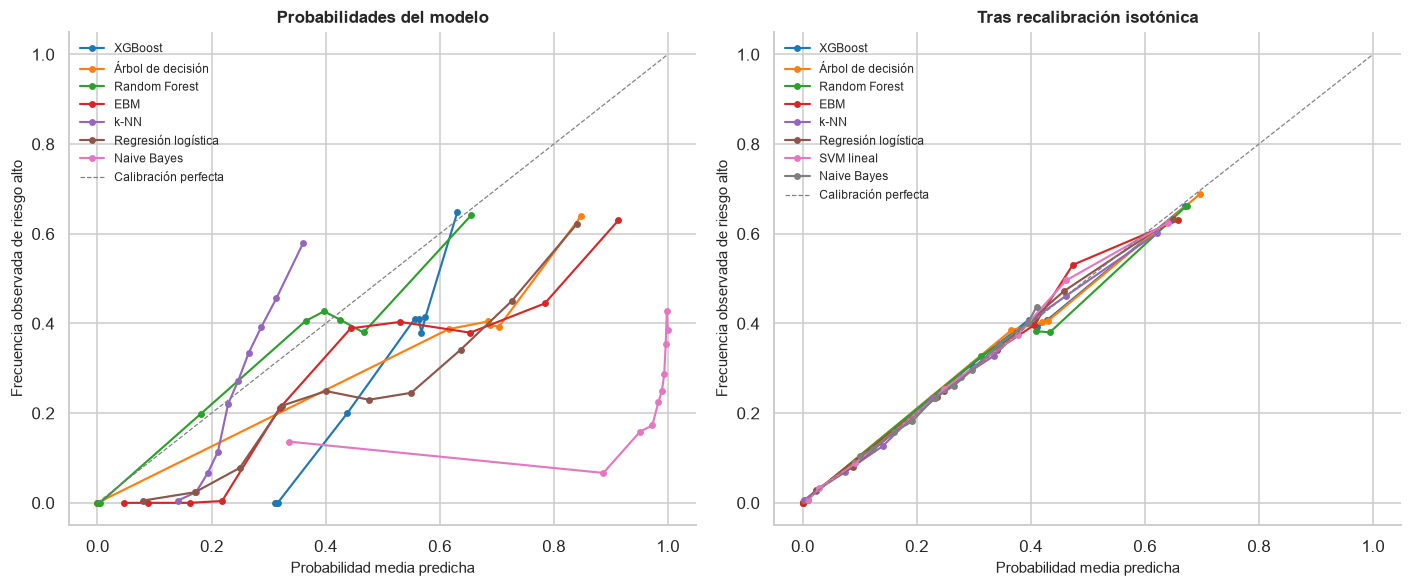


Sin recalibrar, el ECE va de 0,027 (Random Forest) a 0,682 (Naive Bayes). Los peor calibrados
son Naive Bayes (0,682; sin balanceo), XGBoost (0,220; con class_weight), Regresión logística (0,199; con class_weight) y EBM (0,170; con class_weight): los modelos entrenados con `class_weight`
desplazan sus probabilidades hacia arriba a propósito, y Naive Bayes, que supone independencia entre 78
variables, produce probabilidades extremas. La recalibración isotónica, ajustada solo con predicciones
fuera de pliegue del entrenamiento, reduce el ECE de todos
(queda entre 0,003 y 0,010) y apenas mueve el AUC (como mucho
0,0025 frente a Platt), porque es monótona: corrige las probabilidades sin cambiar el orden de
los clientes. El SVM lineal no da probabilidades (solo una función de decisión): Platt e isotónica son las que convierten su puntaje en probabilidad.


In [71]:
if (COMPLEMENTOS / 'calibracion.csv').exists():
    cal = pd.read_csv(COMPLEMENTOS / 'calibracion.csv')
    cal['modelo'] = cal['modelo'].map(NOMBRES_MODELO)
    display(cal.pivot_table(index='modelo', columns='version', values=['brier', 'ece']).round(4))
    probas = pd.read_parquet(COMPLEMENTOS / 'calibracion_prueba.parquet')
    fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
    sin = {NOMBRES_MODELO[m]: probas[f'{k}__sin recalibrar'] for m, k in claves['clasificacion'].items()
           if f'{k}__sin recalibrar' in probas}
    iso = {NOMBRES_MODELO[m]: probas[f'{k}__isotónica'] for m, k in claves['clasificacion'].items()}
    graficos.diagrama_confiabilidad(probas['y_bin'], sin, ax=ax[0], titulo='Probabilidades del modelo')
    graficos.diagrama_confiabilidad(probas['y_bin'], iso, ax=ax[1], titulo='Tras recalibración isotónica')
    plt.tight_layout()
    plt.show()
    piv = cal.pivot_table(index='modelo', columns='version', values='ece')
    sin = piv['sin recalibrar'].dropna()
    mejora = (sin - piv['isotónica'].reindex(sin.index))
    sin_prob = [m for m in piv.index if m not in sin.index]
    bal = cal.drop_duplicates('modelo').set_index('modelo')['balanceo']
    peores = sin.sort_values(ascending=False).head(4)
    auc_cambio = cal.pivot_table(index='modelo', columns='version', values='auc')
    display(Markdown(f"""
Sin recalibrar, el ECE va de {dec(sin.min(), 3)} ({sin.idxmin()}) a {dec(sin.max(), 3)} ({sin.idxmax()}). Los peor calibrados
son {enumerar(f"{m} ({dec(v, 3)}; " + ('sin balanceo' if bal[m] == 'ninguno' else f'con {bal[m]}') + ")" for m, v in peores.items())}: los modelos entrenados con `class_weight`
desplazan sus probabilidades hacia arriba a propósito, y Naive Bayes, que supone independencia entre 78
variables, produce probabilidades extremas. La recalibración isotónica, ajustada solo con predicciones
fuera de pliegue del entrenamiento, {'reduce el ECE de todos' if (mejora > 0).all() else 'reduce el ECE de todos salvo ' + enumerar(mejora[mejora <= 0].index)}
(queda entre {dec(piv['isotónica'].min(), 3)} y {dec(piv['isotónica'].max(), 3)}) y apenas mueve el AUC (como mucho
{dec((auc_cambio['isotónica'] - auc_cambio['Platt']).abs().max(), 4)} frente a Platt), porque es monótona: corrige las probabilidades sin cambiar el orden de
los clientes.{(' El ' + enumerar(sin_prob) + (' no da' if len(sin_prob) == 1 else ' no dan') + ' probabilidades (solo una función de decisión): Platt e isotónica son las que convierten su puntaje en probabilidad.') if sin_prob else ''}
"""))
else:
    pendiente('calibracion.csv')

### El balanceo, medido en prueba

In [72]:
clf_todas = metricas[metricas['tarea'] == 'clasificacion']
mejor_por_bal = clf_todas.loc[clf_todas.groupby(['modelo', 'balanceo'])['metrica_cv'].idxmax()]
bal_auc = mejor_por_bal.pivot(index='modelo', columns='balanceo', values='auc')
bal_rec = mejor_por_bal.pivot(index='modelo', columns='balanceo', values='recall')
bal_auc.index = bal_rec.index = [NOMBRES_MODELO[m] for m in bal_auc.index]
display(bal_auc.round(4))
display(bal_rec.round(3))
d_smote = (bal_auc['smote'] - bal_auc['ninguno']).dropna()
d_cw = (bal_auc['class_weight'] - bal_auc['ninguno']).dropna()
display(Markdown(f"""
En prueba, `class_weight` cambia el AUC entre {dec(d_cw.min(), 4, True)} y {dec(d_cw.max(), 4, True)} frente a no balancear, y
SMOTE entre {dec(d_smote.min(), 4, True)} ({d_smote.idxmin()}) y {dec(d_smote.max(), 4, True)} ({d_smote.idxmax()}): lo baja en
{int((d_smote < 0).sum())} de {len(d_smote)} modelos{('; las excepciones (' if (d_smote > 0).sum() > 1 else '; la excepción (') + enumerar(d_smote[d_smote > 0].index) + (') son de milésimas' if (d_smote > 0).sum() > 1 else ') es de milésimas') + ', dentro de la variabilidad de la prueba' if (d_smote > 0).any() else ''}.
Lo que cambia de verdad es el recall con el umbral de 0,5. El balanceo, en este problema, es una forma
de elegir el punto de operación, no de mejorar el modelo.
"""))

balanceo,adasyn,class_weight,ninguno,smote
Árbol de decisión,0.8206,0.8243,0.8232,0.8288
EBM,0.8265,0.8289,0.8261,0.8253
k-NN,0.7817,NaN,0.7874,0.7767
Regresión logística,0.7708,0.7709,0.7710,0.7706
Naive Bayes,0.6185,0.6662,0.6662,0.6167
Random Forest,0.8263,0.8269,0.8260,0.8272
SVM lineal,0.7701,0.7706,0.7697,0.7699
XGBoost,0.8273,0.8283,0.8280,0.8265


balanceo,adasyn,class_weight,ninguno,smote
Árbol de decisión,0.5240,1.0000,0.2380,0.4640
EBM,0.3440,0.7070,0.3220,0.3410
k-NN,0.8760,NaN,0.0000,0.8790
Regresión logística,0.6800,0.6930,0.2850,0.6800
Naive Bayes,0.9120,0.9600,0.9560,0.9160
Random Forest,0.4640,0.9920,0.2670,0.3880
SVM lineal,0.6850,0.6970,0.2310,0.6850
XGBoost,0.3220,0.9980,0.0000,0.3260



En prueba, `class_weight` cambia el AUC entre −0,0001 y +0,0029 frente a no balancear, y
SMOTE entre −0,0496 (Naive Bayes) y +0,0055 (Árbol de decisión): lo baja en
5 de 8 modelos; las excepciones (Árbol de decisión, Random Forest y SVM lineal) son de milésimas, dentro de la variabilidad de la prueba.
Lo que cambia de verdad es el recall con el umbral de 0,5. El balanceo, en este problema, es una forma
de elegir el punto de operación, no de mejorar el modelo.


## 2. Regresión

### Métricas de prueba con intervalos bootstrap BCa

In [73]:
pron = {m: pred[k].to_numpy() for m, k in claves['regresion'].items()}
int_reg = comparacion.intervalos_regresion(y_te_c, pron)
int_reg.index = [NOMBRES_MODELO[m] for m in int_reg.index]
cv_reg = mejores['regresion'].set_index('modelo')['metrica']
int_reg.insert(0, 'RMSE validación anidada', [cv_reg[m] for m in pron])
int_reg.sort_values('rmse')

,RMSE validación anidada,rmse,rmse_ic_inf,rmse_ic_sup,mae,mae_ic_inf,mae_ic_sup,r2,r2_ic_inf,r2_ic_sup
XGBoost,0.0590,0.0592,0.0584,0.0600,0.0471,0.0464,0.0478,0.2182,0.2031,0.2315
EBM,0.0590,0.0593,0.0585,0.0601,0.0472,0.0465,0.0480,0.2161,0.2008,0.2300
Random Forest,0.0592,0.0593,0.0585,0.0601,0.0473,0.0466,0.0480,0.2146,0.1995,0.2283
Árbol de decisión,0.0593,0.0594,0.0586,0.0603,0.0475,0.0468,0.0482,0.2112,0.1960,0.2255
Lasso,0.0618,0.0617,0.0608,0.0625,0.0507,0.0500,0.0514,0.1511,0.1381,0.1639
Ridge,0.0618,0.0617,0.0608,0.0625,0.0507,0.0500,0.0514,0.1509,0.1377,0.1637
SVR lineal,0.0618,0.0617,0.0609,0.0626,0.0507,0.0500,0.0514,0.1499,0.1365,0.1629
k-NN,0.0634,0.0632,0.0624,0.0641,0.0511,0.0504,0.0519,0.1080,0.1011,0.1147


### Entrenamiento, validación y prueba

La guía pide graficar las predicciones sobre los tres conjuntos. Para entrenamiento se usan las
predicciones del modelo final sobre los clientes con los que se ajustó; para validación, las
predicciones fuera de pliegue (cada cliente de entrenamiento predicho por un modelo que no lo vio); y
la prueba. Los clientes se agrupan en 20 grupos de igual tamaño según el pronóstico.

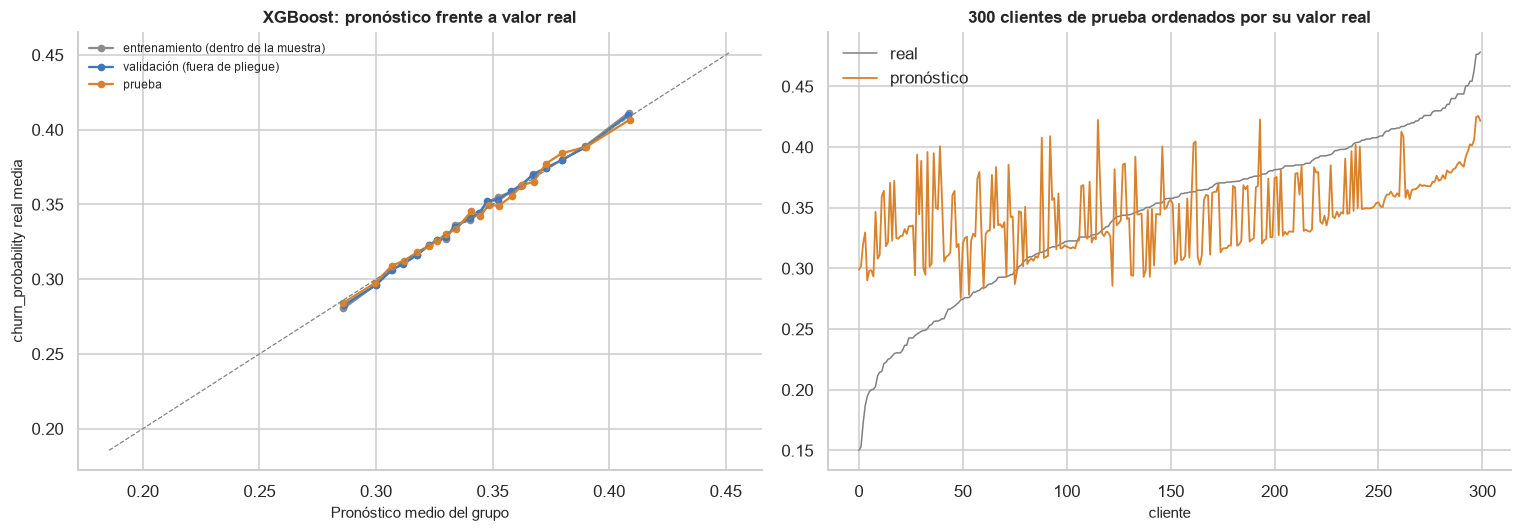

,rmse,mae,r2
conjunto,,,
entrenamiento (dentro de la muestra),0.0587,0.0467,0.2343
validación (fuera de pliegue),0.0590,0.0469,0.2280
prueba,0.0592,0.0471,0.2182



El R² cae de 0,234 dentro de la muestra a 0,228 fuera de pliegue y 0,218
en prueba: el modelo se ajusta algo más a los clientes que vio, pero validación y prueba coinciden, de
modo que la estimación de la validación es fiable. El panel derecho muestra el límite de la tarea: el
pronóstico sigue la tendencia pero se comprime hacia la media, porque la mayor parte de la variación de
`churn_probability` la explica `active_products`, que el modelo no ve.


In [74]:
mejor_r = mejores['regresion'].iloc[0]
if (COMPLEMENTOS / 'fuera_de_pliegue.parquet').exists():
    fdp = pd.read_parquet(COMPLEMENTOS / 'fuera_de_pliegue.parquet')
    k = mejor_r['clave']
    conjuntos = {'entrenamiento (dentro de la muestra)': (fdp['y_cont'], fdp[f'{k}__entrenamiento']),
                 'validación (fuera de pliegue)': (fdp['y_cont'], fdp[f'{k}__fuera_de_pliegue']),
                 'prueba': (y_te_c, pred[k])}
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    filas = []
    for (nombre, (y, yh)), color in zip(conjuntos.items(), ('#8c8c8c', '#3d78bf', '#d9822b')):
        y, yh = np.asarray(y), np.asarray(yh)
        orden = np.argsort(yh)
        grupos = np.array_split(orden, 20)
        ax[0].plot([yh[g].mean() for g in grupos], [y[g].mean() for g in grupos], marker='o', ms=4, color=color, label=nombre)
        filas.append({'conjunto': nombre, **evaluacion.metricas_regresion(y, yh)})
    lim = [float(y_te_c.quantile(0.02)), float(y_te_c.quantile(0.98))]
    ax[0].plot(lim, lim, ls='--', color='grey', lw=0.8)
    ax[0].set_xlabel('Pronóstico medio del grupo')
    ax[0].set_ylabel('churn_probability real media')
    ax[0].set_title(f'{NOMBRES_MODELO[mejor_r["modelo"]]}: pronóstico frente a valor real')
    ax[0].legend(frameon=False, fontsize=8)
    muestra = np.random.default_rng(42).choice(len(y_te_c), 300, replace=False)
    orden = muestra[np.argsort(y_te_c.to_numpy()[muestra])]
    ax[1].plot(y_te_c.to_numpy()[orden], color='grey', lw=1, label='real')
    ax[1].plot(pred[k].to_numpy()[orden], color='#d9822b', lw=1.2, label='pronóstico')
    ax[1].set_title('300 clientes de prueba ordenados por su valor real')
    ax[1].set_xlabel('cliente')
    ax[1].legend(frameon=False)
    plt.tight_layout()
    plt.show()
    tres = pd.DataFrame(filas).set_index('conjunto')
    display(tres)
    display(Markdown(f"""
El R² cae de {dec(tres.iloc[0]['r2'], 3)} dentro de la muestra a {dec(tres.iloc[1]['r2'], 3)} fuera de pliegue y {dec(tres.iloc[2]['r2'], 3)}
en prueba: el modelo se ajusta algo más a los clientes que vio, pero validación y prueba coinciden, de
modo que la estimación de la validación es fiable. El panel derecho muestra el límite de la tarea: el
pronóstico sigue la tendencia pero se comprime hacia la media, porque la mayor parte de la variación de
`churn_probability` la explica `active_products`, que el modelo no ve.
"""))
else:
    pendiente('fuera_de_pliegue.parquet')

### Diagnóstico de los residuos

La guía (§5.2.2 y Cuadro 3) pide verificar los supuestos sobre los residuos de cada modelo de
regresión: White (¿varianza constante?), BDS (¿residuos independientes e idénticamente
distribuidos?), la ACF con Ljung-Box (¿autocorrelación?) y la normalidad. Los residuos se toman en el
orden original del archivo de clientes. Primero, la tabla resumen de todos los modelos; después, el
detalle gráfico del mejor modelo y del Lasso de la Entrega 2.

In [75]:
cuadro = []
for m, k in claves['regresion'].items():
    d_m = evaluacion.diagnostico_residuos(y_te_c, pron[m])
    met = evaluacion.metricas_regresion(y_te_c.to_numpy(), pron[m])
    cuadro.append({'modelo': NOMBRES_MODELO[m], 'RMSE': met['rmse'], 'MAE': met['mae'], 'R²': met['r2'],
                   'p White': d_m.loc['White', 'p'], 'p BDS (dim. 2)': d_m.loc['BDS, dimensión 2 (3000 residuos)', 'p'],
                   'p Ljung-Box (10)': d_m.loc['Ljung-Box, 10 retardos', 'p'], 'p Jarque-Bera': d_m.loc['Jarque-Bera', 'p'],
                   'asimetría': d_m.loc['asimetría', 'estadistico']})
cuadro3 = pd.DataFrame(cuadro).set_index('modelo').sort_values('RMSE')
cuadro3

,RMSE,MAE,R²,p White,p BDS (dim. 2),p Ljung-Box (10),p Jarque-Bera,asimetría
modelo,,,,,,,,
XGBoost,0.0592,0.0471,0.2182,0.6383,0.4378,0.8112,0.0000,-0.9051
EBM,0.0593,0.0472,0.2161,0.6669,0.5456,0.8074,0.0000,-0.9016
Random Forest,0.0593,0.0473,0.2146,0.6310,0.5487,0.7554,0.0000,-0.8957
Árbol de decisión,0.0594,0.0475,0.2112,0.7900,0.6031,0.7201,0.0000,-0.8910
Lasso,0.0617,0.0507,0.1511,0.3907,0.6138,0.0000,0.0000,-0.8001
Ridge,0.0617,0.0507,0.1509,0.6149,0.6500,0.0000,0.0000,-0.8018
SVR lineal,0.0617,0.0507,0.1499,0.6022,0.5969,0.0000,0.0000,-0.8006
k-NN,0.0632,0.0511,0.1080,0.5412,0.3275,0.0000,0.0000,-0.7332


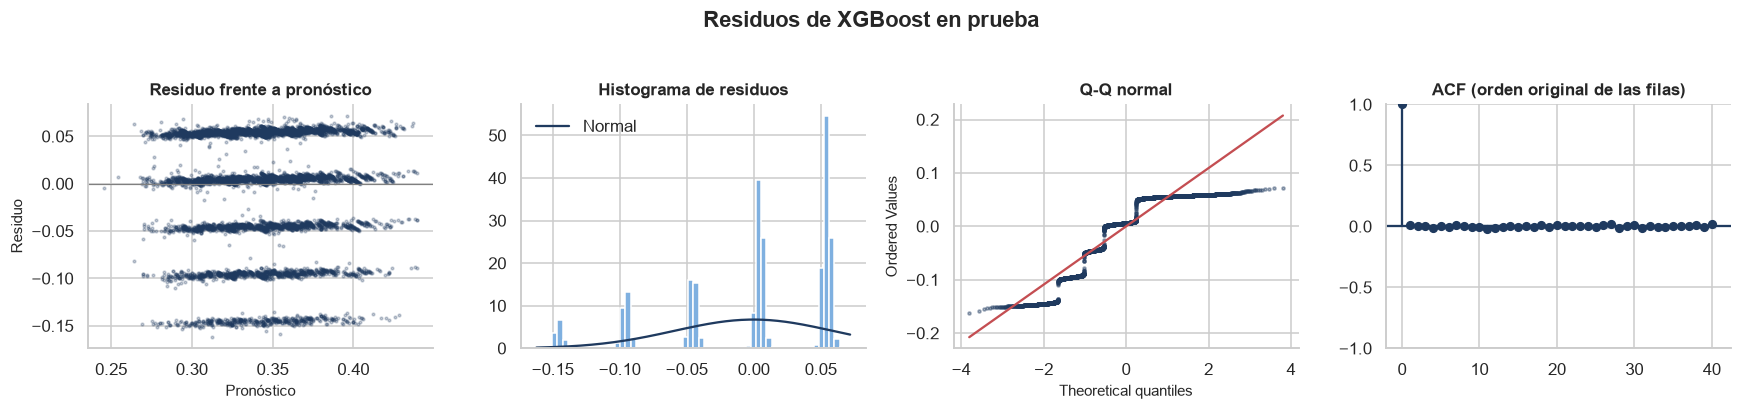

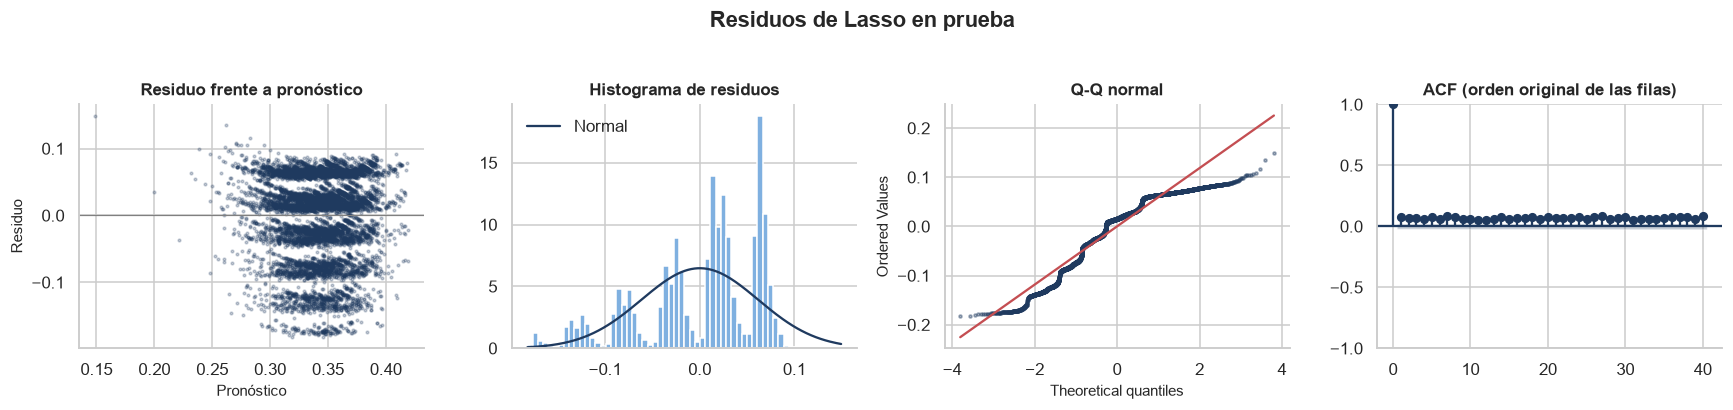

XGBoost  \
                                                      hipótesis nula   
prueba                                                                 
White                             varianza constante de los residuos   
BDS, dimensión 2 (3000 residuos)                     residuos i.i.d.   
BDS, dimensión 3 (3000 residuos)                     residuos i.i.d.   
Ljung-Box, 10 retardos                           sin autocorrelación   
Ljung-Box, 20 retardos                           sin autocorrelación   
Jarque-Bera                                               normalidad   
D'Agostino-Pearson                                        normalidad   
asimetría                                          0 si es simétrica   
curtosis en exceso                                    0 si es normal   

                                                     \
                                 estadistico      p   
prueba                                                
White                                 0.8980 0.6383   
BDS, dimensión 2 (3000 residuos)     -0.7758 0.4378   
BDS, dimensión 3 (3000 residuos)     -0.9460 0.3442   
Ljung-Box, 10 retardos                6.0485 0.8112   
Ljung-Box, 20 retardos               14.0153 0.8297   
Jarque-Bera                       1,340.1656 0.0000   
D'Agostino-Pearson                1,002.7799 0.0000   
asimetría                            -0.9051    NaN   
curtosis en exceso                   -0.1531    NaN   

                                                               Lasso  \
                                                      hipótesis nula   
prueba                                                                 
White                             varianza constante de los residuos   
BDS, dimensión 2 (3000 residuos)                     residuos i.i.d.   
BDS, dimensión 3 (3000 residuos)                     residuos i.i.d.   
Ljung-Box, 10 retardos                           sin autocorrelación   
Ljung-Box, 20 retardos                           sin autocorrelación   
Jarque-Bera                                               normalidad   
D'Agostino-Pearson                                        normalidad   
asimetría                                          0 si es simétrica   
curtosis en exceso                                    0 si es normal   

                                                     
                                 estadistico      p  
prueba                                               
White                                 1.8795 0.3907  
BDS, dimensión 2 (3000 residuos)     -0.5046 0.6138  
BDS, dimensión 3 (3000 residuos)     -0.7166 0.4736  
Ljung-Box, 10 retardos              466.4354 0.0000  
Ljung-Box, 20 retardos              881.8707 0.0000  
Jarque-Bera                       1,046.1670 0.0000  
D'Agostino-Pearson                  822.9394 0.0000  
asimetría                            -0.8001    NaN  
curtosis en exceso                   -0.1270    NaN

In [76]:
diagnosticos = {}
for m in [mejor_r['modelo'], 'lasso']:
    diagnosticos[NOMBRES_MODELO[m]] = evaluacion.diagnostico_residuos(y_te_c, pron[m])
    graficos.panel_residuos(y_te_c, pron[m], titulo=f'Residuos de {NOMBRES_MODELO[m]} en prueba')
    plt.show()
pd.concat(diagnosticos, axis=1)

In [77]:
d = diagnosticos[NOMBRES_MODELO[mejor_r['modelo']]]
rechaza = lambda prueba: d.loc[prueba, 'p'] < 0.05
het = cuadro3[cuadro3['p White'] < 0.05].index.tolist()
dep = cuadro3[(cuadro3['p BDS (dim. 2)'] < 0.05) | (cuadro3['p Ljung-Box (10)'] < 0.05)].index.tolist()
display(Markdown(f"""
En el conjunto de modelos, White rechaza la varianza constante en {len(het)} de {len(cuadro3)}
({enumerar(het) if het else 'ninguno'}) y BDS o Ljung-Box detectan dependencia en {len(dep)}
({enumerar(dep) if dep else 'ninguno'}){': son los modelos que no captan bien el efecto no lineal de la edad, y su residuo conserva parte de la estructura por cohortes con que está ordenado el archivo' if dep else ''}. La normalidad se rechaza en todos: el residuo de cualquier
modelo hereda la mezcla por niveles de `active_products`. Para {NOMBRES_MODELO[mejor_r['modelo']]}:

- **Heterocedasticidad.** White {'rechaza' if rechaza('White') else 'no rechaza'} la varianza constante ({p_valor(d.loc['White', 'p'])}). {'La dispersión del residuo cambia con el nivel pronosticado: los intervalos de predicción deberían depender del riesgo, y el RMSE promedia errores de magnitud distinta en cada tramo.' if rechaza('White') else ''}
- **Dependencia.** Ljung-Box con 10 retardos {'rechaza' if rechaza('Ljung-Box, 10 retardos') else 'no rechaza'} la ausencia de autocorrelación
  ({p_valor(d.loc['Ljung-Box, 10 retardos', 'p'])}) y BDS {'rechaza' if rechaza('BDS, dimensión 2 (3000 residuos)') else 'no rechaza'} la independencia
  ({p_valor(d.loc['BDS, dimensión 2 (3000 residuos)', 'p'])}). Los clientes no forman una serie temporal, pero el archivo está
  ordenado por cohortes de edad (sección de datos), así que una dependencia en este orden indicaría
  que el modelo deja sin explicar algo propio de cada cohorte. {'No es el caso: el modelo capta el efecto de la cohorte y lo que queda no se agrupa por bloques.' if not (rechaza('Ljung-Box, 10 retardos') or rechaza('BDS, dimensión 2 (3000 residuos)')) else 'Es lo que ocurre: los residuos de clientes vecinos se parecen más de lo que lo harían al azar.'}
- **Normalidad.** Jarque-Bera {'rechaza' if rechaza('Jarque-Bera') else 'no rechaza'} ({p_valor(d.loc['Jarque-Bera', 'p'])}); asimetría
  {dec(d.loc['asimetría', 'estadistico'], 2)} y curtosis en exceso {dec(d.loc['curtosis en exceso', 'estadistico'], 2)}. Con casi 10.000 residuos,
  cualquier desviación pequeña es significativa; lo relevante es su forma: el residuo hereda la
  distribución por escalones de `active_products`, una mezcla de cinco componentes que ninguna
  variable observable separa.

Ninguna de estas propiedades invalida el RMSE como medida de error, pero sí los intervalos de
predicción basados en normalidad: si se necesitaran, habría que construirlos con métodos que no la
supongan (por ejemplo, regresión cuantílica o *conformal prediction*).
"""))


En el conjunto de modelos, White rechaza la varianza constante en 0 de 8
(ninguno) y BDS o Ljung-Box detectan dependencia en 4
(Lasso, Ridge, SVR lineal y k-NN): son los modelos que no captan bien el efecto no lineal de la edad, y su residuo conserva parte de la estructura por cohortes con que está ordenado el archivo. La normalidad se rechaza en todos: el residuo de cualquier
modelo hereda la mezcla por niveles de `active_products`. Para XGBoost:

- **Heterocedasticidad.** White no rechaza la varianza constante (p = 0,638). 
- **Dependencia.** Ljung-Box con 10 retardos no rechaza la ausencia de autocorrelación
  (p = 0,811) y BDS no rechaza la independencia
  (p = 0,438). Los clientes no forman una serie temporal, pero el archivo está
  ordenado por cohortes de edad (sección de datos), así que una dependencia en este orden indicaría
  que el modelo deja sin explicar algo propio de cada cohorte. No es el caso: el modelo capta el efecto de la cohorte y lo que queda no se agrupa por bloques.
- **Normalidad.** Jarque-Bera rechaza (p < 10⁻²⁹¹); asimetría
  −0,91 y curtosis en exceso −0,15. Con casi 10.000 residuos,
  cualquier desviación pequeña es significativa; lo relevante es su forma: el residuo hereda la
  distribución por escalones de `active_products`, una mezcla de cinco componentes que ninguna
  variable observable separa.

Ninguna de estas propiedades invalida el RMSE como medida de error, pero sí los intervalos de
predicción basados en normalidad: si se necesitaran, habría que construirlos con métodos que no la
supongan (por ejemplo, regresión cuantílica o *conformal prediction*).


## 3. Robustez

### Variabilidad entre pliegues y concordancia con la prueba

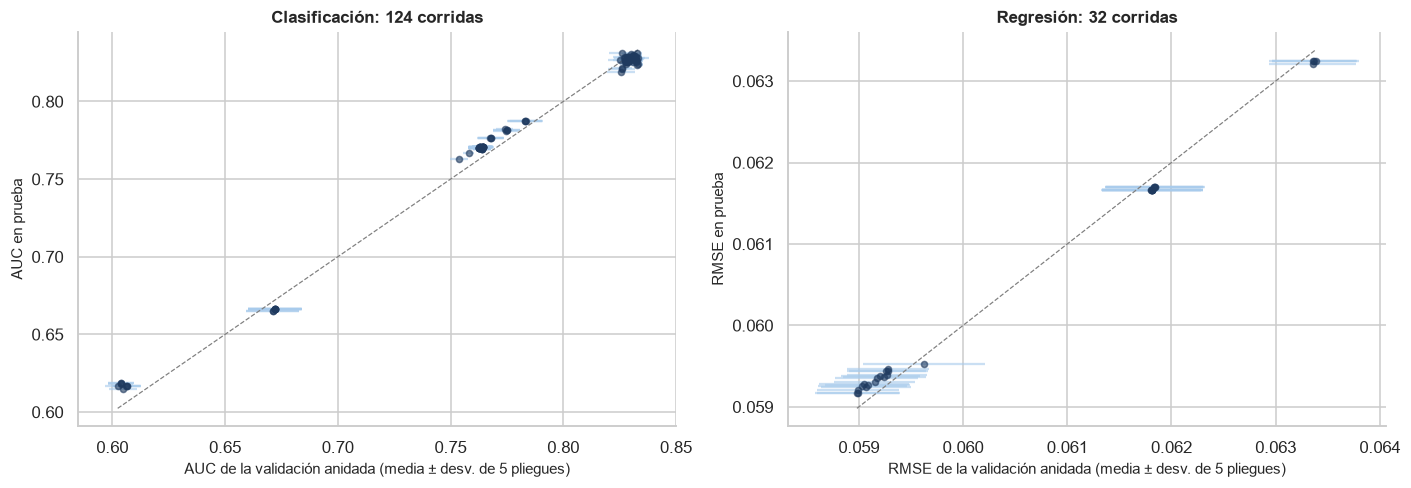


La validación anidada predice muy bien el desempeño en prueba: la correlación entre el AUC externo y el
de prueba es 0,9968 sobre 124 corridas de clasificación, con una
diferencia media de +0,0016; en regresión, la diferencia media de RMSE es
+0,00001. No hay optimismo que corregir: la separación estricta entre la
búsqueda de hiperparámetros (bucle interno) y la estimación (bucle externo) cumplió su función.


In [78]:
todas = metricas.copy()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for a, (t, col, nombre) in zip(ax, (('clasificacion', 'auc', 'AUC'), ('regresion', 'rmse', 'RMSE'))):
    sub = todas[todas['tarea'] == t]
    a.errorbar(sub['metrica_cv'], sub[col], xerr=sub['desv_cv'], fmt='o', ms=4, alpha=0.6, color=graficos.AZUL,
               ecolor='#a8cbec')
    lim = [min(sub['metrica_cv'].min(), sub[col].min()), max(sub['metrica_cv'].max(), sub[col].max())]
    a.plot(lim, lim, ls='--', color='grey', lw=0.8)
    a.set_xlabel(f'{nombre} de la validación anidada (media ± desv. de 5 pliegues)')
    a.set_ylabel(f'{nombre} en prueba')
    a.set_title(f'{graficos.NOMBRE_TAREA[t]}: {len(sub)} corridas')
plt.tight_layout()
plt.show()
sub_c = todas[todas['tarea'] == 'clasificacion']
sub_r = todas[todas['tarea'] == 'regresion']
display(Markdown(f"""
La validación anidada predice muy bien el desempeño en prueba: la correlación entre el AUC externo y el
de prueba es {dec(sub_c[['metrica_cv', 'auc']].corr().iloc[0, 1], 4)} sobre {len(sub_c)} corridas de clasificación, con una
diferencia media de {dec((sub_c['auc'] - sub_c['metrica_cv']).mean(), 4, True)}; en regresión, la diferencia media de RMSE es
{dec((sub_r['rmse'] - sub_r['metrica_cv']).mean(), 5, True)}. No hay optimismo que corregir: la separación estricta entre la
búsqueda de hiperparámetros (bucle interno) y la estimación (bucle externo) cumplió su función.
"""))

### Sensibilidad a las semillas

Se reentrenan los modelos finales de Random Forest, XGBoost, SVM y la EBM con distintas semillas (la
del modelo y, si lo hay, la del muestreador; los datos no cambian), y se repite la búsqueda del árbol de
decisión con cinco semillas de cada optimizador estocástico.

In [79]:
if (COMPLEMENTOS / 'semillas.csv').exists():
    sem = pd.read_csv(COMPLEMENTOS / 'semillas.csv')
    sem['modelo'] = sem['modelo'].map(NOMBRES_MODELO)
    resumen_sem = sem.groupby(['tarea', 'modelo']).agg(
        semillas=('semilla', 'size'), auc_media=('auc', 'mean'), auc_desv=('auc', 'std'),
        rmse_media=('rmse', 'mean'), rmse_desv=('rmse', 'std'))
    display(resumen_sem)
    sc = resumen_sem.xs('clasificacion')
    brecha = m_clf['auc'].sort_values(ascending=False)
    display(Markdown(f"""
La desviación del AUC de prueba entre semillas es de {dec(sc['auc_desv'].min(), 4)} a {dec(sc['auc_desv'].max(), 4)}.
{('El SVM lineal no cambia con la semilla: su solucionador primal es determinista. ' if (sc.loc['SVM lineal', 'auc_desv'] if 'SVM lineal' in sc.index else 1) < 1e-9 else '')}La diferencia entre
los dos mejores modelos en prueba ({brecha.index[0]} y {brecha.index[1]}) es de {dec(brecha.iloc[0] - brecha.iloc[1], 4)}:
{'del mismo orden que la variabilidad por semilla, así que no es una diferencia que deba guiar la elección' if brecha.iloc[0] - brecha.iloc[1] < 3 * sc['auc_desv'].max() else 'mayor que la variabilidad por semilla'}.
"""))
else:
    pendiente('semillas.csv')

semillas  auc_media  auc_desv  rmse_media  \
tarea         modelo                                                     
clasificacion EBM                   5     0.8288    0.0000         NaN   
              Random Forest         5     0.8281    0.0010         NaN   
              SVM lineal           10     0.7706    0.0000         NaN   
              XGBoost              10     0.8282    0.0003         NaN   
regresion     EBM                   5        NaN       NaN      0.0593   
              Random Forest         5        NaN       NaN      0.0593   
              XGBoost              10        NaN       NaN      0.0592   

                             rmse_desv  
tarea         modelo                    
clasificacion EBM                  NaN  
              Random Forest        NaN  
              SVM lineal           NaN  
              XGBoost              NaN  
regresion     EBM               0.0000  
              Random Forest     0.0000  
              XGBoost           0.0000


La desviación del AUC de prueba entre semillas es de 0,0000 a 0,0010.
El SVM lineal no cambia con la semilla: su solucionador primal es determinista. La diferencia entre
los dos mejores modelos en prueba (EBM y XGBoost) es de 0,0006:
del mismo orden que la variabilidad por semilla, así que no es una diferencia que deba guiar la elección.


In [80]:
if (COMPLEMENTOS / 'semillas_optimizadores.csv').exists():
    so = pd.read_csv(COMPLEMENTOS / 'semillas_optimizadores.csv')
    r_so = so.groupby('optimizador').agg(interno_media=('mejor_interno', 'mean'), interno_desv=('mejor_interno', 'std'),
                                          prueba_media=('auc_prueba', 'mean'), prueba_desv=('auc_prueba', 'std'),
                                          segundos=('tiempo_s', 'mean')).reindex(['random', 'bayesiana', 'genetica'])
    display(r_so)
    display(Markdown(f"""
Con el mismo árbol de decisión y los mismos pliegues internos, la semilla del optimizador mueve el AUC
de prueba con una desviación de {dec(r_so.loc['random', 'prueba_desv'], 4)} en Random,
{dec(r_so.loc['bayesiana', 'prueba_desv'], 4)} en la bayesiana y {dec(r_so.loc['genetica', 'prueba_desv'], 4)} en la genética: la
elección de hiperparámetros tiene una componente aleatoria del mismo orden que las diferencias entre
métodos de la sección de optimizadores, lo que refuerza la conclusión de que los métodos terminan
empatados en la métrica final.
"""))
else:
    pendiente('semillas_optimizadores.csv')

,interno_media,interno_desv,prueba_media,prueba_desv,segundos
optimizador,,,,,
random,0.8328,0.0005,0.8252,0.0025,31.2188
bayesiana,0.8329,0.0002,0.8246,0.0022,47.3878
genetica,0.8329,0.0001,0.8243,0.0009,49.4224



Con el mismo árbol de decisión y los mismos pliegues internos, la semilla del optimizador mueve el AUC
de prueba con una desviación de 0,0025 en Random,
0,0022 en la bayesiana y 0,0009 en la genética: la
elección de hiperparámetros tiene una componente aleatoria del mismo orden que las diferencias entre
métodos de la sección de optimizadores, lo que refuerza la conclusión de que los métodos terminan
empatados en la métrica final.


# Interpretabilidad: SHAP, LIME y las funciones de forma de la EBM

La guía (§5.3) pide explicar el mejor modelo de cada tarea con SHAP —una vista global y al menos dos
explicaciones individuales, una bien predicha y otra con error alto—, aplicar LIME a XGBoost y
discutir en qué se diferencian. El mejor modelo de las dos tareas según la validación anidada es
**XGBoost**, de modo que es el que se explica aquí; el modelo nuevo, la EBM, sirve de contraste
porque es interpretable por construcción.

**SHAP** (Lundberg y Lee, 2017) reparte la predicción de cada cliente entre las variables con los
valores de Shapley de la teoría de juegos cooperativos: la contribución de una variable es su aporte
marginal promedio sobre todas las coaliciones posibles de variables. Es el único reparto que cumple a
la vez cuatro propiedades: **eficiencia** (las contribuciones suman la diferencia entre la predicción y
su media), **simetría** (dos variables que aportan lo mismo en toda coalición reciben lo mismo),
**jugador nulo** (una variable que no cambia ninguna predicción recibe cero) y **aditividad** (en un
ensamble, la contribución es la suma de las de sus partes). Para árboles, TreeSHAP los calcula de
forma **exacta** y en tiempo polinómico, y las contribuciones suman exactamente la diferencia entre
la predicción del cliente y la predicción media (en clasificación, en la escala del logit).
**LIME** (Ribeiro, Singh y Guestrin, 2016) ajusta, alrededor de cada cliente, un modelo lineal a
las predicciones del modelo sobre perturbaciones de ese cliente: es una aproximación local, no una
descomposición exacta.

In [81]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import Markdown, display
from lime.lime_tabular import LimeTabularExplainer

from src import analisis, datos, graficos
from src.formato import dec, ent, enumerar, pct
from src.preprocesamiento import columnas_por_tipo, nombres_variables

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

tabla = analisis.cargar_tabla()
p = datos.preparar_todo()                                 # etiqueta del percentil 75
c = p['conjuntos']
X_te = c.X_test.sort_index()
y_te, y_te_c = p['y_test'].loc[X_te.index], c.y_test_cont.loc[X_te.index]
mejor = {t: analisis.mejores_por_modelo(tabla, t).iloc[0] for t in ('clasificacion', 'regresion')}
modelo = {t: joblib.load(f['ruta_modelo']) for t, f in mejor.items()}
for t, f in mejor.items():
    print(f'{t}: {f["modelo"]} · {f["balanceo"]} · {f["optimizador"]} · métrica externa {f["metrica"]:.4f}')


def matrices(pipeline, X):
    """Matriz transformada (lo que ve el modelo) y matriz para mostrar en unidades originales."""
    pre = pipeline.named_steps['preprocesado']
    nombres = nombres_variables(pre)
    Z = pre.transform(X)
    numericas, _ = columnas_por_tipo(X)
    mostrar = Z.copy()
    mostrar[:, :len(numericas)] = X[numericas].astype(float).to_numpy()
    return Z, mostrar, nombres

clasificacion: xgboost · class_weight · genetica · métrica externa 0.8332
regresion: xgboost · ninguno · bayesiana · métrica externa 0.0590


## Clasificación: vista global

El gráfico de enjambre ordena las variables por la media del valor absoluto de su contribución.
Cada punto es un cliente de prueba; su posición horizontal es la contribución de la variable a su
logit de riesgo alto y su color, el valor de la variable (rojo alto, azul bajo).

las contribuciones suman el margen del modelo en todos los clientes: True


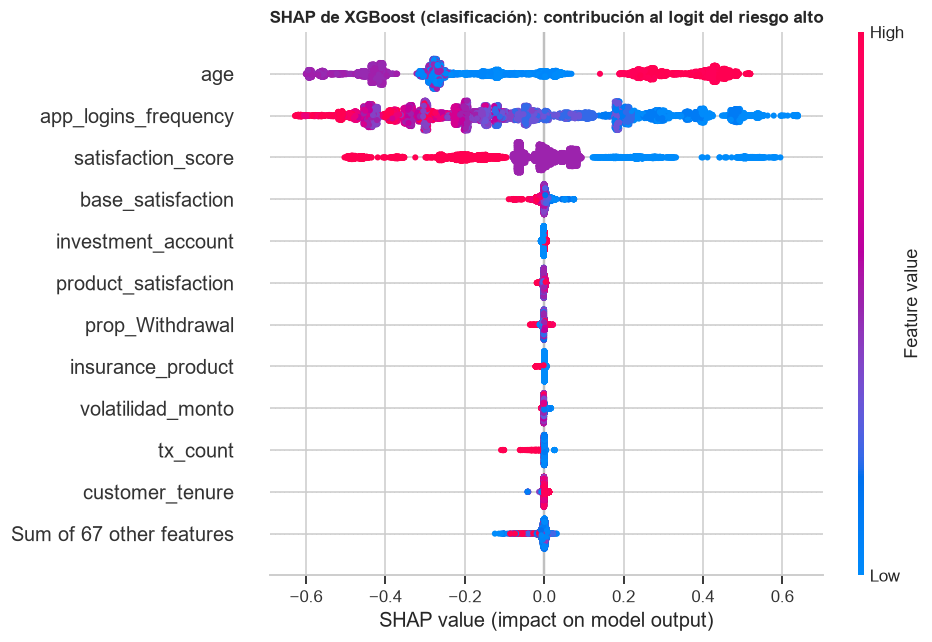

In [82]:
Z_clf, mostrar_clf, nombres = matrices(modelo['clasificacion'], X_te)
xgb_clf = modelo['clasificacion'].named_steps['modelo']
explicador = shap.TreeExplainer(xgb_clf)
sv = explicador(Z_clf)
sv = shap.Explanation(sv.values, base_values=sv.base_values, data=mostrar_clf, feature_names=nombres)
margen = xgb_clf.predict(Z_clf, output_margin=True)
print('las contribuciones suman el margen del modelo en todos los clientes:',
      bool(np.allclose(sv.values.sum(axis=1) + sv.base_values, margen, atol=1e-4)))
shap.plots.beeswarm(sv, max_display=12, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title('SHAP de XGBoost (clasificación): contribución al logit del riesgo alto', fontsize=11)
plt.tight_layout()
plt.show()

In [83]:
importancia = pd.Series(np.abs(sv.values).mean(axis=0), index=nombres).sort_values(ascending=False)
cuota = importancia / importancia.sum()
top4 = list(cuota.index[:4])
display(cuota.head(10).to_frame('cuota del |SHAP| medio'))
display(Markdown(f"""
Cuatro variables concentran el {pct(cuota.iloc[:4].sum(), 0)} de la contribución total:
{enumerar(f'`{v}` ({pct(cuota[v], 0)})' for v in top4)}. Es el mismo grupo que señalaron el análisis de
variables y la EBM, aunque llegan a él por caminos distintos. Más inicios de sesión en la aplicación
y más satisfacción reducen el riesgo; la edad tiene un efecto por tramos que la EBM muestra con más
detalle al final de esta página.
"""))

,cuota del |SHAP| medio
age,0.4320
app_logins_frequency,0.3615
satisfaction_score,0.1617
base_satisfaction,0.0105
investment_account,0.0025
product_satisfaction,0.0025
prop_Withdrawal,0.0024
insurance_product,0.0020
volatilidad_monto,0.0020
tx_count,0.0019



Cuatro variables concentran el 97 % de la contribución total:
`age` (43 %), `app_logins_frequency` (36 %), `satisfaction_score` (16 %) y `base_satisfaction` (1 %). Es el mismo grupo que señalaron el análisis de
variables y la EBM, aunque llegan a él por caminos distintos. Más inicios de sesión en la aplicación
y más satisfacción reducen el riesgo; la edad tiene un efecto por tramos que la EBM muestra con más
detalle al final de esta página.


## Clasificación: dos clientes

Se explican dos clientes de prueba que son de riesgo alto: el que el modelo identifica con más
seguridad (bien predicho) y el que el modelo considera de menor riesgo (el error más grave: un
cliente que se va y que el modelo deja fuera de cualquier campaña).

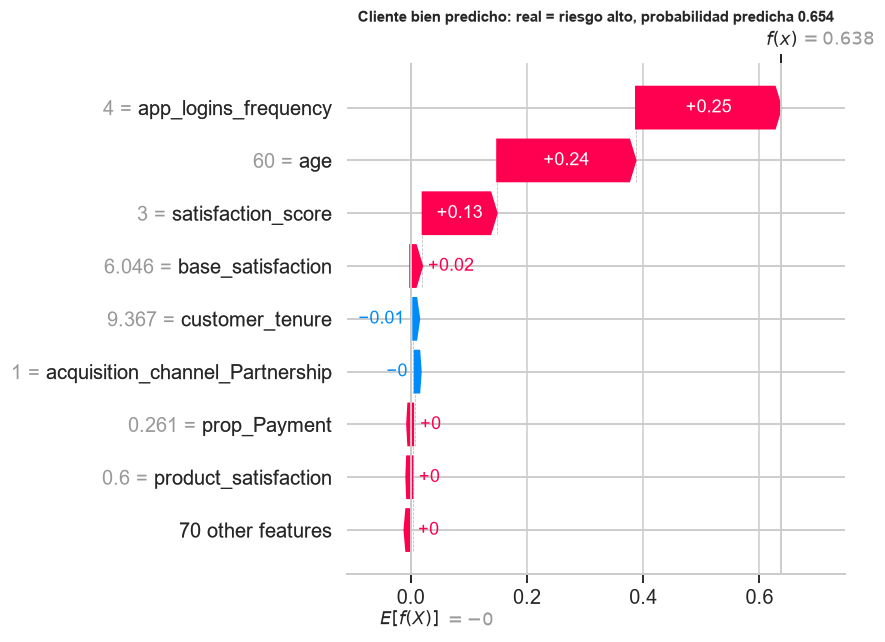

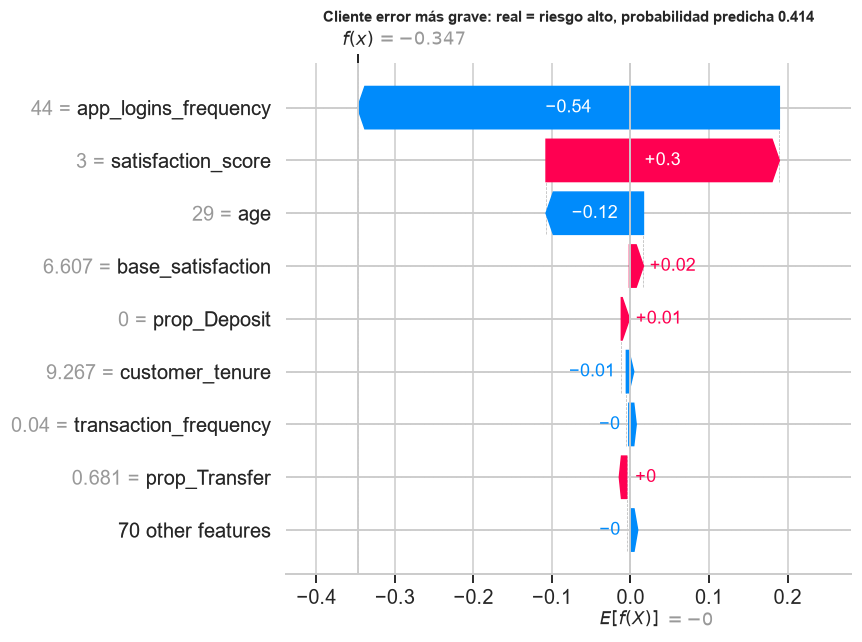

In [84]:
proba = modelo['clasificacion'].predict_proba(X_te)[:, 1]
positivos = np.flatnonzero(y_te.to_numpy() == 1)
bien = positivos[np.argmax(proba[positivos])]
mal = positivos[np.argmin(proba[positivos])]
for idx, titulo in ((bien, 'bien predicho'), (mal, 'error más grave')):
    plt.figure(figsize=(8.5, 4.6))
    shap.plots.waterfall(sv[idx], max_display=9, show=False)
    plt.title(f'Cliente {titulo}: real = riesgo alto, probabilidad predicha {proba[idx]:.3f}', fontsize=10)
    plt.tight_layout()
    plt.show()

## Regresión

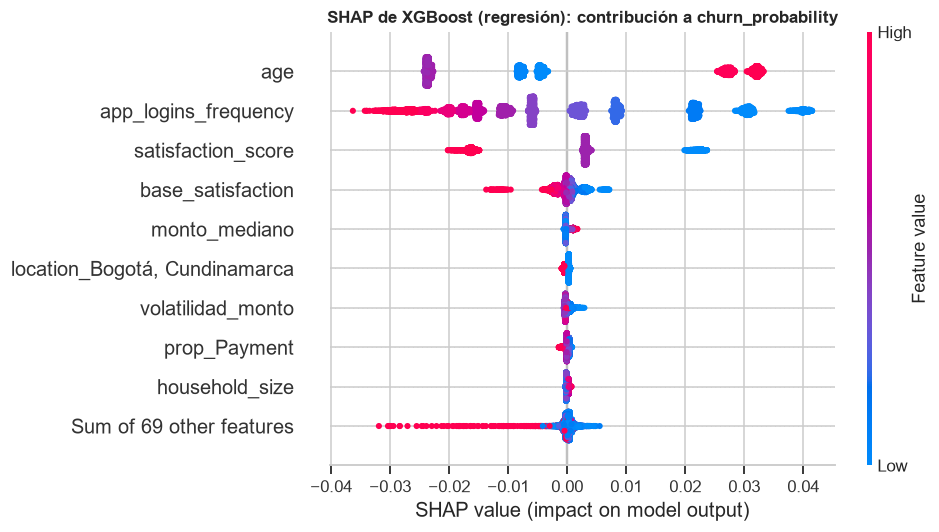

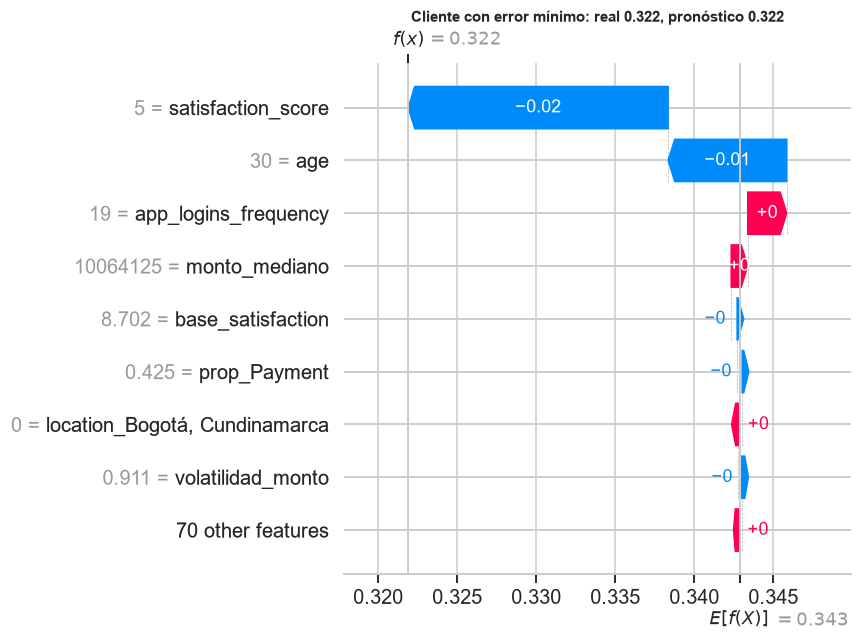

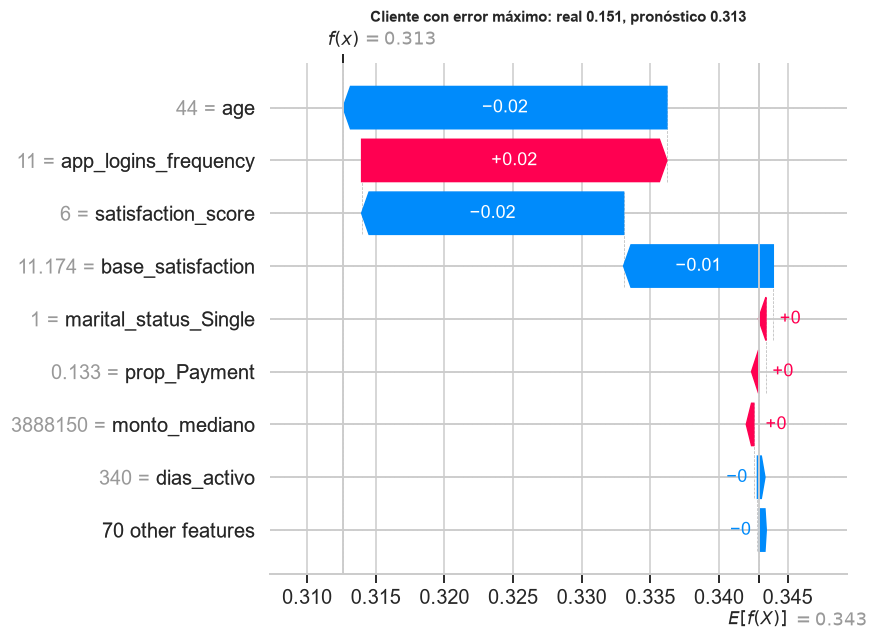

In [85]:
Z_reg, mostrar_reg, nombres_r = matrices(modelo['regresion'], X_te)
xgb_reg = modelo['regresion'].named_steps['modelo']
sv_r = shap.TreeExplainer(xgb_reg)(Z_reg)
sv_r = shap.Explanation(sv_r.values, base_values=sv_r.base_values, data=mostrar_reg, feature_names=nombres_r)
pron = modelo['regresion'].predict(X_te)
error = np.abs(y_te_c.to_numpy() - pron)
bien_r, mal_r = int(np.argmin(error)), int(np.argmax(error))
shap.plots.beeswarm(sv_r, max_display=10, show=False)
plt.gcf().set_size_inches(9, 5)
plt.title('SHAP de XGBoost (regresión): contribución a churn_probability', fontsize=11)
plt.tight_layout()
plt.show()
for idx, titulo in ((bien_r, 'error mínimo'), (mal_r, 'error máximo')):
    plt.figure(figsize=(8.5, 4.6))
    shap.plots.waterfall(sv_r[idx], max_display=9, show=False)
    plt.title(f'Cliente con {titulo}: real {y_te_c.iloc[idx]:.3f}, pronóstico {pron[idx]:.3f}', fontsize=10)
    plt.tight_layout()
    plt.show()

In [86]:
cuota_r = pd.Series(np.abs(sv_r.values).mean(axis=0), index=nombres_r)
cuota_r = (cuota_r / cuota_r.sum()).sort_values(ascending=False)
display(Markdown(f"""
En regresión el orden es parecido: {enumerar(f'`{v}`' for v in cuota_r.index[:4])} reúnen el
{pct(cuota_r.iloc[:4].sum(), 0)} de la contribución. El cliente con el error más grande tiene un valor real de
{dec(y_te_c.iloc[mal_r], 3)} y el modelo pronostica {dec(pron[mal_r], 3)}: sus variables observables lo parecen a
los clientes de riesgo medio, y la diferencia la explica `active_products`, que el modelo no puede
ver. Ese es el límite del techo de información: los errores grandes no son fallos del modelo sino
la parte del objetivo que depende de una variable excluida.
"""))


En regresión el orden es parecido: `age`, `app_logins_frequency`, `satisfaction_score` y `base_satisfaction` reúnen el
93 % de la contribución. El cliente con el error más grande tiene un valor real de
0,151 y el modelo pronostica 0,313: sus variables observables lo parecen a
los clientes de riesgo medio, y la diferencia la explica `active_products`, que el modelo no puede
ver. Ese es el límite del techo de información: los errores grandes no son fallos del modelo sino
la parte del objetivo que depende de una variable excluida.


## LIME sobre XGBoost y comparación con SHAP

LIME explica a los mismos dos clientes de clasificación. Como su explicación depende de
perturbaciones aleatorias, se repite con varias semillas para medir su estabilidad.

In [87]:
rng = np.random.default_rng(42)
muestra = rng.choice(len(c.X_train), 5000, replace=False)
Z_tr = modelo['clasificacion'].named_steps['preprocesado'].transform(c.X_train.iloc[muestra])
lime_exp = LimeTabularExplainer(Z_tr, feature_names=nombres, class_names=['bajo', 'alto'],
                                mode='classification', discretize_continuous=True, random_state=42)


def explicar_lime(idx, semilla, n=8):
    e = LimeTabularExplainer(Z_tr, feature_names=nombres, class_names=['bajo', 'alto'], mode='classification',
                             discretize_continuous=True, random_state=semilla)
    return e.explain_instance(Z_clf[idx], xgb_clf.predict_proba, num_features=n, num_samples=5000)


filas = []
for idx, nombre_caso in ((bien, 'bien predicho'), (mal, 'error más grave')):
    exp = explicar_lime(idx, 42)
    top_shap = pd.Series(np.abs(sv.values[idx]), index=nombres).sort_values(ascending=False).index[:5]
    top_lime = [nombres[j] for j, _ in exp.as_map()[1][:5]]
    tops = [set(nombres[j] for j, _ in explicar_lime(idx, s).as_map()[1][:5]) for s in range(5)]
    estabilidad = np.mean([len(a & b) / 5 for i, a in enumerate(tops) for b in tops[i + 1:]])
    filas.append({'cliente': nombre_caso, '5 primeras según SHAP': ', '.join(top_shap),
                  '5 primeras según LIME': ', '.join(top_lime),
                  'coincidencias SHAP–LIME (de 5)': len(set(top_shap) & set(top_lime)),
                  'estabilidad de LIME entre 5 semillas': estabilidad,
                  'R² del modelo local de LIME': exp.score})
comparacion_lime = pd.DataFrame(filas).set_index('cliente')
comparacion_lime

,5 primeras según SHAP,5 primeras según LIME,coincidencias SHAP–LIME (de 5),estabilidad de LIME entre 5 semillas,R² del modelo local de LIME
cliente,,,,,
bien predicho,"app_logins_frequency, age, satisfaction_score,...","satisfaction_score, age, app_logins_frequency,...",3,0.6400,0.4363
error más grave,"app_logins_frequency, satisfaction_score, age,...","satisfaction_score, app_logins_frequency, loca...",2,0.5200,0.4067


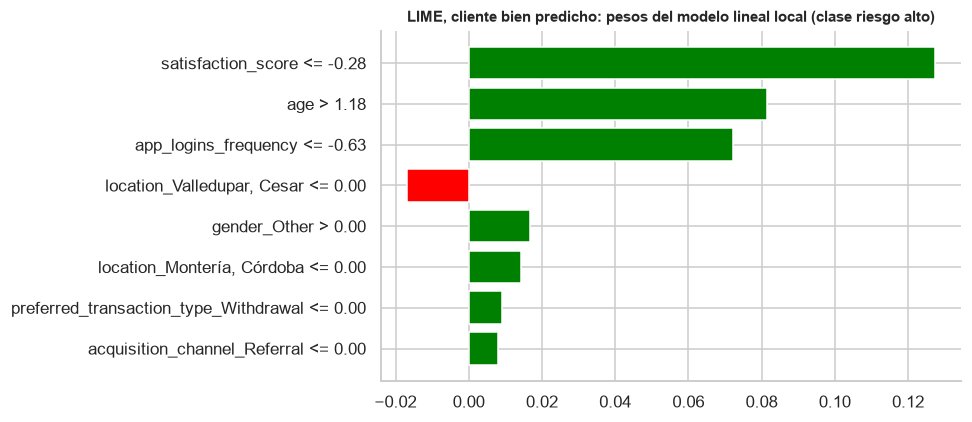

In [88]:
fig = explicar_lime(bien, 42).as_pyplot_figure()
fig.set_size_inches(9, 4)
plt.title('LIME, cliente bien predicho: pesos del modelo lineal local (clase riesgo alto)', fontsize=10)
plt.tight_layout()
plt.show()

In [89]:
cl = comparacion_lime
display(Markdown(f"""
**LIME frente a SHAP.** Para el cliente bien predicho, {cl.iloc[0]['coincidencias SHAP–LIME (de 5)']} de las 5 variables
más importantes coinciden entre los dos métodos, y {cl.iloc[1]['coincidencias SHAP–LIME (de 5)']} para el cliente mal
predicho. Las diferencias se deben a lo que cada método mide:

- SHAP descompone *exactamente* la predicción del modelo (las contribuciones suman el logit del
  cliente) y, para árboles, sin muestreo: el resultado es único y reproducible.
- LIME ajusta un modelo lineal sobre perturbaciones alrededor del cliente, con las variables
  continuas discretizadas en cuartiles: sus pesos describen cómo cambia la predicción al mover cada
  variable de cuartil, y dependen del muestreo. Con 5.000 perturbaciones, las 5 variables principales
  coinciden en promedio en un {pct(cl['estabilidad de LIME entre 5 semillas'].mean(), 0)} entre semillas distintas, y el
  modelo lineal local explica un R² de {dec(cl['R² del modelo local de LIME'].min(), 2)} a {dec(cl['R² del modelo local de LIME'].max(), 2)} de las
  predicciones perturbadas: la aproximación es local y parcial.
- LIME trata las indicadoras de las variables categóricas como variables independientes y puede
  perturbarlas a combinaciones imposibles; SHAP, con TreeExplainer, solo recorre caminos que existen
  en los árboles.

En la práctica, SHAP sirve para auditar el modelo y para reportar por qué se marca a un cliente;
LIME, para una explicación rápida de un caso con un modelo de caja negra cualquiera, sabiendo que es
una aproximación.
"""))


**LIME frente a SHAP.** Para el cliente bien predicho, 3 de las 5 variables
más importantes coinciden entre los dos métodos, y 2 para el cliente mal
predicho. Las diferencias se deben a lo que cada método mide:

- SHAP descompone *exactamente* la predicción del modelo (las contribuciones suman el logit del
  cliente) y, para árboles, sin muestreo: el resultado es único y reproducible.
- LIME ajusta un modelo lineal sobre perturbaciones alrededor del cliente, con las variables
  continuas discretizadas en cuartiles: sus pesos describen cómo cambia la predicción al mover cada
  variable de cuartil, y dependen del muestreo. Con 5.000 perturbaciones, las 5 variables principales
  coinciden en promedio en un 58 % entre semillas distintas, y el
  modelo lineal local explica un R² de 0,41 a 0,44 de las
  predicciones perturbadas: la aproximación es local y parcial.
- LIME trata las indicadoras de las variables categóricas como variables independientes y puede
  perturbarlas a combinaciones imposibles; SHAP, con TreeExplainer, solo recorre caminos que existen
  en los árboles.

En la práctica, SHAP sirve para auditar el modelo y para reportar por qué se marca a un cliente;
LIME, para una explicación rápida de un caso con un modelo de caja negra cualquiera, sabiendo que es
una aproximación.


## La EBM como contraste: explicaciones sin modelo auxiliar

La EBM no necesita un explicador: su predicción *es* la suma de sus funciones de forma. Si SHAP
describe bien a XGBoost, la dependencia de los valores SHAP de una variable con su valor debería
parecerse a la función de forma de la EBM para esa variable.

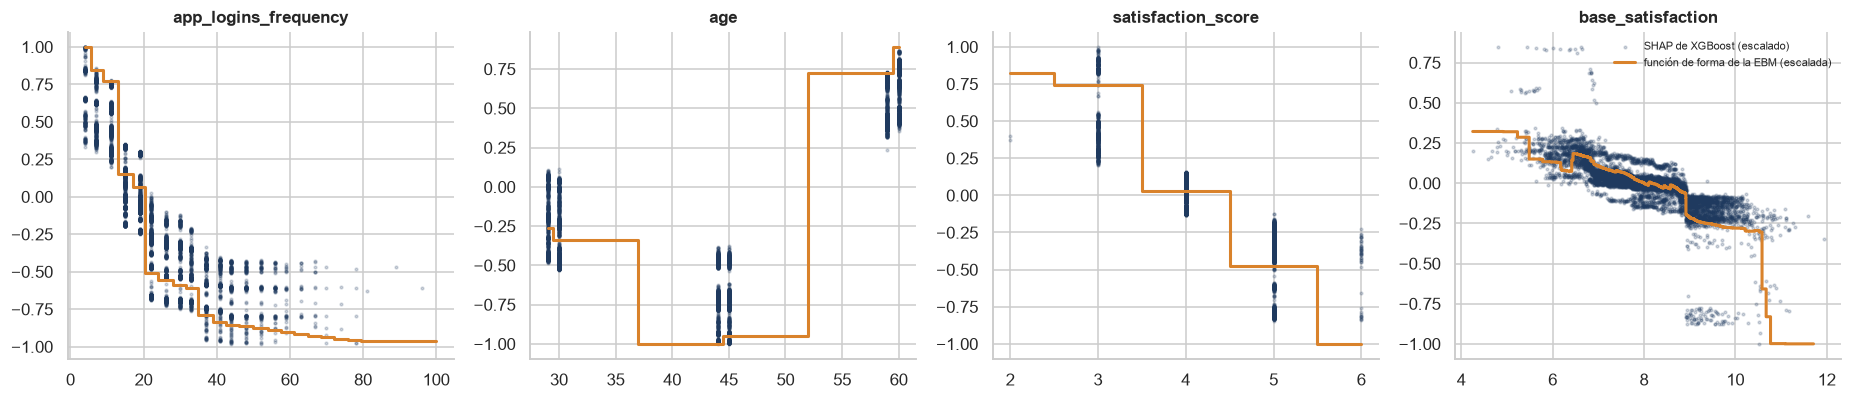


Las curvas se muestran escaladas a su máximo porque lo que interesa comparar es la forma, no la
magnitud: XGBoost se explica en la escala de su propio logit y la EBM usada es la mejor EBM de las corridas, con la misma etiqueta del percentil 75. Coinciden en la dirección y en los
tramos donde el efecto cambia: SHAP sobre XGBoost recupera la misma estructura que la EBM ofrece
directamente. Para este problema, la EBM da la explicación global sin coste adicional y con la misma
capacidad predictiva, y SHAP queda como herramienta para explicar casos individuales de modelos de
caja negra.


In [90]:
ebm = tabla[(tabla['modelo'] == 'ebm') & (tabla['tarea'] == 'clasificacion') & (tabla['estado'] == 'ok')]
if ebm.empty:
    from pathlib import Path as _P
    ruta_ebm = RAIZ / 'resultados' / 'comparacion_entrega2' / 'modelos' / 'clasificacion__ebm.joblib'
    origen = 'la EBM con la etiqueta de la mediana, la de la comparación con la Entrega 2'
else:
    ruta_ebm = analisis.mejores_por_modelo(tabla, 'clasificacion').set_index('modelo').loc['ebm', 'ruta_modelo']
    origen = 'la mejor EBM de las corridas, con la misma etiqueta del percentil 75'
ebm_modelo = joblib.load(ruta_ebm)
variables = ['app_logins_frequency', 'age', 'satisfaction_score', 'base_satisfaction']
fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a, v in zip(ax, variables):
    j = nombres.index(v)
    a.scatter(mostrar_clf[:, j], sv.values[:, j] / np.abs(sv.values[:, j]).max(), s=3, alpha=0.2,
              color=graficos.AZUL, label='SHAP de XGBoost (escalado)')
    f = analisis.forma_ebm(ebm_modelo, v)
    x = np.r_[f['desde'].iloc[0], f['hasta']]
    escala = np.abs(f['efecto']).max()
    a.step(x, np.r_[f['efecto'], f['efecto'].iloc[-1]] / escala, where='post', color='#d9822b', lw=2,
           label='función de forma de la EBM (escalada)')
    a.set_title(v)
ax[-1].legend(frameon=False, fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()
display(Markdown(f"""
Las curvas se muestran escaladas a su máximo porque lo que interesa comparar es la forma, no la
magnitud: XGBoost se explica en la escala de su propio logit y la EBM usada es {origen}. Coinciden en la dirección y en los
tramos donde el efecto cambia: SHAP sobre XGBoost recupera la misma estructura que la EBM ofrece
directamente. Para este problema, la EBM da la explicación global sin coste adicional y con la misma
capacidad predictiva, y SHAP queda como herramienta para explicar casos individuales de modelos de
caja negra.
"""))

# El modelo nuevo frente a la Entrega 2

El profesor pidió para esta entrega un **modelo nuevo**, distinto de los de la Entrega 2 y no
explicado en clase, que **supere sus métricas**. Para que la comparación sea válida se hace sobre
la misma partición 80/20 con semilla 42, con la misma etiqueta (riesgo alto si `churn_probability`
supera su mediana, estimada solo con entrenamiento) y en la misma prueba de 9.745 clientes, y la
superación se confirma con pruebas estadísticas y no solo con la cifra puntual.

**El modelo elegido es la Explainable Boosting Machine (EBM)** de Lou, Caruana, Gehrke y Hooker
(2013), en la implementación `interpret` de Nori y otros (2019). No aparece en las notas del curso.
Es un modelo aditivo generalizado con interacciones por pares (GA²M):

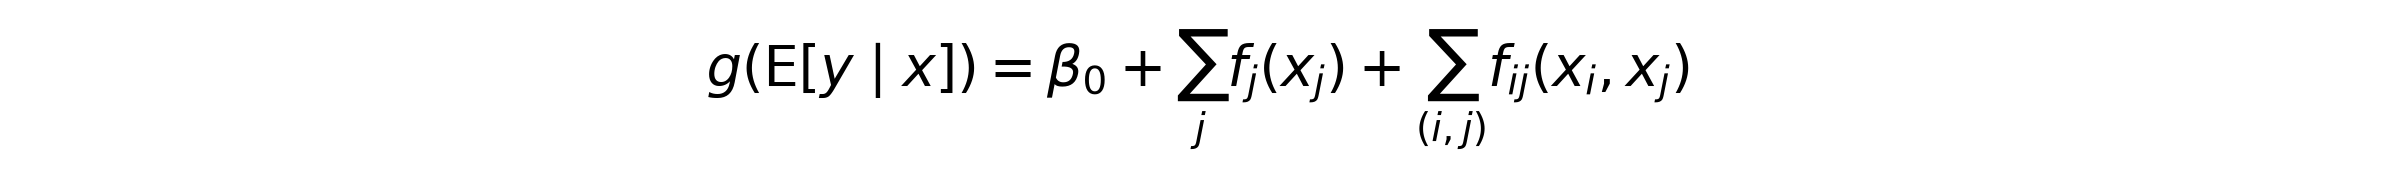

In [91]:
# Fórmula del modelo dibujada con mathtext como imagen: ancha para que ocupe la columna y a 200 ppp para
# que sea nítida; así se ve igual en cualquier visor de cuadernos, también en los que no renderizan LaTeX.
import base64, io
import matplotlib.pyplot as plt
from IPython.display import display
FORMULA = r'$g(\mathrm{E}[y \mid x]) = \beta_0 + \sum_j f_j(x_j) + \sum_{(i,j)} f_{ij}(x_i, x_j)$'
fig = plt.figure(figsize=(12, 0.9))
fig.text(0.5, 0.5, FORMULA, ha='center', va='center', fontsize=20)
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=200, facecolor='white')
plt.close(fig)
display({'image/png': base64.b64encode(buf.getvalue()).decode(),
         'text/plain': 'g(E[y|x]) = β0 + Σ_j f_j(x_j) + Σ_(i,j) f_ij(x_i, x_j)'}, raw=True)

donde cada función de forma <i>f</i><sub>j</sub> se aprende por *boosting* cíclico de árboles de pocas hojas sobre
una sola variable a la vez, con una tasa de aprendizaje baja para que el orden de las variables no
importe, y se promedia sobre varias submuestras (bolsas externas). Reúne dos cosas que no suelen ir
juntas: la flexibilidad del *boosting* para captar efectos no lineales y la legibilidad de un modelo
aditivo, en el que la contribución de cada variable es una curva que se puede graficar. Esa
combinación responde a la causa del bajo desempeño de la Entrega 2, que fue la no linealidad.

**Protocolo.** Los modelos de la Entrega 2 se reentrenan con los hiperparámetros que eligió su
`GridSearchCV` (regresión logística L1 con C = 0,1; Lasso con alpha = 1e-4). La EBM y, como
referencia, XGBoost —el mejor modelo visto en clase en las 140 corridas— se afinan con el mismo
protocolo: optimización bayesiana (Optuna, TPE) con el presupuesto de las 140 corridas y validación
cruzada de 5 pliegues sobre el entrenamiento (los mismos 5 pliegues de la Entrega 2), y reajuste
final sobre todo el entrenamiento. Cada modelo toca la prueba una sola vez. El cálculo lo hace
`comparar_entrega2.py`, y aquí se cargan sus modelos y predicciones para repetir los contrastes.

In [92]:
import json
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, comparacion, datos, graficos
from src import estadistica as est
from src.formato import dec, ent, enumerar, intervalo, p_valor, pct
from src.preprocesamiento import nombres_variables

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

CARPETA = RAIZ / 'resultados' / 'comparacion_entrega2'
busquedas = json.loads((CARPETA / 'busquedas.json').read_text(encoding='utf-8'))
pred = pd.read_parquet(CARPETA / 'predicciones.parquet')
modelos_cmp = {k: joblib.load(CARPETA / 'modelos' / f'{k.replace("/", "__")}.joblib') for k in busquedas['modelos']}
NOMBRE = {'logistica_e2': 'Logística L1 (Entrega 2)', 'lasso_e2': 'Lasso (Entrega 2)',
          'xgboost': 'XGBoost (clase)', 'ebm': 'EBM (modelo nuevo)'}
p_med = datos.preparar_todo(metodo_etiqueta='mediana')      # misma partición y etiqueta de la Entrega 2
c = p_med['conjuntos']
assert c.X_test.index.sort_values().equals(pred.index), 'las predicciones no corresponden a esta prueba'
print(f'entrenamiento: {ent(busquedas["n_train"])} clientes · prueba: {ent(busquedas["n_test"])} · '
      f'umbral de la mediana (solo entrenamiento): {busquedas["etiqueta"]["umbral"]:.6f} · '
      f'riesgo alto en prueba: {pred["y_bin"].mean():.2%}')

entrenamiento: 38.978 clientes · prueba: 9.745 · umbral de la mediana (solo entrenamiento): 0.353972 · riesgo alto en prueba: 49.91%


## 1. La Entrega 2 se reproduce exactamente

Antes de comparar hay que asegurarse de que el punto de partida es el mismo: los modelos de la
Entrega 2, reentrenados con este código, deben dar las cifras de prueba que se publicaron.

In [93]:
filas = []
for tarea, nombre in (('clasificacion', 'logistica_e2'), ('regresion', 'lasso_e2')):
    for metrica, v in busquedas['modelos'][f'{tarea}/{nombre}']['reproduccion'].items():
        filas.append({'modelo': NOMBRE[nombre], 'métrica': metrica, 'publicado en la Entrega 2': v['publicado'],
                      'obtenido ahora': v['obtenido'], 'coincide': v['coincide']})
reproduccion = pd.DataFrame(filas)
reproduccion

,modelo,métrica,publicado en la Entrega 2,obtenido ahora,coincide
0,Logística L1 (Entrega 2),auc,0.6832,0.6832,True
1,Logística L1 (Entrega 2),recall,0.6515,0.6515,True
2,Lasso (Entrega 2),r2,0.1511,0.1511,True
3,Lasso (Entrega 2),rmse,0.0617,0.0617,True


## 2. Métricas de prueba

In [94]:
def tabla_metricas(tarea):
    filas = []
    for k, info in busquedas['modelos'].items():
        t, nombre = k.split('/')
        if t != tarea:
            continue
        filas.append({'modelo': NOMBRE[nombre], 'papel': info['papel'], 'CV media (entrenamiento)': info['cv_media'],
                      'CV desv.': info['cv_desv'], **info['prueba']})
    return pd.DataFrame(filas).set_index('modelo')

metricas_clf = tabla_metricas('clasificacion')
metricas_reg = tabla_metricas('regresion')
display(metricas_clf)
display(metricas_reg)

,papel,CV media (entrenamiento),CV desv.,accuracy,precision,recall,f1,auc,brier
modelo,,,,,,,,,
Logística L1 (Entrega 2),Entrega 2,0.6824,0.0043,0.6360,0.6311,0.6515,0.6412,0.6832,0.2245
XGBoost (clase),mejor modelo de clase en las 140 corridas,0.7232,0.0035,0.6724,0.6845,0.6375,0.6602,0.7206,0.2069
EBM (modelo nuevo),"modelo nuevo, no visto en clase",0.7221,0.0030,0.6704,0.6745,0.6565,0.6653,0.7187,0.2096


,papel,CV media (entrenamiento),CV desv.,rmse,mae,r2
modelo,,,,,,
Lasso (Entrega 2),Entrega 2,0.0618,0.0005,0.0617,0.0507,0.1511
XGBoost (clase),mejor modelo de clase en las 140 corridas,0.0590,0.0004,0.0592,0.0471,0.2177
EBM (modelo nuevo),"modelo nuevo, no visto en clase",0.0590,0.0004,0.0593,0.0472,0.2159


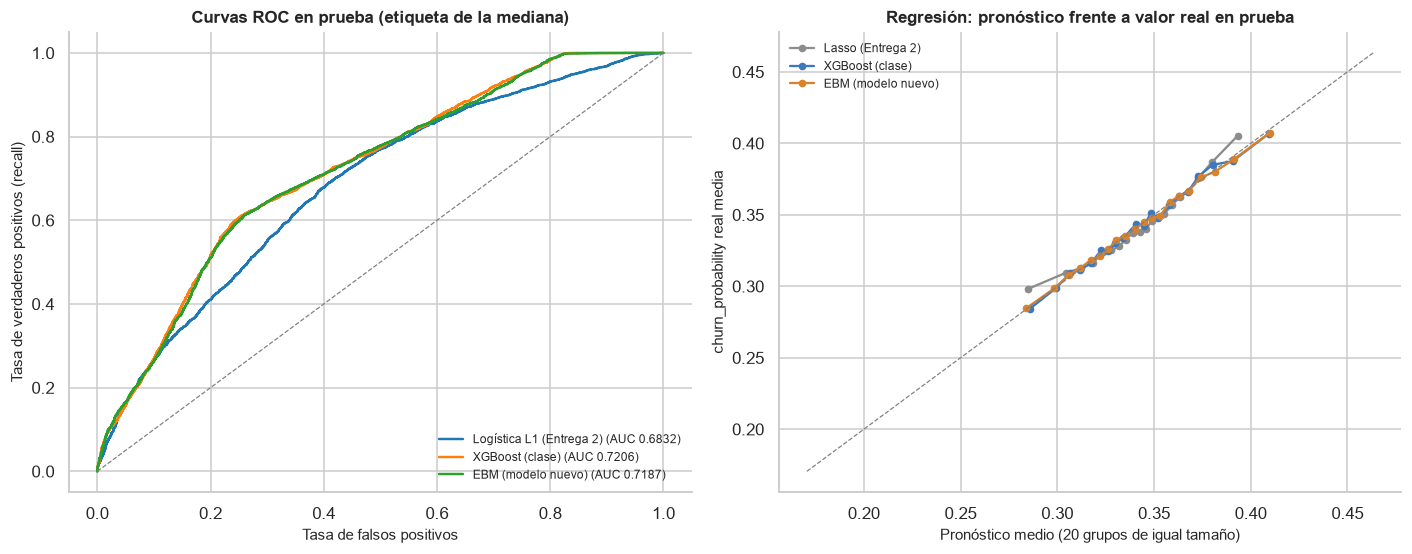

In [95]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
graficos.curvas_roc(pred['y_bin'], {NOMBRE[m]: pred[f'clf_{m}'] for m in ('logistica_e2', 'xgboost', 'ebm')},
                    ax=ax[0], titulo='Curvas ROC en prueba (etiqueta de la mediana)')
for m, color in (('lasso_e2', '#8c8c8c'), ('xgboost', '#3d78bf'), ('ebm', '#d9822b')):
    orden = np.argsort(pred[f'reg_{m}'].to_numpy())
    grupos = np.array_split(orden, 20)
    ax[1].plot([pred[f'reg_{m}'].to_numpy()[g].mean() for g in grupos],
               [pred['y_cont'].to_numpy()[g].mean() for g in grupos], marker='o', ms=4, color=color, label=NOMBRE[m])
lim = [pred['y_cont'].quantile(0.01), pred['y_cont'].quantile(0.99)]
ax[1].plot(lim, lim, ls='--', color='grey', lw=0.8)
ax[1].set_xlabel('Pronóstico medio (20 grupos de igual tamaño)')
ax[1].set_ylabel('churn_probability real media')
ax[1].set_title('Regresión: pronóstico frente a valor real en prueba')
ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 3. Clasificación: DeLong, bootstrap y delta de Cliff

Para cada pareja (referencia, candidato) se reporta la diferencia de AUC del candidato con su
intervalo de DeLong y su intervalo bootstrap BCa (2.000 réplicas estratificadas por clase), el
p-valor de DeLong, ajustado por Holm sobre las tres comparaciones, y el delta de Cliff entre los AUC
de los 5 pliegues de validación cruzada del entrenamiento (+1: el candidato gana en todos).

In [96]:
puntajes = {m: pred[f'clf_{m}'].to_numpy() for m in ('logistica_e2', 'xgboost', 'ebm')}
pliegues_auc = {m: busquedas['modelos'][f'clasificacion/{m}']['pliegues'] for m in puntajes}
pares = [('logistica_e2', 'ebm'), ('logistica_e2', 'xgboost'), ('xgboost', 'ebm')]
contraste_clf = comparacion.contrastar_clasificacion(pred['y_bin'], puntajes, pares, pliegues_auc)
contraste_clf.assign(referencia=contraste_clf['referencia'].map(NOMBRE),
                     candidato=contraste_clf['candidato'].map(NOMBRE))[
    ['referencia', 'candidato', 'auc_referencia', 'auc_candidato', 'diferencia', 'ic_delong_inf', 'ic_delong_sup',
     'ic_bca_inf', 'ic_bca_sup', 'z', 'p_delong', 'p_delong_ajustado', 'correlacion_auc', 'delta_cliff']]

,referencia,candidato,auc_referencia,auc_candidato,diferencia,ic_delong_inf,ic_delong_sup,ic_bca_inf,ic_bca_sup,z,p_delong,p_delong_ajustado,correlacion_auc,delta_cliff
0,Logística L1 (Entrega 2),EBM (modelo nuevo),0.6832,0.7187,0.0355,0.0278,0.0432,0.0281,0.0434,9.0182,0.0000,0.0000,0.7177,1.0000
1,Logística L1 (Entrega 2),XGBoost (clase),0.6832,0.7206,0.0374,0.0301,0.0447,0.0303,0.0449,10.0609,0.0000,0.0000,0.7473,1.0000
2,XGBoost (clase),EBM (modelo nuevo),0.7206,0.7187,-0.0019,-0.0049,0.0010,-0.0051,0.0009,-1.2936,0.1958,0.1958,0.9569,-0.1200


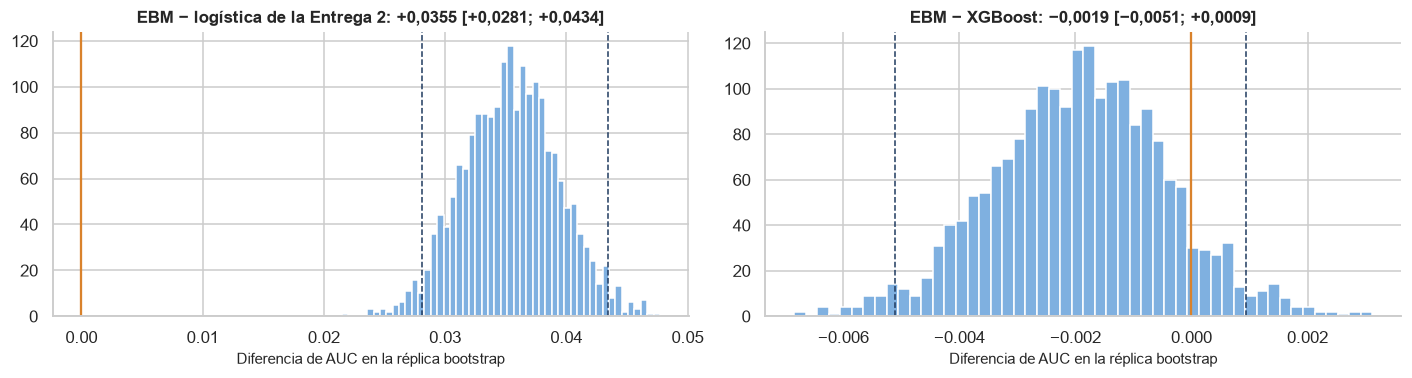

In [97]:
boot = est.bootstrap_auc(pred['y_bin'], puntajes['logistica_e2'], puntajes['ebm'])
boot_x = est.bootstrap_auc(pred['y_bin'], puntajes['xgboost'], puntajes['ebm'])
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, b, titulo in ((ax[0], boot, 'EBM − logística de la Entrega 2'), (ax[1], boot_x, 'EBM − XGBoost')):
    a.hist(b['replicas'], bins=50, color='#7fb0e0', edgecolor='white')
    for v in b['ic_bca']:
        a.axvline(v, color=graficos.AZUL, ls='--', lw=1)
    a.axvline(0, color='#d9822b', lw=1.5)
    a.set_title(f'{titulo}: {dec(b["estimacion"], 4, True)} {intervalo(*b["ic_bca"], d=4, signo=True)}')
    a.set_xlabel('Diferencia de AUC en la réplica bootstrap')
plt.tight_layout()
plt.show()

In [98]:
fe = contraste_clf.iloc[0]
fx = contraste_clf.iloc[2]
mc = metricas_clf
display(Markdown(f"""
**La EBM supera a la Entrega 2 en clasificación.** Su AUC de prueba es {dec(fe['auc_candidato'])}, frente a
{dec(fe['auc_referencia'])} de la logística L1: una mejora de {dec(fe['diferencia'], 4, True)} con intervalo BCa al
95 % {intervalo(fe['ic_bca_inf'], fe['ic_bca_sup'], signo=True)}, que no se acerca a cero. DeLong la confirma
(z = {dec(fe['z'], 2)}, {p_valor(fe['p_delong'])}; ajustado por Holm, {p_valor(fe['p_delong_ajustado'])}), y la EBM supera a
la logística en {'los 5' if fe['delta_cliff'] == 1 else 'la mayoría de los'} pliegues de validación (delta de Cliff
{dec(fe['delta_cliff'], 2, True)}). También mejora el recall con el umbral de 0,5, la otra métrica que reportó la
Entrega 2: {dec(mc.loc[NOMBRE['ebm'], 'recall'])} frente a {dec(mc.loc[NOMBRE['logistica_e2'], 'recall'])}.

Frente a XGBoost, el mejor modelo de clase, la EBM queda en {dec(fx['diferencia'], 4, True)} de AUC
{intervalo(fx['ic_bca_inf'], fx['ic_bca_sup'], signo=True)}, sin diferencia significativa (DeLong
{p_valor(fx['p_delong'])}): **empata con el mejor modelo de caja negra siendo un modelo legible.** La
correlación de {dec(fx['correlacion_auc'], 2)} entre sus AUC indica que ordenan a los clientes casi igual.
"""))


**La EBM supera a la Entrega 2 en clasificación.** Su AUC de prueba es 0,7187, frente a
0,6832 de la logística L1: una mejora de +0,0355 con intervalo BCa al
95 % [+0,0281; +0,0434], que no se acerca a cero. DeLong la confirma
(z = 9,02, p < 10⁻¹⁸; ajustado por Holm, p < 10⁻¹⁸), y la EBM supera a
la logística en los 5 pliegues de validación (delta de Cliff
+1,00). También mejora el recall con el umbral de 0,5, la otra métrica que reportó la
Entrega 2: 0,6565 frente a 0,6515.

Frente a XGBoost, el mejor modelo de clase, la EBM queda en −0,0019 de AUC
[−0,0051; +0,0009], sin diferencia significativa (DeLong
p = 0,196): **empata con el mejor modelo de caja negra siendo un modelo legible.** La
correlación de 0,96 entre sus AUC indica que ordenan a los clientes casi igual.


## 4. Regresión: Diebold-Mariano, bootstrap estacionario y d de Cohen

Para la regresión se compara la pérdida cuadrática de cada cliente de prueba. Diebold-Mariano con
la corrección de Harvey, Leybourne y Newbold (HLN) contrasta si la diferencia media de pérdidas es
cero; el bootstrap estacionario repite el contraste sin suponer normalidad y respetando la
dependencia entre filas vecinas (las filas se toman en el orden original del archivo de clientes,
que está organizado por bloques). La d de Cohen pareada mide el tamaño del efecto por cliente y la
d entre pliegues, su estabilidad.

In [99]:
pron = {m: pred[f'reg_{m}'].to_numpy() for m in ('lasso_e2', 'xgboost', 'ebm')}
pliegues_rmse = {m: busquedas['modelos'][f'regresion/{m}']['pliegues'] for m in pron}
pares_r = [('lasso_e2', 'ebm'), ('lasso_e2', 'xgboost'), ('xgboost', 'ebm')]
contraste_reg = comparacion.contrastar_regresion(pred['y_cont'], pron, pares_r, pliegues_rmse)
contraste_reg.assign(referencia=contraste_reg['referencia'].map(NOMBRE),
                     candidato=contraste_reg['candidato'].map(NOMBRE))[
    ['referencia', 'candidato', 'mejora_r2', 'mejora_r2_ic_inf', 'mejora_r2_ic_sup', 'mejora_rmse',
     'mejora_rmse_ic_inf', 'mejora_rmse_ic_sup', 'dm_hln', 'p_dm', 'p_dm_ajustado', 'p_dm_absoluta', 'bloque',
     'p_bootstrap_estacionario', 'd_cohen_z', 'd_cohen_pliegues']]

,referencia,candidato,mejora_r2,mejora_r2_ic_inf,mejora_r2_ic_sup,mejora_rmse,mejora_rmse_ic_inf,mejora_rmse_ic_sup,dm_hln,p_dm,p_dm_ajustado,p_dm_absoluta,bloque,p_bootstrap_estacionario,d_cohen_z,d_cohen_pliegues
0,Lasso (Entrega 2),EBM (modelo nuevo),0.0648,0.0551,0.0738,0.0024,0.0020,0.0027,13.3280,0.0000,0.0000,0.0000,2.3781,0.0000,0.1350,6.0549
1,Lasso (Entrega 2),XGBoost (clase),0.0666,0.0571,0.0753,0.0025,0.0021,0.0028,14.0542,0.0000,0.0000,0.0000,2.4395,0.0000,0.1424,6.3028
2,XGBoost (clase),EBM (modelo nuevo),-0.0017,-0.0036,0.0003,-0.0001,-0.0001,0.0000,-1.7877,0.0739,0.0739,0.0121,2.4989,0.0765,-0.0181,-0.1453


In [100]:
ge, gx = contraste_reg.iloc[0], contraste_reg.iloc[2]
mr = metricas_reg
display(Markdown(f"""
**La EBM también supera a la Entrega 2 en regresión.** Su R² de prueba es {dec(mr.loc[NOMBRE['ebm'], 'r2'])}, frente
a {dec(mr.loc[NOMBRE['lasso_e2'], 'r2'])} del Lasso: {dec(ge['mejora_r2'], 4, True)} {intervalo(ge['mejora_r2_ic_inf'], ge['mejora_r2_ic_sup'], signo=True)}, y su
RMSE baja de {dec(mr.loc[NOMBRE['lasso_e2'], 'rmse'], 5)} a {dec(mr.loc[NOMBRE['ebm'], 'rmse'], 5)}. Diebold-Mariano con HLN
da {dec(ge['dm_hln'], 2)} ({p_valor(ge['p_dm'])}; con Holm, {p_valor(ge['p_dm_ajustado'])}); con pérdida absoluta,
{p_valor(ge['p_dm_absoluta'])}; y el bootstrap estacionario, con bloques de longitud media {dec(ge['bloque'], 1)},
{p_valor(ge['p_bootstrap_estacionario'])}. La d de Cohen por cliente es {dec(ge['d_cohen_z'], 3)}: la mejora de
un cliente concreto es pequeña frente al ruido de su pérdida, pero se repite en todos los pliegues
(d entre pliegues {dec(ge['d_cohen_pliegues'], 1)}).

Frente a XGBoost, la EBM queda en {dec(gx['mejora_r2'], 4, True)} de R², sin diferencia significativa
(Diebold-Mariano {p_valor(gx['p_dm'])}; bootstrap estacionario {p_valor(gx['p_bootstrap_estacionario'])}).
"""))


**La EBM también supera a la Entrega 2 en regresión.** Su R² de prueba es 0,2159, frente
a 0,1511 del Lasso: +0,0648 [+0,0551; +0,0738], y su
RMSE baja de 0,06166 a 0,05926. Diebold-Mariano con HLN
da 13,33 (p < 10⁻³⁹; con Holm, p < 10⁻³⁹); con pérdida absoluta,
p < 10⁻⁹³; y el bootstrap estacionario, con bloques de longitud media 2,4,
p < 0,001. La d de Cohen por cliente es 0,135: la mejora de
un cliente concreto es pequeña frente al ruido de su pérdida, pero se repite en todos los pliegues
(d entre pliegues 6,1).

Frente a XGBoost, la EBM queda en −0,0017 de R², sin diferencia significativa
(Diebold-Mariano p = 0,074; bootstrap estacionario p = 0,076).


## 5. Por qué falló la Entrega 2 y qué aprende la EBM

La EBM permite ver la contribución de cada variable. Las gráficas comparan la función de forma de la
EBM con el efecto que la logística L1 de la Entrega 2 asigna a la misma variable, en la misma escala
(contribución al logit, centrada). Se muestran las cuatro variables que concentran la señal según
el análisis de variables del Entregable 3.

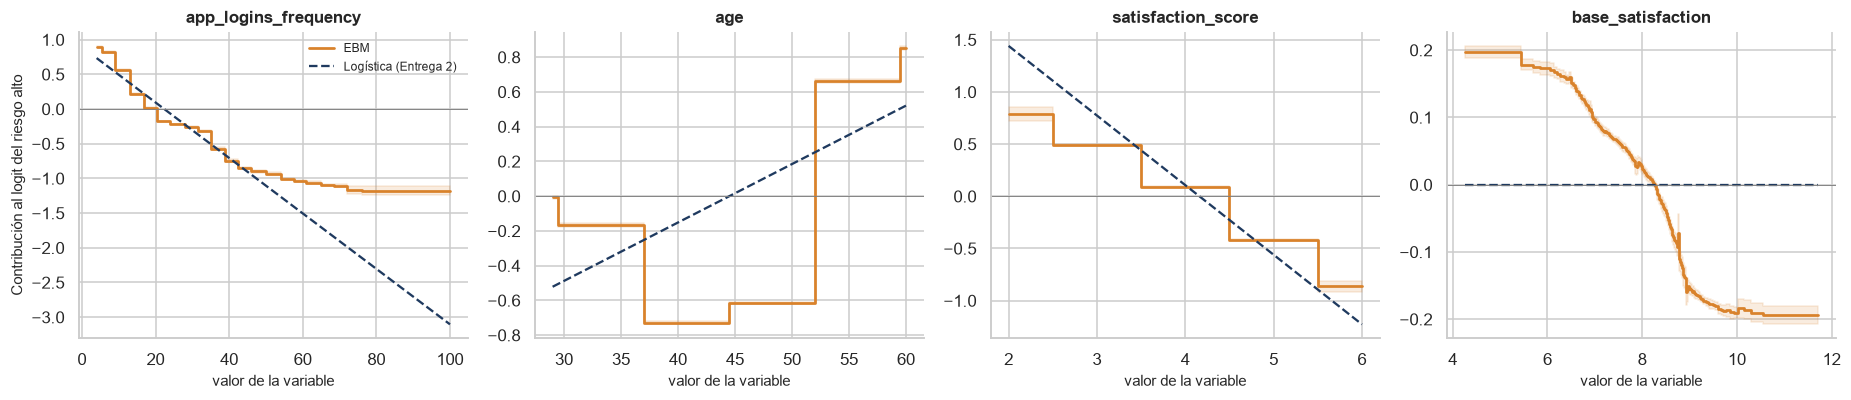

In [101]:
ebm_clf = modelos_cmp['clasificacion/ebm']
log_clf = modelos_cmp['clasificacion/logistica_e2']
variables = ['app_logins_frequency', 'age', 'satisfaction_score', 'base_satisfaction']
fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a, v in zip(ax, variables):
    f = analisis.forma_ebm(ebm_clf, v)
    x = np.r_[f['desde'].iloc[0], f['hasta']]
    a.step(x, np.r_[f['efecto'], f['efecto'].iloc[-1]], where='post', color='#d9822b', lw=1.8, label='EBM')
    a.fill_between(x, np.r_[f['inf'], f['inf'].iloc[-1]], np.r_[f['sup'], f['sup'].iloc[-1]], step='post',
                   color='#d9822b', alpha=0.15)
    xs = np.linspace(x[0], x[-1], 100)
    a.plot(xs, analisis.efecto_lineal(log_clf, v, xs), color=graficos.AZUL, lw=1.5, ls='--', label='Logística (Entrega 2)')
    a.axhline(0, color='grey', lw=0.6)
    a.set_title(v)
    a.set_xlabel('valor de la variable')
ax[0].set_ylabel('Contribución al logit del riesgo alto')
ax[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [102]:
ebm_modelo = ebm_clf.named_steps['modelo'].ebm_
importancia = pd.Series(ebm_modelo.term_importances(), index=[
    ' × '.join(nombres_variables(ebm_clf.named_steps['preprocesado'])[j] for j in t)
    for t in ebm_modelo.term_features_]).sort_values(ascending=False)
cuota = importancia / importancia.sum()
display(cuota.head(10).to_frame('cuota de la importancia total'))
pares_ebm = [t for t in importancia.index if ' × ' in t]

# Ablación: la misma EBM sin interacciones (GAM puro), reentrenada sobre el entrenamiento.
from sklearn.base import clone
gam = clone(ebm_clf).set_params(modelo__interactions=0).fit(c.X_train, p_med['y_train'])
puntaje_gam = gam.predict_proba(c.X_test.loc[pred.index])[:, 1]
ablacion = est.delong(pred['y_bin'], puntaje_gam, puntajes['ebm'])
sin_ablacion = est.delong(pred['y_bin'], puntajes['logistica_e2'], puntaje_gam)
nombres_pre = nombres_variables(log_clf.named_steps['preprocesado'])
coef_log = pd.Series(np.ravel(log_clf.named_steps['modelo'].coef_), index=nombres_pre)
anuladas = [v for v in variables if coef_log[v] == 0]
f_age = analisis.forma_ebm(ebm_clf, 'age')
display(Markdown(f"""
Las cuatro variables acumulan el {pct(cuota.reindex(variables).sum(), 0)} de la importancia de la EBM
(media del valor absoluto de cada término sobre el entrenamiento), y sus efectos no son lineales:
la EBM aprende tramos y mesetas que una recta no puede representar. El efecto de la edad, por
ejemplo, no es monótono: va de {dec(f_age['efecto'].min(), 2)} a {dec(f_age['efecto'].max(), 2)} en la escala del
logit, mientras que la logística solo puede asignarle una pendiente. La frecuencia de uso de la
aplicación deja de reducir el riesgo a partir de cierto nivel, pero la recta sigue bajando y
exagera el efecto en los usuarios más activos.{' La penalización L1 de la Entrega 2 anuló ' + enumerar(f'`{v}`' for v in anuladas) + (', que en la EBM tiene' if len(anuladas) == 1 else ', que en la EBM tienen') + ' un efecto claro y no lineal.' if anuladas else ''}

Las {len(pares_ebm)} interacciones por pares que eligió la EBM reúnen el {pct(cuota.reindex(pares_ebm).sum(), 1)} de la
importancia, pero aportan poco a la discriminación: una EBM idéntica sin interacciones (un modelo
aditivo puro) obtiene {dec(ablacion['auc_a'])} de AUC en prueba, frente a {dec(ablacion['auc_b'])} de la EBM completa
(DeLong {p_valor(ablacion['p_bilateral'])}), y por sí sola ya supera a la Entrega 2 en
{dec(sin_ablacion['diferencia'], 4, True)} (DeLong {p_valor(sin_ablacion['p_bilateral'])}). Lo que faltaba en la Entrega 2 era,
sobre todo, flexibilidad en cada variable.
"""))

,cuota de la importancia total
age,0.2418
app_logins_frequency,0.1797
satisfaction_score,0.1031
app_logins_frequency × satisfaction_score,0.0768
age × app_logins_frequency,0.0721
age × base_satisfaction,0.0425
base_satisfaction,0.0419
app_logins_frequency × base_satisfaction,0.0361
age × satisfaction_score,0.0279
income_bracket_Low,0.0131



Las cuatro variables acumulan el 57 % de la importancia de la EBM
(media del valor absoluto de cada término sobre el entrenamiento), y sus efectos no son lineales:
la EBM aprende tramos y mesetas que una recta no puede representar. El efecto de la edad, por
ejemplo, no es monótono: va de −0,73 a 0,85 en la escala del
logit, mientras que la logística solo puede asignarle una pendiente. La frecuencia de uso de la
aplicación deja de reducir el riesgo a partir de cierto nivel, pero la recta sigue bajando y
exagera el efecto en los usuarios más activos. La penalización L1 de la Entrega 2 anuló `base_satisfaction`, que en la EBM tiene un efecto claro y no lineal.

Las 5 interacciones por pares que eligió la EBM reúnen el 25,5 % de la
importancia, pero aportan poco a la discriminación: una EBM idéntica sin interacciones (un modelo
aditivo puro) obtiene 0,7185 de AUC en prueba, frente a 0,7187 de la EBM completa
(DeLong p = 0,910), y por sí sola ya supera a la Entrega 2 en
+0,0353 (DeLong p < 10⁻²¹). Lo que faltaba en la Entrega 2 era,
sobre todo, flexibilidad en cada variable.


## 6. El techo de información

¿Cuánto más se puede mejorar? `active_products` determina casi por completo el objetivo (se excluyó
como predictor porque la etiqueta se construyó a partir de ella), y no se relaciona con las demás
variables. Un modelo *oráculo* que la conoce explica casi toda la varianza; si se promedia su
pronóstico sobre la distribución de `active_products` del entrenamiento, se obtiene el mejor
pronóstico posible **sin** conocerla. Esa cifra es el techo de cualquier modelo que use solo las
variables permitidas. Se calcula aquí sobre la misma prueba, con un *gradient boosting* de
histogramas como oráculo (la variable solo se usa para entrenarlo).

In [103]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, roc_auc_score

pre = comparacion.pipeline_entrega2('regresion', c.X_train).named_steps['preprocesado'].fit(c.X_train)
ap = p_med['df']['active_products']
Xtr_o = np.column_stack([pre.transform(c.X_train), ap.loc[c.X_train.index]])
oraculo = HistGradientBoostingRegressor(learning_rate=0.05, max_iter=600, random_state=42).fit(Xtr_o, c.y_train_cont)
X_te_o = pre.transform(c.X_test.loc[pred.index])
r2_oraculo = r2_score(pred['y_cont'], oraculo.predict(np.column_stack([X_te_o, ap.loc[pred.index]])))
niveles, cuentas = np.unique(ap.loc[c.X_train.index], return_counts=True)
techo = sum(w * oraculo.predict(np.column_stack([X_te_o, np.full(len(X_te_o), k)]))
            for k, w in zip(niveles, cuentas / cuentas.sum()))
techo_auc, techo_r2 = roc_auc_score(pred['y_bin'], techo), r2_score(pred['y_cont'], techo)
(CARPETA / 'techo.json').write_text(json.dumps({'auc_mediana': techo_auc, 'r2': techo_r2, 'r2_oraculo': r2_oraculo}),
                                    encoding='utf-8')
resumen_techo = pd.DataFrame({
    'AUC (mediana)': [metricas_clf.loc[NOMBRE['logistica_e2'], 'auc'], metricas_clf.loc[NOMBRE['xgboost'], 'auc'],
                      metricas_clf.loc[NOMBRE['ebm'], 'auc'], techo_auc],
    'R²': [metricas_reg.loc[NOMBRE['lasso_e2'], 'r2'], metricas_reg.loc[NOMBRE['xgboost'], 'r2'],
           metricas_reg.loc[NOMBRE['ebm'], 'r2'], techo_r2]},
    index=['Entrega 2', 'XGBoost (clase)', 'EBM (modelo nuevo)', 'Techo: oráculo marginalizado'])
resumen_techo['fracción del techo (AUC − 0,5)'] = (resumen_techo['AUC (mediana)'] - 0.5) / (techo_auc - 0.5)
resumen_techo['fracción del techo (R²)'] = resumen_techo['R²'] / techo_r2
resumen_techo

,AUC (mediana),R²,"fracción del techo (AUC − 0,5)",fracción del techo (R²)
Entrega 2,0.6832,0.1511,0.8241,0.6877
XGBoost (clase),0.7206,0.2177,0.9925,0.9906
EBM (modelo nuevo),0.7187,0.2159,0.9838,0.9826
Techo: oráculo marginalizado,0.7223,0.2197,1.0000,1.0000


In [104]:
display(Markdown(f"""
Con `active_products` el oráculo alcanza un R² de {dec(r2_oraculo, 4)} en prueba. Sin ella, el techo es de
**{dec(techo_auc, 4)} de AUC y {dec(techo_r2, 4)} de R²**. La Entrega 2 cubría el
{pct(resumen_techo.loc['Entrega 2', 'fracción del techo (AUC − 0,5)'], 0)} de la discriminación alcanzable
(medida como AUC − 0,5) y el {pct(resumen_techo.loc['Entrega 2', 'fracción del techo (R²)'], 0)} del R² alcanzable; la EBM
llega al {pct(resumen_techo.loc['EBM (modelo nuevo)', 'fracción del techo (AUC − 0,5)'], 0)} y al
{pct(resumen_techo.loc['EBM (modelo nuevo)', 'fracción del techo (R²)'], 0)}. Queda, por tanto, muy poco margen: ningún modelo,
por complejo que sea, puede superar esas cifras con las variables disponibles, y por eso la EBM y
XGBoost terminan empatados a pocas milésimas del techo.
"""))


Con `active_products` el oráculo alcanza un R² de 0,9994 en prueba. Sin ella, el techo es de
**0,7223 de AUC y 0,2197 de R²**. La Entrega 2 cubría el
82 % de la discriminación alcanzable
(medida como AUC − 0,5) y el 69 % del R² alcanzable; la EBM
llega al 98 % y al
98 %. Queda, por tanto, muy poco margen: ningún modelo,
por complejo que sea, puede superar esas cifras con las variables disponibles, y por eso la EBM y
XGBoost terminan empatados a pocas milésimas del techo.


## 7. La EBM dentro del pipeline combinatorio

Además de la comparación anterior, la EBM se integró en el pipeline de la guía como octavo modelo,
con la etiqueta del percentil 75 y la misma validación anidada: 4 balanceos × 4 optimizadores en
clasificación y 4 optimizadores en regresión. `class_weight` se implementa con pesos por fila,
porque la librería no lo ofrece, y se aplica multi-fidelidad (2 bolsas externas durante la búsqueda
y 8 en el modelo final).

In [105]:
tabla = analisis.cargar_tabla()
ebm_filas = tabla[(tabla['modelo'] == 'ebm') & (tabla['estado'] == 'ok')]
if ebm_filas.empty:
    display(Markdown('*Las corridas de la EBM en el pipeline todavía no han terminado.*'))
else:
    resumen = []
    for tarea in ('clasificacion', 'regresion'):
        mej = analisis.mejores_por_modelo(tabla, tarea)
        resumen.append(mej.assign(tarea=tarea)[['tarea', 'modelo', 'balanceo', 'optimizador', 'metrica', 'desv_ext']])
    display(pd.concat(resumen).set_index(['tarea', 'modelo']))
    display(ebm_filas.pivot_table(index=['tarea', 'balanceo'], columns='optimizador', values='metrica'))

balanceo optimizador  metrica  desv_ext
tarea         modelo                                                    
clasificacion xgboost        class_weight    genetica   0.8332    0.0049
              arbol          class_weight      random   0.8332    0.0021
              random_forest       ninguno    genetica   0.8326    0.0029
              ebm            class_weight        grid   0.8292    0.0037
              knn                 ninguno    genetica   0.7836    0.0072
              logistica      class_weight    genetica   0.7644    0.0047
              svm            class_weight        grid   0.7641    0.0044
              naive_bayes         ninguno        grid   0.6722    0.0119
regresion     xgboost             ninguno   bayesiana   0.0590    0.0004
              ebm                 ninguno        grid   0.0590    0.0004
              random_forest       ninguno        grid   0.0592    0.0004
              arbol               ninguno    genetica   0.0593    0.0004
              lasso               ninguno    genetica   0.0618    0.0005
              ridge               ninguno    genetica   0.0618    0.0005
              svr                 ninguno   bayesiana   0.0618    0.0005
              knn                 ninguno        grid   0.0634    0.0004

optimizador                 bayesiana  genetica   grid  random
tarea         balanceo                                        
clasificacion adasyn           0.8283    0.8286 0.8280  0.8289
              class_weight     0.8287    0.8281 0.8292  0.8276
              ninguno          0.8289    0.8291 0.8285  0.8289
              smote            0.8279    0.8282 0.8278  0.8284
regresion     ninguno          0.0590    0.0591 0.0590  0.0591

In [106]:
if not ebm_filas.empty:
    mc = analisis.mejores_por_modelo(tabla, 'clasificacion').reset_index(drop=True)
    mr = analisis.mejores_por_modelo(tabla, 'regresion').reset_index(drop=True)
    pos_c = int(mc.index[mc['modelo'] == 'ebm'][0]) + 1
    pos_r = int(mr.index[mr['modelo'] == 'ebm'][0]) + 1
    e_c = ebm_filas[ebm_filas['tarea'] == 'clasificacion']
    e_r = ebm_filas[ebm_filas['tarea'] == 'regresion']
    minutos = ebm_filas.groupby(['tarea', 'balanceo'])['tiempo_total_s'].mean() / 60
    sobremuestreo = minutos.loc[('clasificacion', ['smote', 'adasyn'])].mean() / minutos.loc[('clasificacion', 'ninguno')]
    display(Markdown(f"""
Con la etiqueta del percentil 75 y la misma validación anidada que los demás, la mejor EBM queda en el puesto
{pos_c} de {len(mc)} en clasificación (AUC externa {dec(mc.loc[pos_c - 1, 'metrica'])}, a {dec(mc.loc[0, 'metrica'] - mc.loc[pos_c - 1, 'metrica'], 4)} de
{analisis.NOMBRES_MODELO[mc.loc[0, 'modelo']]}) y en el puesto {pos_r} de {len(mr)} en regresión (RMSE {dec(mr.loc[pos_r - 1, 'metrica'])}). Es decir, en
el pipeline completo se comporta como en la comparación con la Entrega 2: en el grupo de los modelos de
árboles, a milésimas del mejor.

Sus {len(e_c)} corridas de clasificación dan un AUC entre {dec(e_c['metrica'].min())} y {dec(e_c['metrica'].max())}, y las {len(e_r)} de
regresión un RMSE entre {dec(e_r['metrica'].min())} y {dec(e_r['metrica'].max())}: ni la técnica de balanceo ni el optimizador
mueven el resultado más allá de la variabilidad entre pliegues. Lo que sí cambia es el coste: con SMOTE o
ADASYN cada corrida tardó {dec(sobremuestreo, 1)} veces más que sin balanceo, bastante más de lo que explica el 50 % de filas
que añade el sobremuestreo, y sin ninguna ganancia de AUC. En
total, las {len(ebm_filas)} corridas de la EBM sumaron {dec(ebm_filas['tiempo_total_s'].sum() / 3600, 1)} horas de cómputo.
"""))


Con la etiqueta del percentil 75 y la misma validación anidada que los demás, la mejor EBM queda en el puesto
4 de 8 en clasificación (AUC externa 0,8292, a 0,0040 de
XGBoost) y en el puesto 2 de 8 en regresión (RMSE 0,0590). Es decir, en
el pipeline completo se comporta como en la comparación con la Entrega 2: en el grupo de los modelos de
árboles, a milésimas del mejor.

Sus 16 corridas de clasificación dan un AUC entre 0,8276 y 0,8292, y las 4 de
regresión un RMSE entre 0,0590 y 0,0591: ni la técnica de balanceo ni el optimizador
mueven el resultado más allá de la variabilidad entre pliegues. Lo que sí cambia es el coste: con SMOTE o
ADASYN cada corrida tardó 3,7 veces más que sin balanceo, bastante más de lo que explica el 50 % de filas
que añade el sobremuestreo, y sin ninguna ganancia de AUC. En
total, las 20 corridas de la EBM sumaron 19,5 horas de cómputo.


## 8. Conclusión

In [107]:
display(Markdown(f"""
- **La EBM, un modelo que no forma parte del curso, supera a los dos modelos de la Entrega 2 en la misma
  prueba y con la misma etiqueta**: {dec(fe['diferencia'], 4, True)} de AUC (DeLong {p_valor(fe['p_delong'])}) y
  {dec(ge['mejora_r2'], 4, True)} de R² (Diebold-Mariano {p_valor(ge['p_dm'])}), con intervalos bootstrap que no
  incluyen el cero y mejoras que se repiten en todos los pliegues.
- **Empata con XGBoost**, el mejor modelo visto en clase, en las dos tareas: las diferencias no son
  significativas. Lo que la EBM añade es la legibilidad: cada variable aporta una curva que se puede
  revisar, mientras que XGBoost necesita SHAP o LIME para explicarse.
- **Los dos están a pocas milésimas del techo de información** ({dec(techo_auc, 4)} de AUC y {dec(techo_r2, 4)} de
  R²). No hay un modelo que pueda hacerlo mucho mejor con estas variables.
- La Entrega 2 no falló por falta de datos ni de optimización, sino porque sus modelos eran lineales
  y la relación no lo es: las funciones de forma de la EBM lo muestran directamente.
"""))


- **La EBM, un modelo que no forma parte del curso, supera a los dos modelos de la Entrega 2 en la misma
  prueba y con la misma etiqueta**: +0,0355 de AUC (DeLong p < 10⁻¹⁸) y
  +0,0648 de R² (Diebold-Mariano p < 10⁻³⁹), con intervalos bootstrap que no
  incluyen el cero y mejoras que se repiten en todos los pliegues.
- **Empata con XGBoost**, el mejor modelo visto en clase, en las dos tareas: las diferencias no son
  significativas. Lo que la EBM añade es la legibilidad: cada variable aporta una curva que se puede
  revisar, mientras que XGBoost necesita SHAP o LIME para explicarse.
- **Los dos están a pocas milésimas del techo de información** (0,7223 de AUC y 0,2197 de
  R²). No hay un modelo que pueda hacerlo mucho mejor con estas variables.
- La Entrega 2 no falló por falta de datos ni de optimización, sino porque sus modelos eran lineales
  y la relación no lo es: las funciones de forma de la EBM lo muestran directamente.


# Comparación estadística de los modelos

Una diferencia de una milésima de AUC entre dos modelos no significa nada si la variabilidad de
la estimación es de cinco milésimas. Esta página aplica el protocolo de la guía (§6) para decidir
qué diferencias son reales:

| Tarea | Paso 1: ¿difieren? | Paso 2: ¿cuáles? | Paso 3: finalistas sobre la prueba | Tamaño del efecto |
|---|---|---|---|---|
| Clasificación | Friedman (con Iman-Davenport) | Nemenyi y diagrama de diferencia crítica | DeLong por pares con Holm y Benjamini-Hochberg | delta de Cliff |
| Regresión | *Model Confidence Set* | Giacomini-White condicional | Diebold-Mariano con HLN y bootstrap estacionario | d de Cohen |

En las dos tareas cada modelo entra con **su mejor combinación de balanceo y optimizador según el
bucle externo**, elegida sin mirar la prueba. Los pasos 1 y 2 usan los puntajes de los 5 pliegues
externos, que son los mismos para todos los modelos; el paso 3 usa la prueba (9.745 clientes), que
cada modelo ve una sola vez. Las métricas principales llevan intervalos bootstrap BCa.

In [108]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, comparacion, datos, graficos
from src import estadistica as est
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, intervalo, p_valor, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

tabla = analisis.cargar_tabla()
p = datos.preparar_todo()                      # etiqueta del percentil 75, la de las corridas
X_te = p['conjuntos'].X_test.sort_index()      # orden original del archivo de clientes
y_te = p['y_test'].loc[X_te.index]
y_te_c = p['conjuntos'].y_test_cont.loc[X_te.index]
pred = analisis.predecir_prueba(tabla, X_te, RAIZ / 'resultados' / 'predicciones_prueba.parquet',
                                informar=lambda s: None)
mejores = {t: analisis.mejores_por_modelo(tabla, t) for t in ('clasificacion', 'regresion')}
for t, m in mejores.items():
    print(t)
    print(m[['modelo', 'balanceo', 'optimizador', 'metrica', 'desv_ext']].to_string(index=False))

clasificacion
       modelo     balanceo optimizador  metrica  desv_ext
      xgboost class_weight    genetica   0.8332    0.0049
        arbol class_weight      random   0.8332    0.0021
random_forest      ninguno    genetica   0.8326    0.0029
          ebm class_weight        grid   0.8292    0.0037
          knn      ninguno    genetica   0.7836    0.0072
    logistica class_weight    genetica   0.7644    0.0047
          svm class_weight        grid   0.7641    0.0044
  naive_bayes      ninguno        grid   0.6722    0.0119
regresion
       modelo balanceo optimizador  metrica  desv_ext
      xgboost  ninguno   bayesiana   0.0590    0.0004
          ebm  ninguno        grid   0.0590    0.0004
random_forest  ninguno        grid   0.0592    0.0004
        arbol  ninguno    genetica   0.0593    0.0004
        lasso  ninguno    genetica   0.0618    0.0005
        ridge  ninguno    genetica   0.0618    0.0005
          svr  ninguno   bayesiana   0.0618    0.0005
          knn  ninguno

## Clasificación

### Paso 1 y 2: Friedman y Nemenyi sobre los pliegues externos

Cada pliegue externo es un bloque en el que los modelos se ordenan por su AUC. Con 5 bloques la
prueba tiene poca potencia (la diferencia crítica de Nemenyi es grande), así que se repite con un
diseño más amplio como comprobación de robustez: cada combinación de pliegue, balanceo y
optimizador es un bloque, de modo que un modelo se compara con los demás en las mismas condiciones.
Esos bloques no son independientes (comparten datos), y por eso el diseño principal es el de 5.

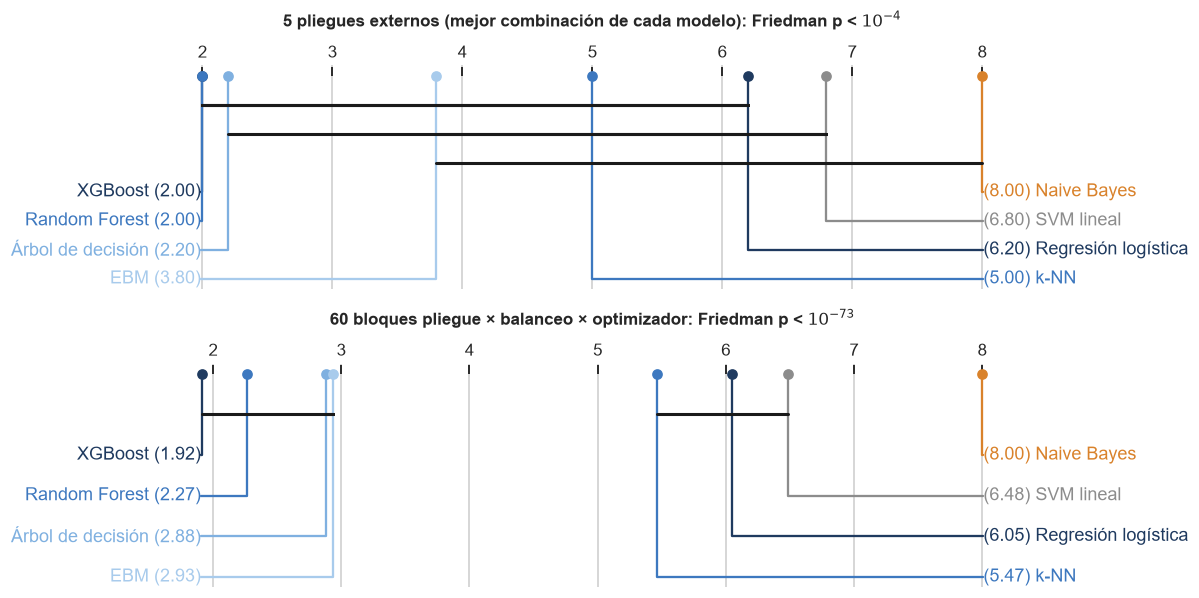

,5 pliegues,bloques amplios
n_bloques,5.0000,60.0000
k,8.0000,8.0000
chi2,32.4667,362.5000
p,0.0000,0.0000
F,51.2632,371.9565
p_iman_davenport,0.0000,0.0000
dc,4.6954,1.3555


In [109]:
def puntajes_por_pliegue(mej):
    return pd.DataFrame({f['modelo']: f['puntajes_ext'] for _, f in mej.iterrows()})

auc_pliegues = puntajes_por_pliegue(mejores['clasificacion'])
fr_c = est.friedman(auc_pliegues)

ok = tabla[(tabla['tarea'] == 'clasificacion') & (tabla['estado'] == 'ok')]
largo = []
for _, f in ok.iterrows():
    for i, v in enumerate(f['puntajes_ext']):
        largo.append({'bloque': (f['balanceo'], f['optimizador'], i), 'modelo': f['modelo'], 'auc': v})
amplio = pd.DataFrame(largo).pivot_table(index='bloque', columns='modelo', values='auc')
fr_amplio = est.friedman(amplio)

fig, ax = plt.subplots(2, 1, figsize=(11, 5.6))
graficos.diagrama_cd(fr_c, ax=ax[0], etiquetas=NOMBRES_MODELO,
                     titulo=f'5 pliegues externos (mejor combinación de cada modelo): Friedman {p_valor(fr_c["p"], grafico=True)}')
graficos.diagrama_cd(fr_amplio, ax=ax[1], etiquetas=NOMBRES_MODELO,
                     titulo=f'{fr_amplio["n_bloques"]} bloques pliegue × balanceo × optimizador: Friedman {p_valor(fr_amplio["p"], grafico=True)}')
plt.tight_layout()
plt.show()
pd.DataFrame({'5 pliegues': {k: fr_c[k] for k in ('n_bloques', 'k', 'chi2', 'p', 'F', 'p_iman_davenport', 'dc')},
              'bloques amplios': {k: fr_amplio[k] for k in ('n_bloques', 'k', 'chi2', 'p', 'F', 'p_iman_davenport', 'dc')}})

In [110]:
rangos = fr_c['rangos_medios']
mejor_modelo = rangos.index[0]
indistinguibles = [m for m in rangos.index if fr_c['p_nemenyi'].loc[mejor_modelo, m] >= 0.05]
display(Markdown(f"""
Con los 5 pliegues externos los modelos difieren (Friedman {p_valor(fr_c['p'])}; Iman-Davenport
{p_valor(fr_c['p_iman_davenport'])}), pero la diferencia crítica de Nemenyi es de {dec(fr_c['dc'], 2)} rangos
sobre {fr_c['k']} modelos, y solo los extremos se separan: {NOMBRES_MODELO[mejor_modelo]}, el de mejor
rango medio, no se distingue de {enumerar(NOMBRES_MODELO[m] for m in indistinguibles if m != mejor_modelo)}.
Con {fr_amplio['n_bloques']} bloques la diferencia crítica baja a {dec(fr_amplio['dc'], 2)} rangos y el orden es
el mismo: {', '.join(f"{NOMBRES_MODELO[m]} ({dec(v, 2)})" for m, v in fr_amplio['rangos_medios'].items())}.
"""))


Con los 5 pliegues externos los modelos difieren (Friedman p < 10⁻⁴; Iman-Davenport
p < 10⁻¹³), pero la diferencia crítica de Nemenyi es de 4,70 rangos
sobre 8 modelos, y solo los extremos se separan: XGBoost, el de mejor
rango medio, no se distingue de Random Forest, Árbol de decisión, EBM, k-NN y Regresión logística.
Con 60 bloques la diferencia crítica baja a 1,36 rangos y el orden es
el mismo: XGBoost (1,92), Random Forest (2,27), Árbol de decisión (2,88), EBM (2,93), k-NN (5,47), Regresión logística (6,05), SVM lineal (6,48), Naive Bayes (8,00).


### Paso 3: DeLong entre los finalistas, sobre la prueba

Los finalistas son los modelos que Nemenyi no separa del mejor en el diseño amplio, más el modelo
nuevo. Sobre la prueba, DeLong compara cada pareja teniendo en cuenta que las dos AUC se calculan
sobre los mismos clientes (y por eso están correlacionadas). Con varias parejas a la vez, los
p-valores se ajustan con Holm-Bonferroni (controla la probabilidad de algún falso positivo) y con
Benjamini-Hochberg (controla la proporción de falsos descubrimientos).

In [111]:
rangos_amplio = fr_amplio['rangos_medios']
lider = rangos_amplio.index[0]
finalistas = [m for m in rangos_amplio.index if fr_amplio['p_nemenyi'].loc[lider, m] >= 0.05]
if 'ebm' in auc_pliegues.columns and 'ebm' not in finalistas:
    finalistas.append('ebm')
claves = mejores['clasificacion'].set_index('modelo')['clave']
puntajes = {m: pred[claves[m]].to_numpy() for m in finalistas}
pares = [(a, b) for i, a in enumerate(finalistas) for b in finalistas[i + 1:]]
delong = comparacion.contrastar_clasificacion(y_te, puntajes, pares, auc_pliegues={m: auc_pliegues[m] for m in finalistas})
delong['p_bh'] = est.ajustar_pvalores(delong['p_delong'], 'fdr_bh')
delong[['referencia', 'candidato', 'auc_referencia', 'auc_candidato', 'diferencia', 'ic_bca_inf', 'ic_bca_sup',
        'p_delong', 'p_delong_ajustado', 'p_bh', 'correlacion_auc', 'delta_cliff', 'magnitud_cliff']]

,referencia,candidato,auc_referencia,auc_candidato,diferencia,ic_bca_inf,ic_bca_sup,p_delong,p_delong_ajustado,p_bh,correlacion_auc,delta_cliff,magnitud_cliff
0,xgboost,random_forest,0.8283,0.8260,-0.0023,-0.0071,0.0029,0.3638,1.0000,0.5524,0.8077,-0.2000,pequeño
1,xgboost,arbol,0.8283,0.8243,-0.0040,-0.0083,0.0002,0.0795,0.4773,0.4773,0.8403,-0.1200,despreciable
2,xgboost,ebm,0.8283,0.8289,0.0006,-0.0057,0.0071,0.8479,1.0000,0.8479,0.6594,-0.5200,grande
3,random_forest,arbol,0.8260,0.8243,-0.0017,-0.0074,0.0041,0.5697,1.0000,0.6837,0.7195,0.1200,despreciable
4,random_forest,ebm,0.8260,0.8289,0.0029,-0.0035,0.0093,0.3683,1.0000,0.5524,0.6788,-0.4400,mediano
5,arbol,ebm,0.8243,0.8289,0.0046,-0.0019,0.0116,0.2066,1.0000,0.5524,0.5863,-0.6800,grande


In [112]:
intervalos_clf = comparacion.intervalos_clasificacion(y_te, {m: pred[claves[m]].to_numpy() for m in claves.index})
intervalos_clf.index = [NOMBRES_MODELO[m] for m in intervalos_clf.index]
intervalos_clf.sort_values('auc', ascending=False)

,auc,ee_delong,ic_delong_inf,ic_delong_sup,ic_bca_inf,ic_bca_sup
EBM,0.8289,0.0040,0.8210,0.8368,0.8206,0.8366
XGBoost,0.8283,0.0040,0.8204,0.8362,0.8203,0.8359
Random Forest,0.8260,0.0040,0.8181,0.8339,0.8184,0.8338
Árbol de decisión,0.8243,0.0040,0.8164,0.8322,0.8165,0.8319
k-NN,0.7874,0.0048,0.7779,0.7968,0.7777,0.7966
Regresión logística,0.7709,0.0051,0.7608,0.7809,0.7600,0.7806
SVM lineal,0.7706,0.0051,0.7605,0.7806,0.7599,0.7803
Naive Bayes,0.6662,0.0063,0.6540,0.6785,0.6537,0.6787


In [113]:
sig = delong[delong['p_delong_ajustado'] < 0.05]
if len(sig) == 0:
    frase_holm = '**ninguna diferencia sobrevive** a la corrección de Holm'
else:
    detalle = '; '.join(f"{NOMBRES_MODELO[r.candidato]} frente a {NOMBRES_MODELO[r.referencia]}: "
                        f"{dec(r.diferencia, 4, True)}, Holm {p_valor(r.p_delong_ajustado)}" for r in sig.itertuples())
    frase_holm = (f"**{len(sig)} {'diferencia sobrevive' if len(sig) == 1 else 'diferencias sobreviven'}** "
                  f"a la corrección de Holm ({detalle})")
display(Markdown(f"""
Finalistas: {enumerar(NOMBRES_MODELO[m] for m in finalistas)}. De sus {len(delong)} parejas,
{frase_holm}. Las diferencias de AUC entre finalistas son de {dec(delong['diferencia'].abs().min(), 4)} a
{dec(delong['diferencia'].abs().max(), 4)}, del mismo orden que la anchura de los intervalos BCa de cada
modelo (unas {dec((intervalos_clf['ic_bca_sup'] - intervalos_clf['ic_bca_inf']).median() / 2, 3)} a cada lado).
La correlación entre las AUC de dos finalistas es de {dec(delong['correlacion_auc'].min(), 2)} a
{dec(delong['correlacion_auc'].max(), 2)}: ordenan a los clientes de forma muy parecida, que es la razón de que
DeLong sea mucho más sensible que comparar sus intervalos por separado.

El delta de Cliff sobre los pliegues externos mide otra cosa: con qué frecuencia un modelo supera al
otro pliegue a pliegue. Valores de ±1 indican que uno gana en todos los pliegues, aunque la ventaja
sea de milésimas; por eso se lee junto a la diferencia de AUC y no en lugar de ella.
"""))


Finalistas: XGBoost, Random Forest, Árbol de decisión y EBM. De sus 6 parejas,
**ninguna diferencia sobrevive** a la corrección de Holm. Las diferencias de AUC entre finalistas son de 0,0006 a
0,0046, del mismo orden que la anchura de los intervalos BCa de cada
modelo (unas 0,009 a cada lado).
La correlación entre las AUC de dos finalistas es de 0,59 a
0,84: ordenan a los clientes de forma muy parecida, que es la razón de que
DeLong sea mucho más sensible que comparar sus intervalos por separado.

El delta de Cliff sobre los pliegues externos mide otra cosa: con qué frecuencia un modelo supera al
otro pliegue a pliegue. Valores de ±1 indican que uno gana en todos los pliegues, aunque la ventaja
sea de milésimas; por eso se lee junto a la diferencia de AUC y no en lugar de ella.


## Regresión

### Paso 1: *Model Confidence Set*

El MCS de Hansen, Lunde y Nason (2011) responde a «¿qué modelos podrían ser el mejor?». Parte de
todos y elimina, de uno en uno, el peor mientras la prueba de igualdad de precisión se rechace,
usando las pérdidas cuadráticas de la prueba y un bootstrap estacionario (las filas se toman en el
orden original del archivo, que no es aleatorio: está organizado por bloques de clientes). Los que
sobreviven forman un conjunto que contiene al mejor modelo con un 90 % de confianza.

In [114]:
claves_r = mejores['regresion'].set_index('modelo')['clave']
pron = {m: pred[claves_r[m]].to_numpy() for m in claves_r.index}
perdidas = pd.DataFrame({m: (y_te_c.to_numpy() - v) ** 2 for m, v in pron.items()})
mcs = est.conjunto_confianza_modelos(perdidas, alfa=0.10, n_boot=2000)
pd.DataFrame({'p MCS': mcs['p_mcs'], 'en el conjunto (90 %)': mcs['p_mcs'] > mcs['alfa'],
              'RMSE de prueba': np.sqrt(perdidas.mean())}).rename(index=NOMBRES_MODELO).sort_values('p MCS', ascending=False)

,p MCS,en el conjunto (90 %),RMSE de prueba
XGBoost,1.0000,True,0.0592
EBM,0.0720,False,0.0593
Random Forest,0.0055,False,0.0593
Árbol de decisión,0.0000,False,0.0594
Lasso,0.0000,False,0.0617
k-NN,0.0000,False,0.0632
Ridge,0.0000,False,0.0617
SVR lineal,0.0000,False,0.0617


In [115]:
eliminados = [m for m in mcs['p_mcs'].sort_values().index if m not in mcs['incluidos']]
display(Markdown(f"""
El conjunto de confianza al 90 % contiene {len(mcs['incluidos'])} {'modelo' if len(mcs['incluidos']) == 1 else 'modelos'}:
**{enumerar(NOMBRES_MODELO[m] for m in mcs['incluidos'])}**. Quedan fuera {enumerar(f"{NOMBRES_MODELO[m]} ({p_valor(mcs['p_mcs'][m])})" for m in reversed(eliminados))};
el último en salir es el de mayor p-valor MCS.
Que salgan incluso modelos con un RMSE casi idéntico se explica porque las pérdidas de dos modelos
sobre el mismo cliente están muy correlacionadas: con 9.745 clientes, una diferencia sistemática de
décimas de milésima es detectable. El bootstrap usó bloques de longitud media {mcs['bloque']}, elegida con
el método de Politis y White a partir de la dependencia de las pérdidas en el orden del archivo.
"""))


El conjunto de confianza al 90 % contiene 1 modelo:
**XGBoost**. Quedan fuera EBM (p = 0,072), Random Forest (p = 0,005), Árbol de decisión (p < 0,001), Lasso (p < 0,001), Ridge (p < 0,001), SVR lineal (p < 0,001) y k-NN (p < 0,001);
el último en salir es el de mayor p-valor MCS.
Que salgan incluso modelos con un RMSE casi idéntico se explica porque las pérdidas de dos modelos
sobre el mismo cliente están muy correlacionadas: con 9.745 clientes, una diferencia sistemática de
décimas de milésima es detectable. El bootstrap usó bloques de longitud media 3, elegida con
el método de Politis y White a partir de la dependencia de las pérdidas en el orden del archivo.


### Comprobación complementaria: *Superior Predictive Ability* (SPA)

El MCS pregunta qué modelos podrían ser el mejor. La prueba SPA de Hansen (2005), versión refinada
del *Reality Check* de White (2000), responde a otra pregunta: ¿algún modelo de un conjunto supera de
forma genuina a uno de referencia, teniendo en cuenta que se probaron muchos? Se aplica dos veces: con el
Lasso (el modelo de la Entrega 2) como referencia, y con el mejor modelo como referencia.

In [116]:
from arch.bootstrap import SPA

orden_rmse = list(np.sqrt(perdidas.mean()).sort_values().index)
spa_filas = []
for referencia in ('lasso', orden_rmse[0]):
    otros = [m for m in perdidas.columns if m != referencia]
    spa = SPA(perdidas[referencia], perdidas[otros], block_size=mcs['bloque'], reps=2000,
              bootstrap='stationary', seed=42)
    spa.compute()
    spa_filas.append({'referencia': NOMBRES_MODELO[referencia], 'modelos comparados': len(otros),
                      'p SPA (consistente)': float(spa.pvalues['consistent']),
                      'p SPA (inferior)': float(spa.pvalues['lower']), 'p SPA (superior)': float(spa.pvalues['upper'])})
spa_tabla = pd.DataFrame(spa_filas).set_index('referencia')
display(spa_tabla)
display(Markdown(f"""
Frente al Lasso, la hipótesis de que ningún modelo lo supera se rechaza
({p_valor(spa_tabla.iloc[0]['p SPA (consistente)'])}): al menos un modelo es genuinamente más preciso, lo que coincide con la
comparación con la Entrega 2. Frente a {spa_tabla.index[1]}, {'no se rechaza' if spa_tabla.iloc[1]['p SPA (consistente)'] >= 0.05 else 'se rechaza'}
({p_valor(spa_tabla.iloc[1]['p SPA (consistente)'])}): {'ningún otro modelo lo supera de forma genuina' if spa_tabla.iloc[1]['p SPA (consistente)'] >= 0.05 else 'algún modelo lo supera'}.
"""))

,modelos comparados,p SPA (consistente),p SPA (inferior),p SPA (superior)
referencia,,,,
Lasso,7,0.0000,0.0000,0.0000
XGBoost,7,0.9735,0.5640,1.0000



Frente al Lasso, la hipótesis de que ningún modelo lo supera se rechaza
(p < 0,001): al menos un modelo es genuinamente más preciso, lo que coincide con la
comparación con la Entrega 2. Frente a XGBoost, no se rechaza
(p = 0,974): ningún otro modelo lo supera de forma genuina.


### Paso 2: Giacomini-White condicional

Diebold-Mariano pregunta si dos modelos son igual de precisos en promedio. Giacomini y White (2006)
preguntan además si la ventaja de uno depende de algo observable. Aquí el instrumento es el nivel de
riesgo que pronostica el modelo de referencia: si la prueba rechaza, el candidato gana en unos
tramos de riesgo y no en otros, y el coeficiente de la regresión del diferencial de pérdidas sobre
ese nivel dice en cuáles. Se eligió Giacomini-White en lugar de Clark-West porque los modelos
comparados no están anidados.

In [117]:
orden = list(pd.Series(np.sqrt(perdidas.mean())).sort_values().index)
mejor_r = orden[0]
filas = []
for m in orden[1:]:
    gw = est.giacomini_white(perdidas[m], perdidas[mejor_r], instrumentos=pron[m])
    filas.append({'referencia': NOMBRES_MODELO[m], 'candidato': NOMBRES_MODELO[mejor_r], 'GW': gw['estadistico'],
                  'gl': gw['gl'], 'p': gw['p'], 'd medio': gw['d_media'],
                  'pendiente frente al riesgo pronosticado': gw['coeficientes'][1]})
gw_tabla = pd.DataFrame(filas)
gw_tabla

,referencia,candidato,GW,gl,p,d medio,pendiente frente al riesgo pronosticado
0,EBM,XGBoost,3.5354,2,0.1707,0.0000,-0.0001
1,Random Forest,XGBoost,9.8664,2,0.0072,0.0000,-0.0002
2,Árbol de decisión,XGBoost,17.5166,2,0.0002,0.0000,0.0000
3,Lasso,XGBoost,195.8428,2,0.0000,0.0003,-0.0018
4,Ridge,XGBoost,197.7040,2,0.0000,0.0003,-0.0012
5,SVR lineal,XGBoost,199.9162,2,0.0000,0.0003,-0.0013
6,k-NN,XGBoost,318.4348,2,0.0000,0.0005,0.0040


### Paso 3: Diebold-Mariano con HLN y bootstrap estacionario entre los finalistas

In [118]:
finalistas_r = [m for m in orden if m in mcs['incluidos']] + [m for m in orden if m not in mcs['incluidos']][:2]
pares_r = [(a, b) for i, b in enumerate(finalistas_r) for a in finalistas_r[i + 1:]]
rmse_pliegues = {m: [-v for v in f] for m, f in mejores['regresion'].set_index('modelo')['puntajes_ext'].items()}
dm = comparacion.contrastar_regresion(y_te_c, pron, pares_r, rmse_pliegues=rmse_pliegues)
dm[['referencia', 'candidato', 'mejora_rmse', 'mejora_rmse_ic_inf', 'mejora_rmse_ic_sup', 'mejora_r2', 'dm_hln',
    'p_dm', 'p_dm_ajustado', 'bloque', 'p_bootstrap_estacionario', 'p_ljung_box', 'd_cohen_z', 'd_cohen_pliegues']]

,referencia,candidato,mejora_rmse,mejora_rmse_ic_inf,mejora_rmse_ic_sup,mejora_r2,dm_hln,p_dm,p_dm_ajustado,bloque,p_bootstrap_estacionario,p_ljung_box,d_cohen_z,d_cohen_pliegues
0,ebm,xgboost,0.0001,-0.0000,0.0002,0.0021,1.8524,0.0640,0.1280,2.3374,0.0690,0.5708,0.0188,0.1277
1,random_forest,xgboost,0.0001,0.0000,0.0002,0.0036,2.9278,0.0034,0.0103,1.0000,0.0035,0.9042,0.0297,0.4261
2,random_forest,ebm,0.0001,-0.0001,0.0002,0.0015,0.8233,0.4104,0.4104,1.2422,0.4050,0.8306,0.0083,0.2833


In [119]:
intervalos_reg = comparacion.intervalos_regresion(y_te_c, pron)
intervalos_reg.index = [NOMBRES_MODELO[m] for m in intervalos_reg.index]
intervalos_reg.sort_values('rmse')

,rmse,rmse_ic_inf,rmse_ic_sup,mae,mae_ic_inf,mae_ic_sup,r2,r2_ic_inf,r2_ic_sup
XGBoost,0.0592,0.0584,0.0600,0.0471,0.0464,0.0478,0.2182,0.2031,0.2315
EBM,0.0593,0.0585,0.0601,0.0472,0.0465,0.0480,0.2161,0.2008,0.2300
Random Forest,0.0593,0.0585,0.0601,0.0473,0.0466,0.0480,0.2146,0.1995,0.2283
Árbol de decisión,0.0594,0.0586,0.0603,0.0475,0.0468,0.0482,0.2112,0.1960,0.2255
Lasso,0.0617,0.0608,0.0625,0.0507,0.0500,0.0514,0.1511,0.1381,0.1639
Ridge,0.0617,0.0608,0.0625,0.0507,0.0500,0.0514,0.1509,0.1377,0.1637
SVR lineal,0.0617,0.0609,0.0626,0.0507,0.0500,0.0514,0.1499,0.1365,0.1629
k-NN,0.0632,0.0624,0.0641,0.0511,0.0504,0.0519,0.1080,0.1011,0.1147


In [120]:
sig_r = dm[dm['p_dm_ajustado'] < 0.05]
gw_sig = gw_tabla[gw_tabla['p'] < 0.05]
pendientes_positivas = int((gw_sig['pendiente frente al riesgo pronosticado'] > 0).sum())
d_pliegues = dm['d_cohen_pliegues'].abs()
display(Markdown(f"""
De las {len(dm)} parejas de finalistas, {len(sig_r)} {'tiene' if len(sig_r) == 1 else 'tienen'} una diferencia de precisión significativa
tras Holm; el bootstrap estacionario, que no supone normalidad y respeta la dependencia por bloques
del archivo, coincide con Diebold-Mariano en {int(((dm['p_bootstrap_estacionario'] < 0.05) == (dm['p_dm'] < 0.05)).sum())}
de {len(dm)} parejas. Las mejoras de RMSE son pequeñas en términos absolutos (de
{dec(dm['mejora_rmse'].abs().min(), 5)} a {dec(dm['mejora_rmse'].abs().max(), 5)}) y la d de Cohen por fila lo
confirma ({dec(dm['d_cohen_z'].abs().min(), 3)} a {dec(dm['d_cohen_z'].abs().max(), 3)}, despreciable): el error de un
cliente concreto apenas cambia de un modelo a otro. La d de Cohen entre pliegues, en cambio, va de
{dec(d_pliegues.min(), 2)} a {dec(d_pliegues.max(), 2)}, porque la variabilidad entre pliegues es mínima: la ventaja
es pequeña pero estable.

Giacomini-White rechaza la igualdad condicional en {len(gw_sig)} de {len(gw_tabla)} comparaciones con
{NOMBRES_MODELO[mejor_r]}{': la ventaja depende del nivel de riesgo pronosticado' if len(gw_sig) else ''}.
{f"En {pendientes_positivas} de esas {len(gw_sig)} la pendiente es positiva: la ventaja de {NOMBRES_MODELO[mejor_r]} crece con el riesgo que pronostica el otro modelo, es decir, donde más gana es en los clientes de mayor riesgo." if len(gw_sig) and pendientes_positivas == len(gw_sig) else ''}
"""))


De las 3 parejas de finalistas, 1 tiene una diferencia de precisión significativa
tras Holm; el bootstrap estacionario, que no supone normalidad y respeta la dependencia por bloques
del archivo, coincide con Diebold-Mariano en 3
de 3 parejas. Las mejoras de RMSE son pequeñas en términos absolutos (de
0,00006 a 0,00014) y la d de Cohen por fila lo
confirma (0,008 a 0,030, despreciable): el error de un
cliente concreto apenas cambia de un modelo a otro. La d de Cohen entre pliegues, en cambio, va de
0,13 a 0,43, porque la variabilidad entre pliegues es mínima: la ventaja
es pequeña pero estable.

Giacomini-White rechaza la igualdad condicional en 6 de 7 comparaciones con
XGBoost: la ventaja depende del nivel de riesgo pronosticado.



## Conclusión

In [121]:
resto = [m for m in rangos_amplio.index if m not in finalistas]
n_inc = len(mcs['incluidos'])
display(Markdown(f"""
- **Clasificación.** {enumerar(NOMBRES_MODELO[m] for m in finalistas)} forman un grupo que las pruebas no
  logran separar entre sí y que sí se separa con claridad de {enumerar(NOMBRES_MODELO[m] for m in resto)}.
  Elegir entre los finalistas por una milésima de AUC no tiene respaldo estadístico; la elección se
  apoya en otros criterios (calibración, coste, interpretabilidad).
- **Regresión.** El conjunto de confianza deja {'a ' + NOMBRES_MODELO[mcs['incluidos'][0]] + ' como único candidato'
  if n_inc == 1 else 'a ' + enumerar(NOMBRES_MODELO[m] for m in mcs['incluidos']) + ' como candidatos'} al mejor
  modelo, aunque con ventajas de RMSE de décimas de milésima sobre los siguientes.
- Las dos conclusiones coinciden con el techo de información documentado en la sección del modelo
  nuevo: los mejores modelos están todos a pocas milésimas del máximo alcanzable sin
  `active_products`, de modo que es esperable que no se distingan entre sí en clasificación y que
  en regresión las diferencias, aunque detectables, sean pequeñas.
"""))


- **Clasificación.** XGBoost, Random Forest, Árbol de decisión y EBM forman un grupo que las pruebas no
  logran separar entre sí y que sí se separa con claridad de k-NN, Regresión logística, SVM lineal y Naive Bayes.
  Elegir entre los finalistas por una milésima de AUC no tiene respaldo estadístico; la elección se
  apoya en otros criterios (calibración, coste, interpretabilidad).
- **Regresión.** El conjunto de confianza deja a XGBoost como único candidato al mejor
  modelo, aunque con ventajas de RMSE de décimas de milésima sobre los siguientes.
- Las dos conclusiones coinciden con el techo de información documentado en la sección del modelo
  nuevo: los mejores modelos están todos a pocas milésimas del máximo alcanzable sin
  `active_products`, de modo que es esperable que no se distingan entre sí en clasificación y que
  en regresión las diferencias, aunque detectables, sean pequeñas.


# Conclusiones

In [122]:
import json
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, datos
from src import estadistica as est
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, p_valor, pct

tabla = analisis.cargar_tabla()
ok = tabla[tabla['estado'] == 'ok']
guia = ok[ok['modelo'] != 'ebm']
mejores = {t: analisis.mejores_por_modelo(guia, t) for t in ('clasificacion', 'regresion')}
CMP = RAIZ / 'resultados' / 'comparacion_entrega2'
COMP = RAIZ / 'resultados' / 'complementos'
COMPUTO = RAIZ / 'resultados' / 'computo'
busq = json.loads((CMP / 'busquedas.json').read_text(encoding='utf-8'))
c_clf = pd.read_csv(CMP / 'contrastes_clasificacion.csv').set_index(['referencia', 'candidato'])
c_reg = pd.read_csv(CMP / 'contrastes_regresion.csv').set_index(['referencia', 'candidato'])
metricas = pd.read_csv(RAIZ / 'resultados' / 'metricas_prueba.csv') if (RAIZ / 'resultados' / 'metricas_prueba.csv').exists() else None
resumen_opt = analisis.resumen_optimizadores(tabla[tabla['modelo'] != 'ebm'])
_, por_busqueda = analisis.curvas_anytime(tabla[tabla['modelo'] != 'ebm'], 'clasificacion')
fr_area = est.friedman(por_busqueda.pivot_table(index=['modelo', 'balanceo', 'pliegue'], columns='optimizador',
                                                values='area')[analisis.OPTIMIZADORES], mayor_es_mejor=False)
mc, mr = mejores['clasificacion'], mejores['regresion']
techo = json.loads((CMP / 'techo.json').read_text(encoding='utf-8'))
e_clf, e_reg = c_clf.loc[('logistica_e2', 'ebm')], c_reg.loc[('lasso_e2', 'ebm')]
x_clf, x_reg = c_clf.loc[('xgboost', 'ebm')], c_reg.loc[('xgboost', 'ebm')]

display(Markdown(f"""
**1. El problema real es más difícil de lo que parecía, y la causa está en los datos.** La probabilidad
de fuga de COFINFAD no es un evento observado sino un puntaje generado en buena parte a partir del
número de productos activos (una escalera de paso constante), y por eso esa variable se excluyó como
predictor. Sin ella, la señal se concentra en cuatro variables (frecuencia de uso de la aplicación, edad
—que solo toma tres cohortes—, satisfacción y satisfacción de base), con efectos no lineales, y existe un
techo: ningún modelo puede pasar de un AUC de unas {dec(techo['auc_mediana'], 3)} con la etiqueta de la mediana ni de un R²
de unas {dec(techo['r2'], 3)} con estas variables. Las entregas anteriores atribuían el bajo desempeño a los modelos; el
diagnóstico muestra que una parte era inevitable.

**2. Los modelos de árboles son los mejores y no se distinguen entre sí.** En clasificación,
{enumerar(f"{NOMBRES_MODELO[f.modelo]} ({dec(f.metrica)})" for f in mc.head(3).itertuples())} encabezan la validación anidada, y las pruebas de
Friedman, Nemenyi y DeLong no logran separarlos; k-NN, la regresión logística, el SVM lineal y Naive
Bayes quedan claramente por debajo. En regresión el orden es parecido
({enumerar(f"{NOMBRES_MODELO[f.modelo]} {dec(f.metrica)}" for f in mr.head(3).itertuples())} de RMSE) y el *Model Confidence Set* se queda con
{NOMBRES_MODELO[mr.iloc[0]['modelo']]}, aunque con ventajas de décimas de milésima. Con diferencias de este tamaño, la elección
del modelo para producción debe apoyarse en la calibración, el coste y la interpretabilidad.

**3. El modelo nuevo cumple la exigencia de la entrega.** La EBM supera a la Entrega 2 en la misma
prueba y con la misma etiqueta: {dec(e_clf['diferencia'], 4, True)} de AUC (DeLong {p_valor(e_clf['p_delong'])}) y {dec(e_reg['mejora_r2'], 4, True)} de R²
(Diebold-Mariano con HLN {p_valor(e_reg['p_dm'])}; bootstrap estacionario {p_valor(e_reg['p_bootstrap_estacionario'])}), con intervalos bootstrap
que no incluyen el cero y mejoras que se repiten en todos los pliegues. Empata con XGBoost ({p_valor(x_clf['p_delong'])}
y {p_valor(x_reg['p_dm'])}) y explica sus predicciones sin herramientas auxiliares: sus funciones de forma
muestran exactamente la no linealidad que los modelos lineales de la Entrega 2 no podían captar.

**4. La optimización bayesiana es la más eficiente por evaluación; la métrica final no distingue a los
métodos.** Con el mismo presupuesto, TPE cierra antes la brecha hasta la mejor configuración (Friedman
sobre el área bajo la curva de arrepentimiento, {p_valor(fr_area['p'])}). El genético termina con el mejor rango en
la métrica externa de clasificación, Random queda por debajo de Grid de forma consistente, y Grid es el
menos eficiente. En tiempo de reloj la ventaja se invierte en un equipo de 6 núcleos, porque la
bayesiana y la genética son secuenciales: tardaron {dec(resumen_opt.loc[('clasificacion', 'bayesiana'), 's_por_evaluacion'] / resumen_opt.loc[('clasificacion', 'grid'), 's_por_evaluacion'], 1)} veces más por evaluación.
La validación anidada funcionó: el AUC externo predice el de prueba casi sin sesgo.
"""))


**1. El problema real es más difícil de lo que parecía, y la causa está en los datos.** La probabilidad
de fuga de COFINFAD no es un evento observado sino un puntaje generado en buena parte a partir del
número de productos activos (una escalera de paso constante), y por eso esa variable se excluyó como
predictor. Sin ella, la señal se concentra en cuatro variables (frecuencia de uso de la aplicación, edad
—que solo toma tres cohortes—, satisfacción y satisfacción de base), con efectos no lineales, y existe un
techo: ningún modelo puede pasar de un AUC de unas 0,722 con la etiqueta de la mediana ni de un R²
de unas 0,220 con estas variables. Las entregas anteriores atribuían el bajo desempeño a los modelos; el
diagnóstico muestra que una parte era inevitable.

**2. Los modelos de árboles son los mejores y no se distinguen entre sí.** En clasificación,
XGBoost (0,8332), Árbol de decisión (0,8332) y Random Forest (0,8326) encabezan la validación anidada, y las pruebas de
Friedman, Nemenyi y DeLong no logran separarlos; k-NN, la regresión logística, el SVM lineal y Naive
Bayes quedan claramente por debajo. En regresión el orden es parecido
(XGBoost 0,0590, Random Forest 0,0592 y Árbol de decisión 0,0593 de RMSE) y el *Model Confidence Set* se queda con
XGBoost, aunque con ventajas de décimas de milésima. Con diferencias de este tamaño, la elección
del modelo para producción debe apoyarse en la calibración, el coste y la interpretabilidad.

**3. El modelo nuevo cumple la exigencia de la entrega.** La EBM supera a la Entrega 2 en la misma
prueba y con la misma etiqueta: +0,0355 de AUC (DeLong p < 10⁻¹⁸) y +0,0648 de R²
(Diebold-Mariano con HLN p < 10⁻³⁹; bootstrap estacionario p < 0,001), con intervalos bootstrap
que no incluyen el cero y mejoras que se repiten en todos los pliegues. Empata con XGBoost (p = 0,196
y p = 0,074) y explica sus predicciones sin herramientas auxiliares: sus funciones de forma
muestran exactamente la no linealidad que los modelos lineales de la Entrega 2 no podían captar.

**4. La optimización bayesiana es la más eficiente por evaluación; la métrica final no distingue a los
métodos.** Con el mismo presupuesto, TPE cierra antes la brecha hasta la mejor configuración (Friedman
sobre el área bajo la curva de arrepentimiento, p < 10⁻⁷). El genético termina con el mejor rango en
la métrica externa de clasificación, Random queda por debajo de Grid de forma consistente, y Grid es el
menos eficiente. En tiempo de reloj la ventaja se invierte en un equipo de 6 núcleos, porque la
bayesiana y la genética son secuenciales: tardaron 1,7 veces más por evaluación.
La validación anidada funcionó: el AUC externo predice el de prueba casi sin sesgo.


In [123]:
partes = []
if (COMP / 'calibracion.csv').exists():
    cal = pd.read_csv(COMP / 'calibracion.csv')
    piv = cal.pivot_table(index='modelo', columns='version', values='ece')
    partes.append(f"""**5. El balanceo no mejora la discriminación; mueve el punto de operación, y la calibración se
corrige aparte.** `class_weight` deja el AUC igual y SMOTE y ADASYN lo empeoran en casi todos los
modelos; lo que cambian es la probabilidad media y, con ella, el recall con el umbral de 0,5. Para una
campaña de retención conviene fijar el número de clientes a contactar y recalibrar las probabilidades:
la recalibración isotónica, ajustada con predicciones fuera de pliegue, lleva el ECE de entre
{dec(piv['sin recalibrar'].min(), 3)} y {dec(piv['sin recalibrar'].max(), 3)} a entre {dec(piv['isotónica'].min(), 3)} y {dec(piv['isotónica'].max(), 3)} sin cambiar el orden de los clientes.""")
else:
    partes.append("""**5. El balanceo no mejora la discriminación; mueve el punto de operación.** `class_weight` deja el
AUC igual y SMOTE y ADASYN lo empeoran en casi todos los modelos; lo que cambian es la probabilidad
media y, con ella, el recall con el umbral de 0,5. Para una campaña de retención conviene fijar el
número de clientes a contactar y calibrar las probabilidades.""")
if (COMPUTO / 'xgboost.csv').exists() and (COMPUTO / 'knn.csv').exists():
    xg = pd.read_csv(COMPUTO / 'xgboost.csv')
    m = xg[xg['experimento'] == 'método y dispositivo'].set_index('variante')
    t_exact = m[m.index.str.startswith('exact')]['entrenamiento_s'].iloc[0]
    t_hist = m.loc['hist · cpu · todos los hilos', 'entrenamiento_s']
    t_gpu = m[m.index.str.contains('cuda')]['entrenamiento_s'].iloc[0]
    knn = pd.read_csv(COMPUTO / 'knn.csv')
    k78 = knn[knn['dimension'] == '78 variables'].set_index('metodo')
    k4 = knn[knn['dimension'] == '4 variables con señal'].set_index('metodo')
    gpu = ('la GPU no acelera con este tamaño de datos' if t_gpu >= t_hist else
           f'la GPU acelera {dec(t_hist / t_gpu, 1)} veces')
    partes.append(f"""**6. Las decisiones de cómputo se sostienen con mediciones.** El método `hist` de XGBoost entrena
{dec(t_exact / t_hist, 1)} veces más rápido que el exacto con el mismo AUC, y {gpu}. En k-NN, con 78 variables, ni
KD-Tree ni Ball Tree ni FAISS mejoran a la fuerza bruta de scikit-learn ({dec(k78.loc['scikit-learn brute', 'consulta_s'], 1)} s por consulta de
toda la prueba): lo que compensa es quedarse con las 4 variables con señal, que bajan la consulta a
{dec(k4['consulta_s'].min(), 1)} s y suben el AUC de {dec(k78.loc['scikit-learn brute', 'auc'], 3)} a {dec(k4.loc['scikit-learn brute', 'auc'], 3)}. El SVM con núcleo multiplicaría el coste por
decenas, y la multi-fidelidad de Random Forest y la EBM conserva la configuración ganadora con una fracción
del coste.""")
else:
    partes.append("""**6. Las decisiones de cómputo se sostienen con mediciones** (sección de optimización computacional):
`hist` frente a `exact` en XGBoost, FAISS frente a los árboles de búsqueda en k-NN, LinearSVC frente al
núcleo RBF y la multi-fidelidad de Random Forest y la EBM.""")
partes.append("""**7. Limitaciones y trabajo futuro.** COFINFAD es un conjunto sintético: las cohortes de edad, la
escalera de `active_products` y la ausencia de señal en las transacciones lo delatan, y las
conclusiones sobre qué determina la fuga no deben trasladarse sin más a clientes reales. La etiqueta es
un puntaje de otro modelo, no la fuga observada, de modo que lo que se aprende es a reproducir ese
puntaje. Con datos reales convendría validar en el tiempo (entrenar con un periodo y probar con el
siguiente), incorporar el coste de cada acción de retención para elegir el umbral, y aprovechar las
secuencias de transacciones con modelos que las traten como series.""")
display(Markdown('\n\n'.join(partes)))

**5. El balanceo no mejora la discriminación; mueve el punto de operación, y la calibración se
corrige aparte.** `class_weight` deja el AUC igual y SMOTE y ADASYN lo empeoran en casi todos los
modelos; lo que cambian es la probabilidad media y, con ella, el recall con el umbral de 0,5. Para una
campaña de retención conviene fijar el número de clientes a contactar y recalibrar las probabilidades:
la recalibración isotónica, ajustada con predicciones fuera de pliegue, lleva el ECE de entre
0,027 y 0,682 a entre 0,003 y 0,010 sin cambiar el orden de los clientes.

**6. Las decisiones de cómputo se sostienen con mediciones.** El método `hist` de XGBoost entrena
7,0 veces más rápido que el exacto con el mismo AUC, y la GPU no acelera con este tamaño de datos. En k-NN, con 78 variables, ni
KD-Tree ni Ball Tree ni FAISS mejoran a la fuerza bruta de scikit-learn (8,0 s por consulta de
toda la prueba): lo que compensa es quedarse con las 4 variables con señal, que bajan la consulta a
1,8 s y suben el AUC de 0,787 a 0,821. El SVM con núcleo multiplicaría el coste por
decenas, y la multi-fidelidad de Random Forest y la EBM conserva la configuración ganadora con una fracción
del coste.

**7. Limitaciones y trabajo futuro.** COFINFAD es un conjunto sintético: las cohortes de edad, la
escalera de `active_products` y la ausencia de señal en las transacciones lo delatan, y las
conclusiones sobre qué determina la fuga no deben trasladarse sin más a clientes reales. La etiqueta es
un puntaje de otro modelo, no la fuga observada, de modo que lo que se aprende es a reproducir ese
puntaje. Con datos reales convendría validar en el tiempo (entrenar con un periodo y probar con el
siguiente), incorporar el coste de cada acción de retención para elegir el umbral, y aprovechar las
secuencias de transacciones con modelos que las traten como series.